<a href="https://colab.research.google.com/github/DaffaElgo/Lumineux/blob/main/Regression_Machine_Learning_(Basic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [ ]:
!pip install catboost

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as mno
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define regression models
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import VotingRegressor

import joblib  # Import joblib for saving/loading models

# Data

## Input Data

In [ ]:
train = pd.read_csv(r'/content/train.csv')
test = pd.read_csv(r'/content/test.csv')
weather = pd.read_csv(r'/content/Weather.csv')

In [ ]:
Solar_2014 = pd.read_csv(r'/content/Solar_Irradiance_2014.csv')
Solar_2015 = pd.read_csv(r'/content/Solar_Irradiance_2015.csv')
Solar_2016 = pd.read_csv(r'/content/Solar_Irradiance_2016.csv')
Solar_2017 = pd.read_csv(r'/content/Solar_Irradiance_2017.csv')

## Data Info

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18942 entries, 0 to 18941
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Timestamp   18942 non-null  object 
 1   % Baseline  18942 non-null  float64
dtypes: float64(1), object(1)
memory usage: 296.1+ KB


In [ ]:
train.describe()

,% Baseline
count,18942.000000
mean,0.242342
std,0.256525
min,0.000000
25%,0.031800
50%,0.134700
75%,0.407700
max,1.016900


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date_time          35064 non-null  object 
 1   maxtempC           35064 non-null  int64  
 2   mintempC           35064 non-null  int64  
 3   totalSnow_cm       35064 non-null  float64
 4   sunHour            35064 non-null  float64
 5   uvIndex            35064 non-null  int64  
 6   moon_illumination  35064 non-null  int64  
 7   moonrise           35064 non-null  object 
 8   moonset            35064 non-null  object 
 9   sunrise            35064 non-null  object 
 10  sunset             35064 non-null  object 
 11  DewPointC          35064 non-null  int64  
 12  FeelsLikeC         35064 non-null  int64  
 13  HeatIndexC         35064 non-null  int64  
 14  WindChillC         35064 non-null  int64  
 15  WindGustKmph       35064 non-null  int64  
 16  cloudcover         350

In [ ]:
Solar_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                8760 non-null   int64  
 1   Month               8760 non-null   int64  
 2   Day                 8760 non-null   int64  
 3   Hour                8760 non-null   int64  
 4   Minute              8760 non-null   int64  
 5   DHI                 7770 non-null   float64
 6   DNI                 7770 non-null   float64
 7   GHI                 7770 non-null   float64
 8   Clearsky DHI        7770 non-null   float64
 9   Clearsky DNI        7770 non-null   float64
 10  Clearsky GHI        7770 non-null   float64
 11  Cloud Type          7922 non-null   object 
 12  Dew Point           8760 non-null   int64  
 13  Solar Zenith Angle  8760 non-null   float64
 14  Surface Albedo      8760 non-null   float64
 15  Wind Speed          8760 non-null   float64
 16  Relati

# Cleaning Data

## Combine Data

### Train

In [ ]:
# Convert 'Timestamp' to datetime
train['Timestamp'] = pd.to_datetime(train['Timestamp'], format='%b %d, %Y %I%p')

# Display the DataFrame with new columns
train

,Timestamp,% Baseline
0,2014-01-01 07:00:00,0.0079
1,2014-01-01 08:00:00,0.1019
2,2014-01-01 09:00:00,0.3932
3,2014-01-01 10:00:00,0.5447
4,2014-01-01 11:00:00,0.5485
...,...,...
18937,2017-09-30 14:00:00,0.1846
18938,2017-09-30 15:00:00,0.0711
18939,2017-09-30 16:00:00,0.0560
18940,2017-09-30 17:00:00,0.0182


In [ ]:
train.describe()

,Timestamp,% Baseline
count,18942,18942.000000
mean,2015-11-18 10:33:35.140956416,0.242342
min,2014-01-01 07:00:00,0.000000
25%,2014-11-24 08:15:00,0.031800
50%,2015-11-15 07:30:00,0.134700
75%,2016-10-08 17:45:00,0.407700
max,2017-09-30 18:00:00,1.016900
std,NaN,0.256525


### Test

In [ ]:
# Convert 'Timestamp' to datetime
test['Timestamp'] = pd.to_datetime(test['Timestamp'], format='%b %d, %Y %I%p')

# Display the DataFrame with new columns
test

,Timestamp,% Baseline
0,2017-10-01 06:00:00,NaN
1,2017-10-01 07:00:00,NaN
2,2017-10-01 08:00:00,NaN
3,2017-10-01 09:00:00,NaN
4,2017-10-01 10:00:00,NaN
...,...,...
1072,2017-12-31 12:00:00,NaN
1073,2017-12-31 13:00:00,NaN
1074,2017-12-31 14:00:00,NaN
1075,2017-12-31 15:00:00,NaN


In [ ]:
test.describe()

,Timestamp,% Baseline
count,1077,0.0
mean,2017-11-14 10:16:12.701949952,NaN
min,2017-10-01 06:00:00,NaN
25%,2017-10-21 17:00:00,NaN
50%,2017-11-14 12:00:00,NaN
75%,2017-12-06 07:00:00,NaN
max,2017-12-31 16:00:00,NaN
std,NaN,NaN


### Weather

In [ ]:
# Convert the 'date_time' column to datetime objects
weather['date_time'] = pd.to_datetime(weather['date_time'], format='%m/%d/%Y %H:%M')

# Change column name from 'date_time' to 'Timestamp'
weather = weather.rename(columns={'date_time': 'Timestamp'})

In [ ]:
pd.set_option('display.max_columns', None)
weather

,Timestamp,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,moonrise,moonset,sunrise,sunset,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2014-01-01 00:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-11,-5,-11,28,3,58,0.0,1022,-4,10,273,20
1,2014-01-01 01:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,31,4,58,0.0,1023,-5,10,274,22
2,2014-01-01 02:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,34,5,58,0.0,1024,-5,10,276,25
3,2014-01-01 03:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-13,-5,-13,36,6,58,0.0,1024,-5,10,278,27
4,2014-01-01 04:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-13,-13,-6,-13,32,9,57,0.0,1025,-6,10,271,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-12-31 19:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,33,4,68,0.0,1022,-12,10,309,27
35060,2017-12-31 20:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,34,2,69,0.0,1022,-12,10,308,27
35061,2017-12-31 21:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,34,0,70,0.0,1023,-13,10,308,28
35062,2017-12-31 22:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,33,0,71,0.0,1023,-13,10,309,27


### Solar

In [ ]:
# Concatenate the DataFrames into one
solar = pd.concat([Solar_2014, Solar_2015, Solar_2016, Solar_2017], ignore_index=True)

# Optionally, print the head of the new DataFrame to check the result
solar

,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure
0,2014,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,124.02,0.120,3.5,78.43,-3,1010
1,2014,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,135.09,0.120,3.8,81.74,-3,1010
2,2014,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,145.77,0.120,4.2,81.25,-3,1010
3,2014,1,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,155.07,0.120,4.5,74.14,-3,1010
4,2014,1,1,4,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-8,160.55,0.120,4.6,72.80,-4,1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017,12,31,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,75.29,0.866,4.8,67.82,-9,1010
35060,2017,12,31,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,83.05,0.866,4.8,73.91,-10,1010
35061,2017,12,31,21,0,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-13,92.18,0.866,4.8,79.66,-11,1010
35062,2017,12,31,22,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-13,102.27,0.866,4.9,85.39,-12,1010


In [ ]:
# Combine the Year, Month, Day, Hour, and Minute columns to create a datetime object
solar['Timestamp'] = pd.to_datetime(solar[['Year', 'Month', 'Day', 'Hour', 'Minute']])

# Convert the datetime object to the desired string format
solar['Timestamp'] = solar['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Move the 'Timestamp' column to the first position
columns = ['Timestamp'] + [col for col in solar.columns if col != 'Timestamp']
solar = solar[columns]
solar

,Timestamp,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure
0,2014-01-01 00:00:00,2014,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,124.02,0.120,3.5,78.43,-3,1010
1,2014-01-01 01:00:00,2014,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,135.09,0.120,3.8,81.74,-3,1010
2,2014-01-01 02:00:00,2014,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,145.77,0.120,4.2,81.25,-3,1010
3,2014-01-01 03:00:00,2014,1,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,155.07,0.120,4.5,74.14,-3,1010
4,2014-01-01 04:00:00,2014,1,1,4,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-8,160.55,0.120,4.6,72.80,-4,1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-12-31 19:00:00,2017,12,31,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,75.29,0.866,4.8,67.82,-9,1010
35060,2017-12-31 20:00:00,2017,12,31,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,83.05,0.866,4.8,73.91,-10,1010
35061,2017-12-31 21:00:00,2017,12,31,21,0,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-13,92.18,0.866,4.8,79.66,-11,1010
35062,2017-12-31 22:00:00,2017,12,31,22,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-13,102.27,0.866,4.9,85.39,-12,1010


### Combine

In [ ]:
# Convert the 'Timestamp' column in each DataFrame to datetime format
train['Timestamp'] = pd.to_datetime(train['Timestamp'])
test['Timestamp'] = pd.to_datetime(test['Timestamp'])
solar['Timestamp'] = pd.to_datetime(solar['Timestamp'])
weather['Timestamp'] = pd.to_datetime(weather['Timestamp'])

In [ ]:
# Merge the DataFrames on the 'Timestamp' column
train_df = pd.merge(train, solar, on='Timestamp', how='inner')
train_df = pd.merge(train_df, weather, on='Timestamp', how='inner')

test_df = pd.merge(test, solar, on='Timestamp', how='inner')
test_df = pd.merge(test_df, weather, on='Timestamp', how='inner')

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18942 entries, 0 to 18941
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           18942 non-null  datetime64[ns]
 1   % Baseline          18942 non-null  float64       
 2   Year                18942 non-null  int64         
 3   Month               18942 non-null  int64         
 4   Day                 18942 non-null  int64         
 5   Hour                18942 non-null  int64         
 6   Minute              18942 non-null  int64         
 7   DHI                 17898 non-null  float64       
 8   DNI                 17898 non-null  float64       
 9   GHI                 17898 non-null  float64       
 10  Clearsky DHI        17898 non-null  float64       
 11  Clearsky DNI        17898 non-null  float64       
 12  Clearsky GHI        17898 non-null  float64       
 13  Cloud Type          17965 non-null  object    

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           1077 non-null   datetime64[ns]
 1   % Baseline          0 non-null      float64       
 2   Year                1077 non-null   int64         
 3   Month               1077 non-null   int64         
 4   Day                 1077 non-null   int64         
 5   Hour                1077 non-null   int64         
 6   Minute              1077 non-null   int64         
 7   DHI                 910 non-null    float64       
 8   DNI                 910 non-null    float64       
 9   GHI                 910 non-null    float64       
 10  Clearsky DHI        910 non-null    float64       
 11  Clearsky DNI        910 non-null    float64       
 12  Clearsky GHI        910 non-null    float64       
 13  Cloud Type          965 non-null    object      

### Check Unique Values

In [ ]:
# unique values from each column
for col in train_df.columns:
    print(col, train_df[col].unique())


Timestamp <DatetimeArray>
['2014-01-01 07:00:00', '2014-01-01 08:00:00', '2014-01-01 09:00:00',
 '2014-01-01 10:00:00', '2014-01-01 11:00:00', '2014-01-01 12:00:00',
 '2014-01-01 13:00:00', '2014-01-01 14:00:00', '2014-01-01 15:00:00',
 '2014-01-01 16:00:00',
 ...
 '2017-09-30 09:00:00', '2017-09-30 10:00:00', '2017-09-30 11:00:00',
 '2017-09-30 12:00:00', '2017-09-30 13:00:00', '2017-09-30 14:00:00',
 '2017-09-30 15:00:00', '2017-09-30 16:00:00', '2017-09-30 17:00:00',
 '2017-09-30 18:00:00']
Length: 18942, dtype: datetime64[ns]
% Baseline [0.0079 0.1019 0.3932 ... 0.7638 0.7457 0.6491]
Year [2014 2015 2016 2017]
Month [ 1  2  3  4  5  6  7  8  9 10 11 12]
Day [ 1  2  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27
 28 29 30 31  3 25  5]
Hour [ 7  8  9 10 11 12 13 14 15 16 17  6 18  5 19 20  4 21]
Minute [0]
DHI [  0.  15.  47.  62.  69. 135.  nan 114.  27. 106. 115. 144. 161.  17.
  52.  67.  70.  71.  43.  74. 123.  65.  16.  49.  63.  12.  50. 132.
  35. 111. 103. 

## Sunrise Moonrise Cleaning

In [ ]:
# Function to convert time to minutes
def convert_to_minutes(time_str):
    if time_str in ["No moonrise", "No moonset"]:
        return np.nan
    else:
        time, period = time_str.split()
        hours, minutes = map(int, time.split(":"))
        total_minutes = hours * 60 + minutes
        if period == "PM" and hours != 12:
            total_minutes += 12 * 60
        elif period == "AM" and hours == 12:
            total_minutes -= 12 * 60
        return total_minutes

# Apply conversion to moonrise, moonset, sunrise, and sunset
train_df["moonrise_duration"] = train_df["moonrise"].apply(convert_to_minutes)
train_df["moonset_duration"] = train_df["moonset"].apply(convert_to_minutes)
train_df["sunrise_duration"] = train_df["sunrise"].apply(convert_to_minutes)
train_df["sunset_duration"] = train_df["sunset"].apply(convert_to_minutes)

test_df["moonrise_duration"] = test_df["moonrise"].apply(convert_to_minutes)
test_df["moonset_duration"] = test_df["moonset"].apply(convert_to_minutes)
test_df["sunrise_duration"] = test_df["sunrise"].apply(convert_to_minutes)
test_df["sunset_duration"] = test_df["sunset"].apply(convert_to_minutes)

# Extract AM/PM for moonrise and moonset
train_df["moonrise_AMPM"] = train_df["moonrise"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)
train_df["moonset_AMPM"] = train_df["moonset"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)

test_df["moonrise_AMPM"] = test_df["moonrise"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)
test_df["moonset_AMPM"] = test_df["moonset"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)

In [ ]:
# Drop moonrise, moonset, sunrise, and sunset columns
train_df = train_df.drop(columns=["moonrise", "moonset", "sunrise", "sunset"])
test_df = test_df.drop(columns=["moonrise", "moonset", "sunrise", "sunset"])

In [ ]:
# Give me unique values from each column
for col in train_df.columns:
    print(col, train_df[col].unique())

Timestamp <DatetimeArray>
['2014-01-01 07:00:00', '2014-01-01 08:00:00', '2014-01-01 09:00:00',
 '2014-01-01 10:00:00', '2014-01-01 11:00:00', '2014-01-01 12:00:00',
 '2014-01-01 13:00:00', '2014-01-01 14:00:00', '2014-01-01 15:00:00',
 '2014-01-01 16:00:00',
 ...
 '2017-09-30 09:00:00', '2017-09-30 10:00:00', '2017-09-30 11:00:00',
 '2017-09-30 12:00:00', '2017-09-30 13:00:00', '2017-09-30 14:00:00',
 '2017-09-30 15:00:00', '2017-09-30 16:00:00', '2017-09-30 17:00:00',
 '2017-09-30 18:00:00']
Length: 18942, dtype: datetime64[ns]
% Baseline [0.0079 0.1019 0.3932 ... 0.7638 0.7457 0.6491]
Year [2014 2015 2016 2017]
Month [ 1  2  3  4  5  6  7  8  9 10 11 12]
Day [ 1  2  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27
 28 29 30 31  3 25  5]
Hour [ 7  8  9 10 11 12 13 14 15 16 17  6 18  5 19 20  4 21]
Minute [0]
DHI [  0.  15.  47.  62.  69. 135.  nan 114.  27. 106. 115. 144. 161.  17.
  52.  67.  70.  71.  43.  74. 123.  65.  16.  49.  63.  12.  50. 132.
  35. 111. 103. 

## Drop Minutes and baseline (Test)

In [ ]:
# Drop Minute column
train_df = train_df.drop(columns=["Minute"])

test_df = test_df.drop(columns=["Minute"])
test_df = test_df.drop(columns=["% Baseline"])

# EDA

## Missing Value

In [ ]:
# credit: https://www.kaggle.com/willkoehrsen/start-here-a-gentle-introduction.
# One of the best notebooks on getting started with a ML problem.

def missing_values_table(train):
        # Total missing values
        mis_val = train.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * train.isnull().sum() / len(train)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(train.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns


In [ ]:
missing_values_table(train_df)

Your selected dataframe has 45 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
DHI,1044,5.5
DNI,1044,5.5
GHI,1044,5.5
Clearsky DHI,1044,5.5
Clearsky DNI,1044,5.5
Clearsky GHI,1044,5.5
Cloud Type,977,5.2
moonset_duration,639,3.4
moonrise_duration,629,3.3


<Axes: >

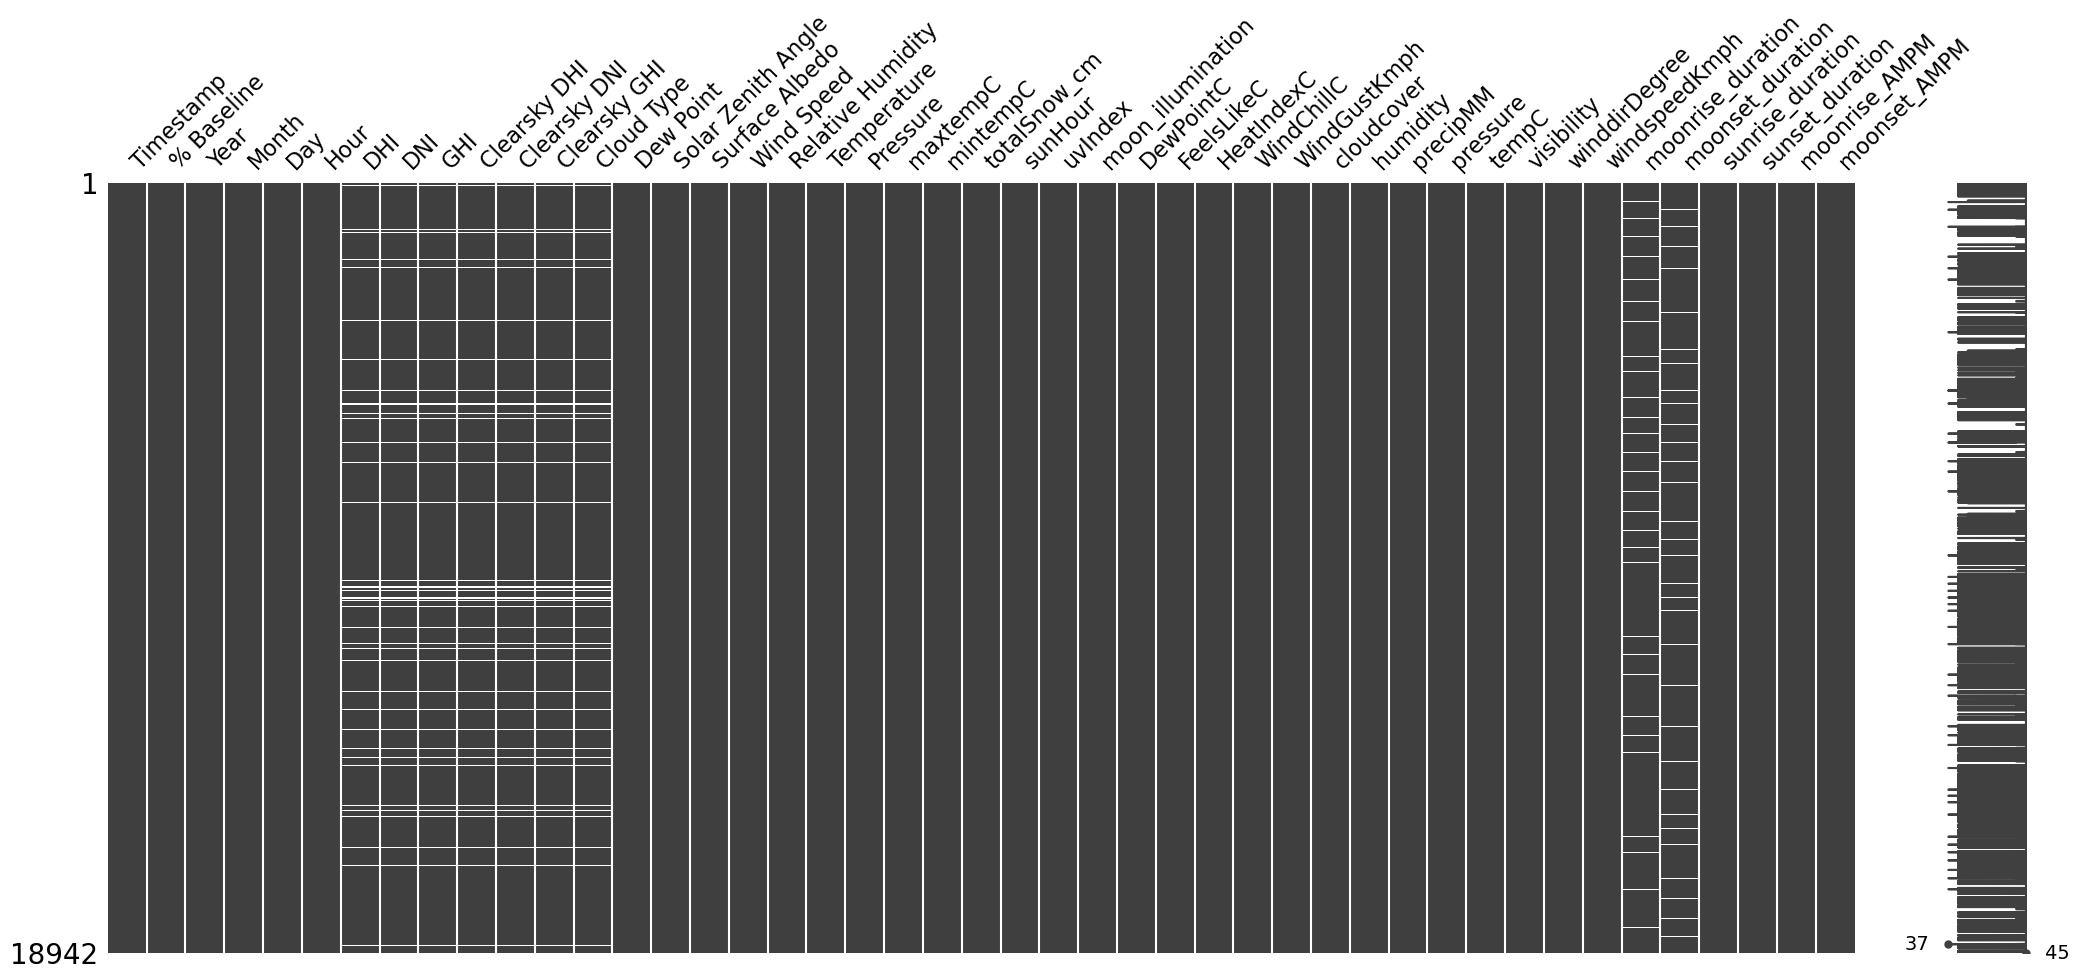

In [ ]:
mno.matrix(train_df)

In [ ]:
missing_values_table(test_df)

Your selected dataframe has 44 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
DHI,167,15.5
DNI,167,15.5
GHI,167,15.5
Clearsky DHI,167,15.5
Clearsky DNI,167,15.5
Clearsky GHI,167,15.5
Cloud Type,112,10.4
moonrise_duration,34,3.2
moonset_duration,33,3.1


<Axes: >

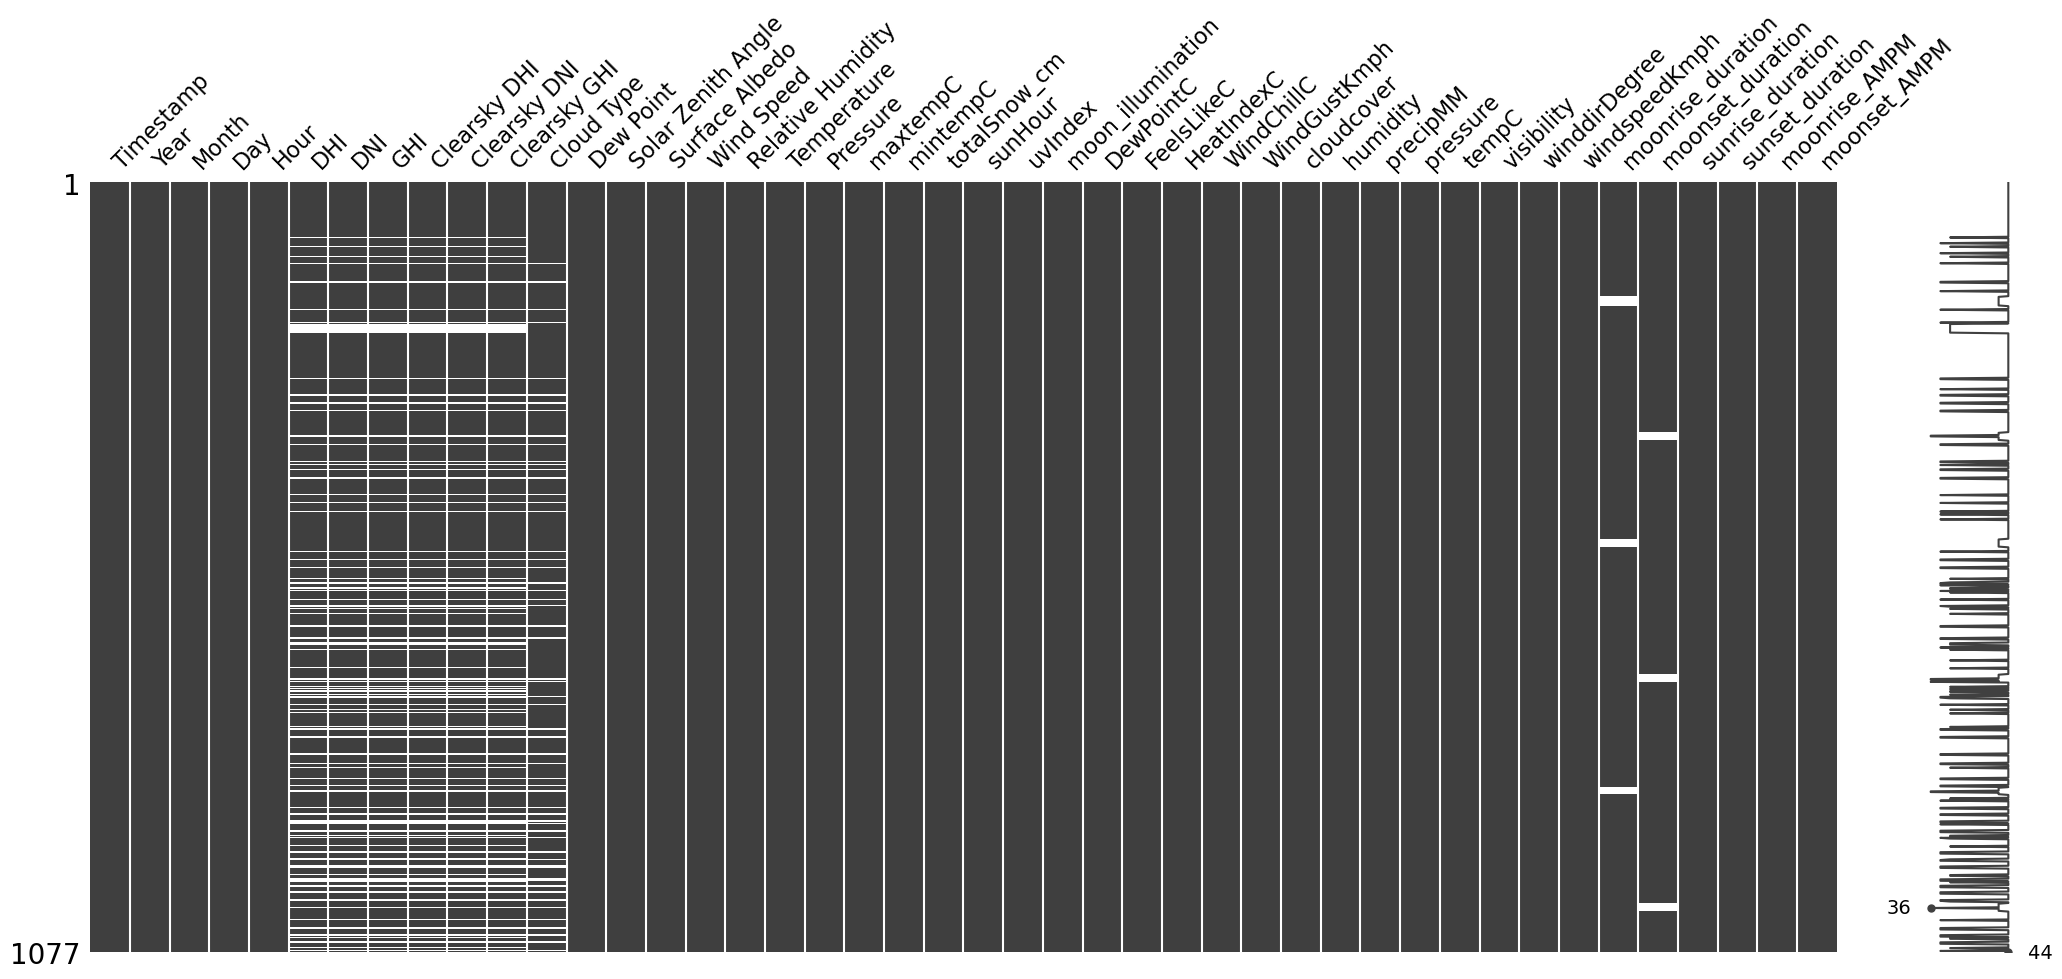

In [ ]:
mno.matrix(test_df)

## KDE & Boxplot

In [ ]:
# Pisah num dan object
train_cat = train_df.select_dtypes(include=['object']).columns.tolist()
train_num = train_df.select_dtypes(include = ['float64','int64']).columns.tolist()

In [ ]:
train_num

['% Baseline',
 'Year',
 'Month',
 'Day',
 'Hour',
 'DHI',
 'DNI',
 'GHI',
 'Clearsky DHI',
 'Clearsky DNI',
 'Clearsky GHI',
 'Dew Point',
 'Solar Zenith Angle',
 'Surface Albedo',
 'Wind Speed',
 'Relative Humidity',
 'Temperature',
 'Pressure',
 'maxtempC',
 'mintempC',
 'totalSnow_cm',
 'sunHour',
 'uvIndex',
 'moon_illumination',
 'DewPointC',
 'FeelsLikeC',
 'HeatIndexC',
 'WindChillC',
 'WindGustKmph',
 'cloudcover',
 'humidity',
 'precipMM',
 'pressure',
 'tempC',
 'visibility',
 'winddirDegree',
 'windspeedKmph',
 'moonrise_duration',
 'moonset_duration',
 'sunrise_duration',
 'sunset_duration']

In [ ]:
train_num[40]

'sunset_duration'

C:\Users\Mahendra\AppData\Local\Temp\ipykernel_19900\327359728.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df[train_num[i]], ax=ax[1], color = 'skyblue')
C:\Users\Mahendra\AppData\Local\Temp\ipykernel_19900\327359728.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df[trai

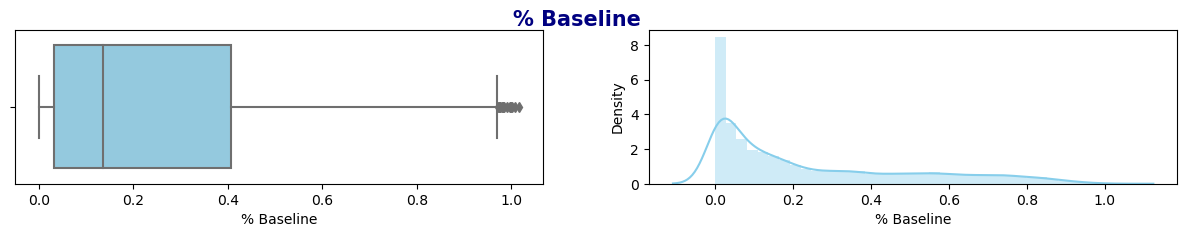

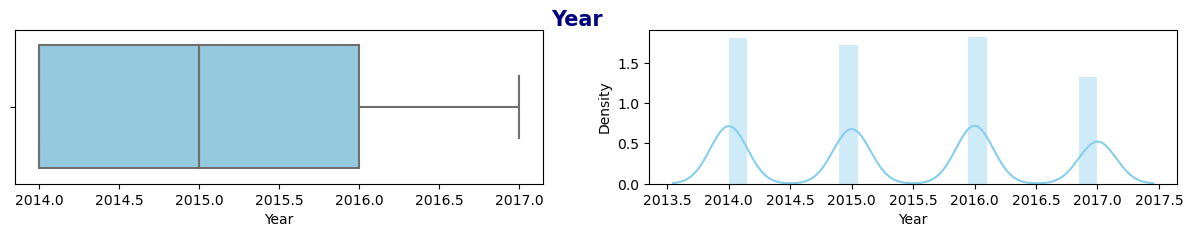

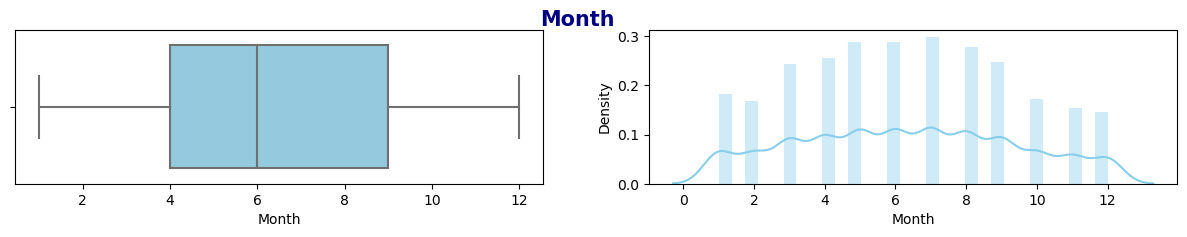

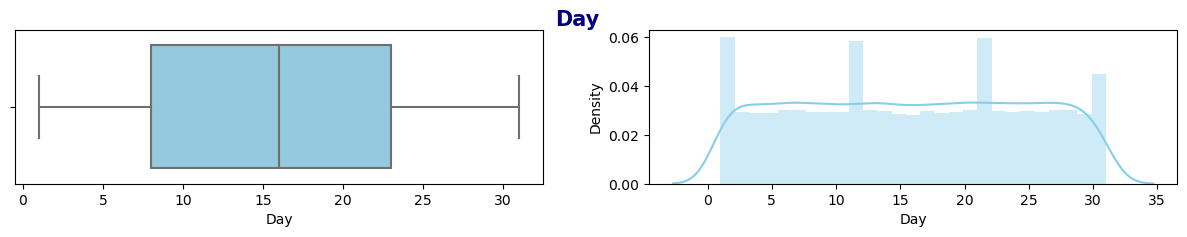

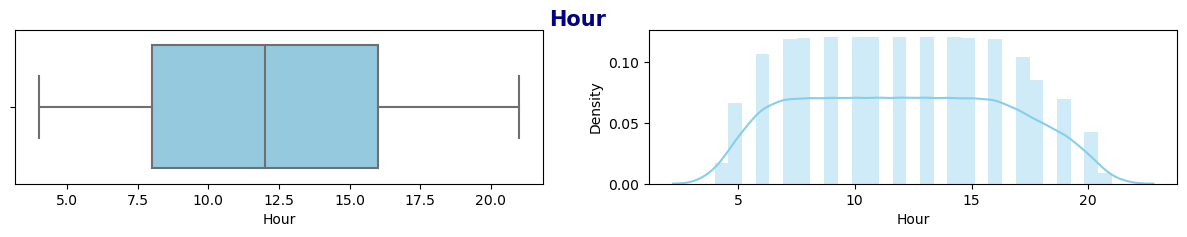

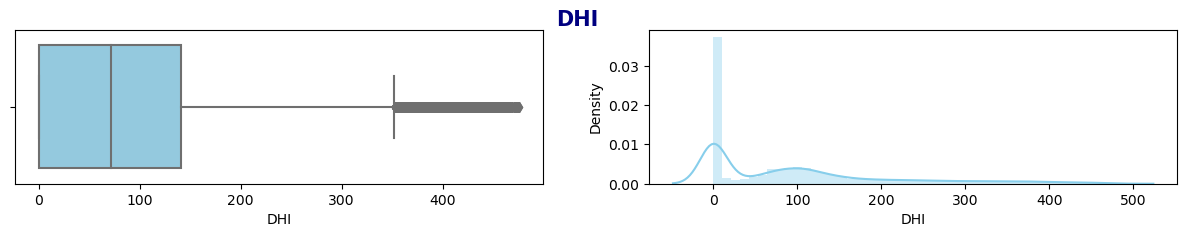

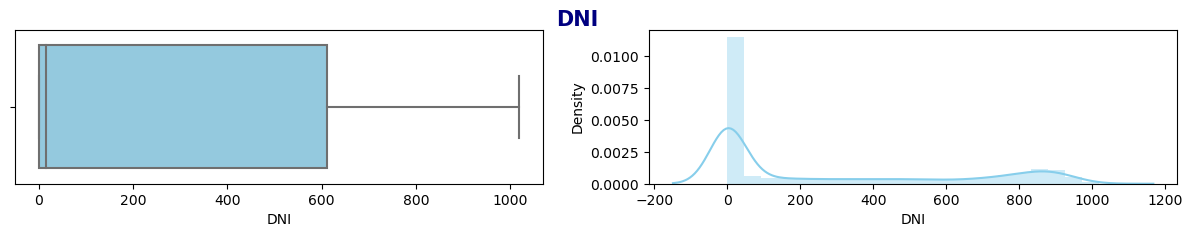

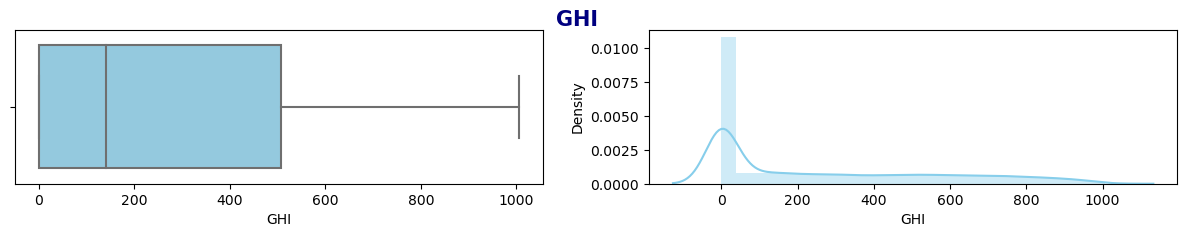

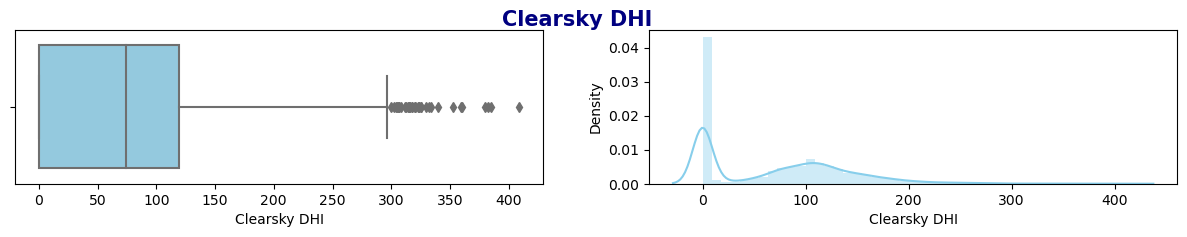

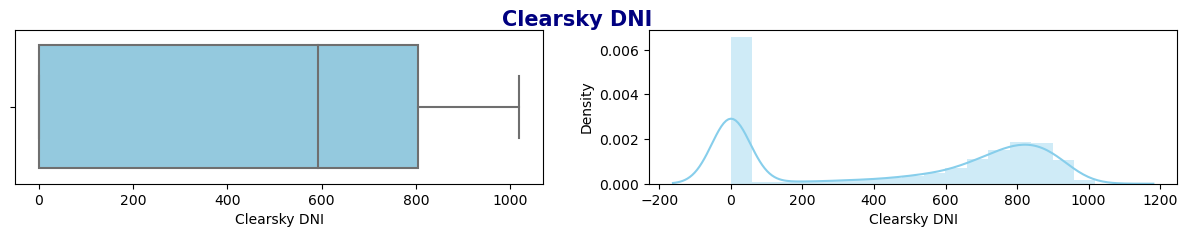

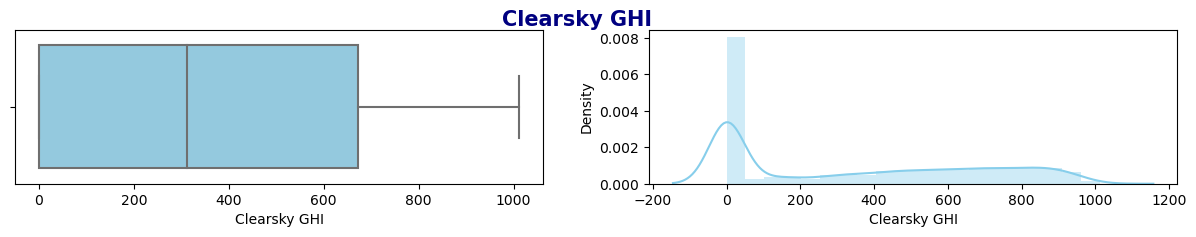

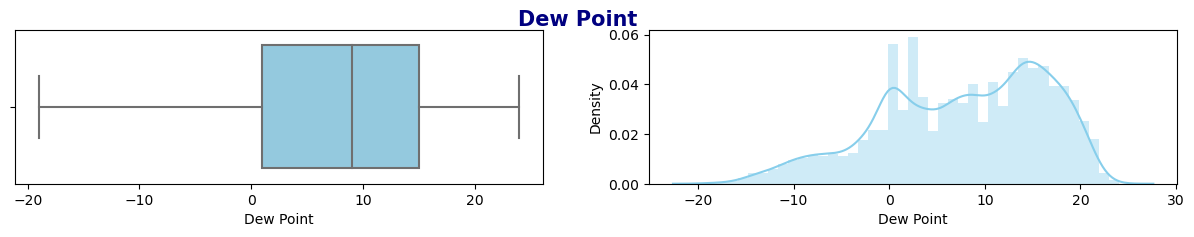

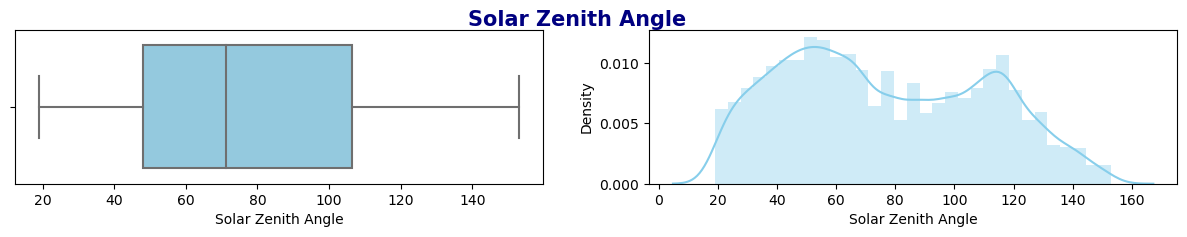

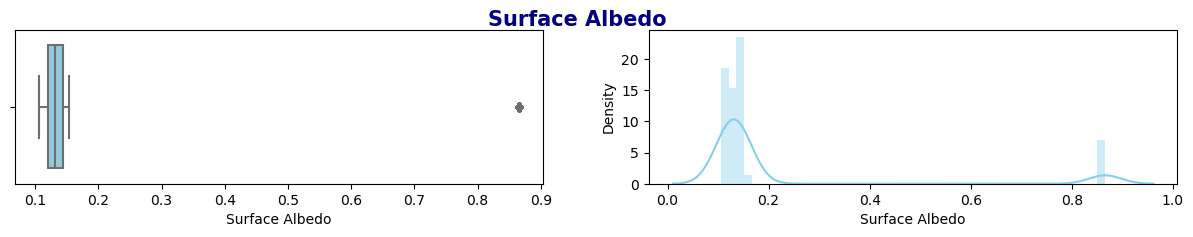

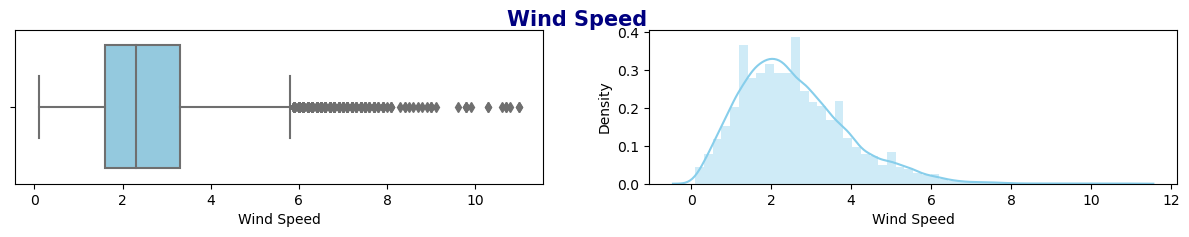

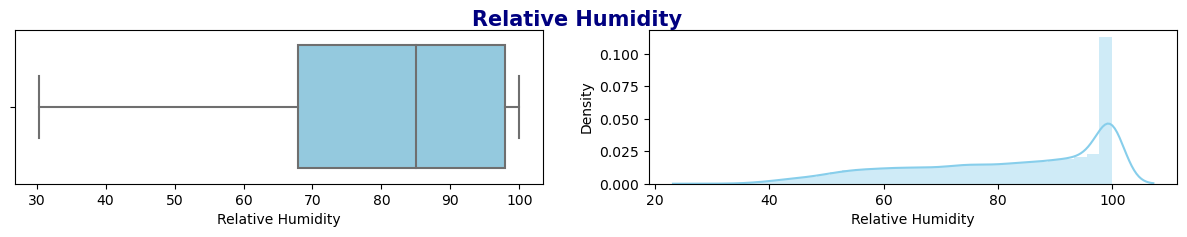

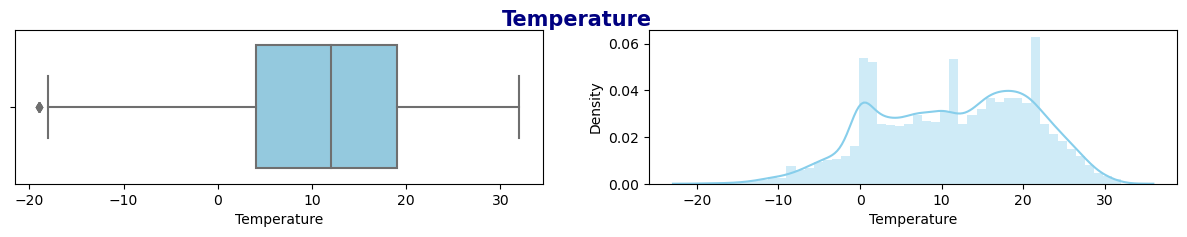

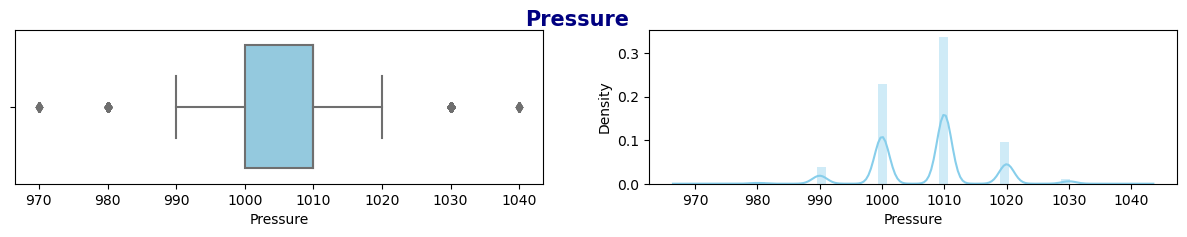

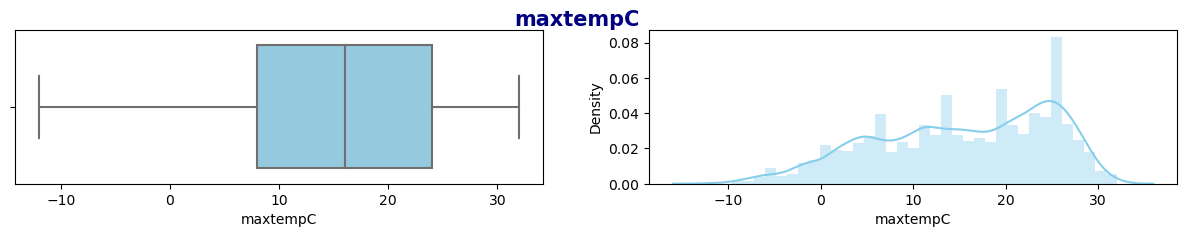

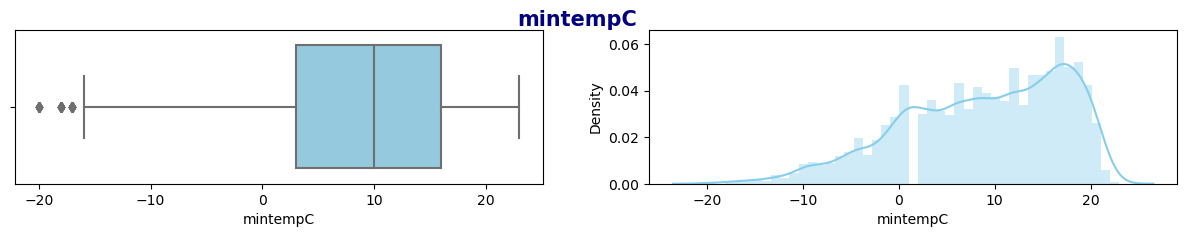

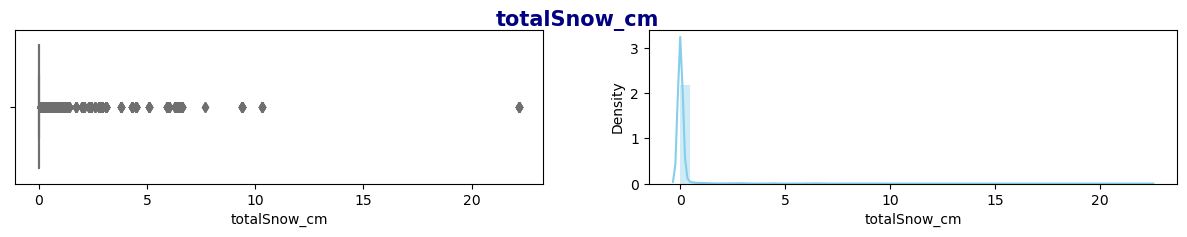

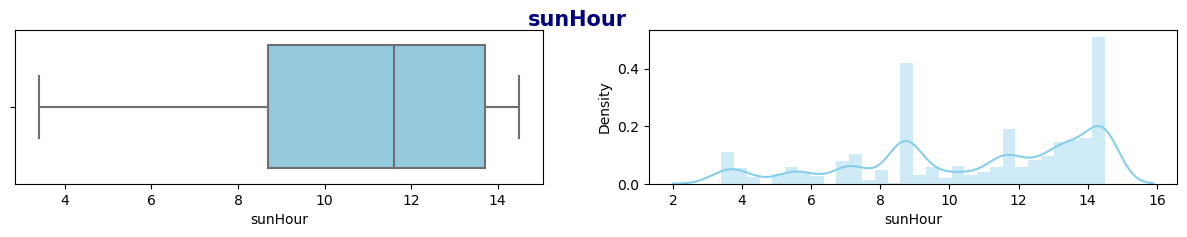

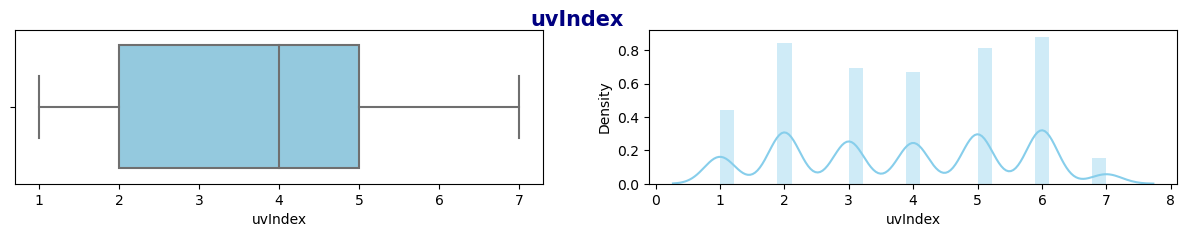

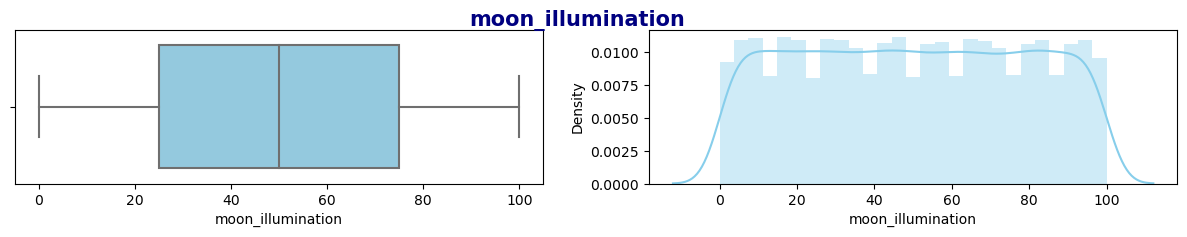

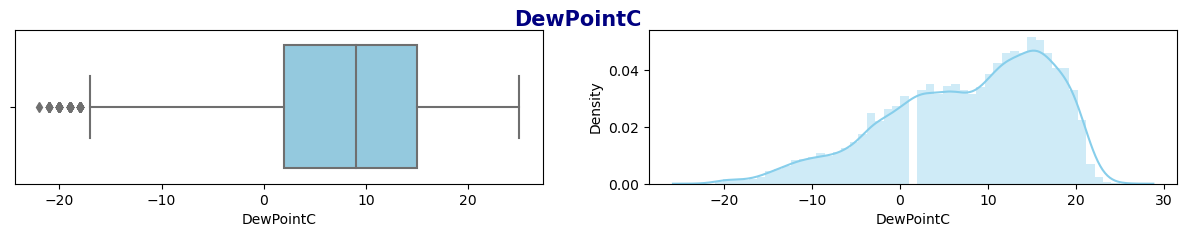

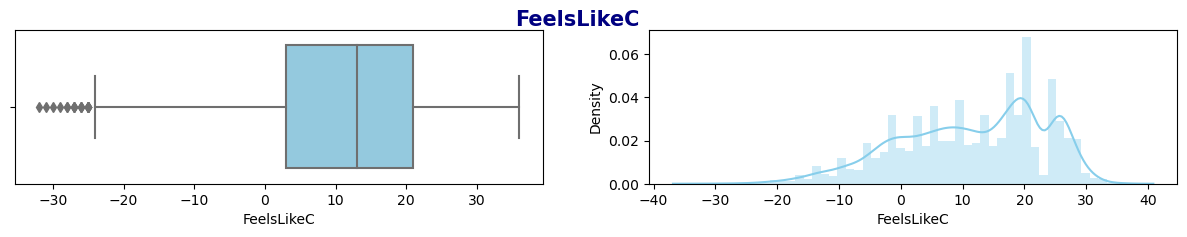

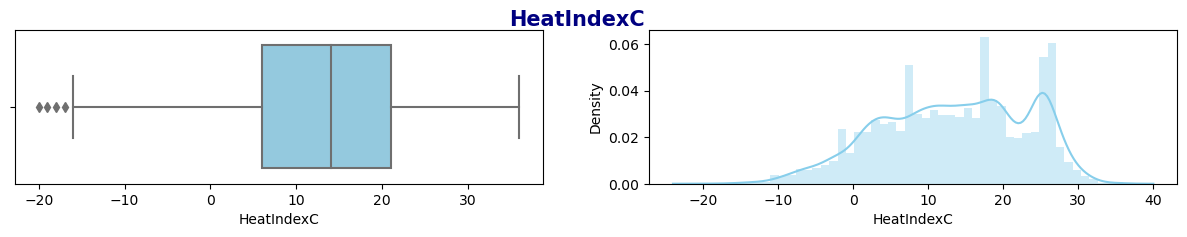

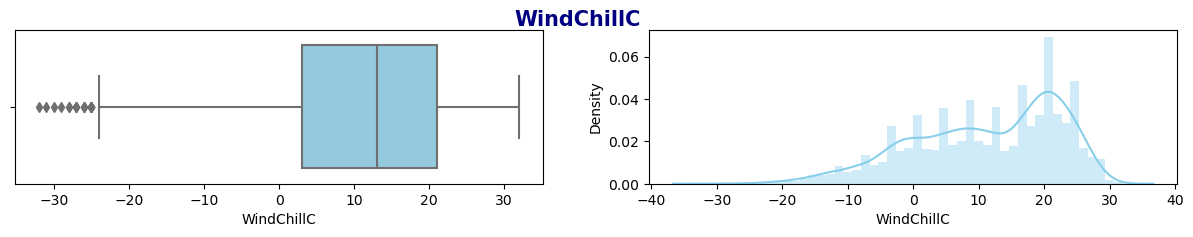

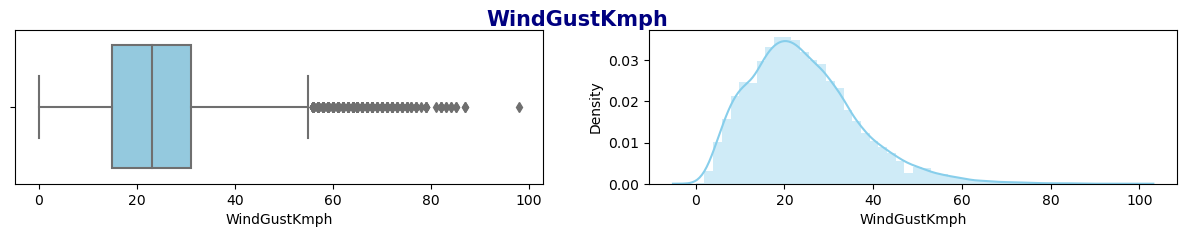

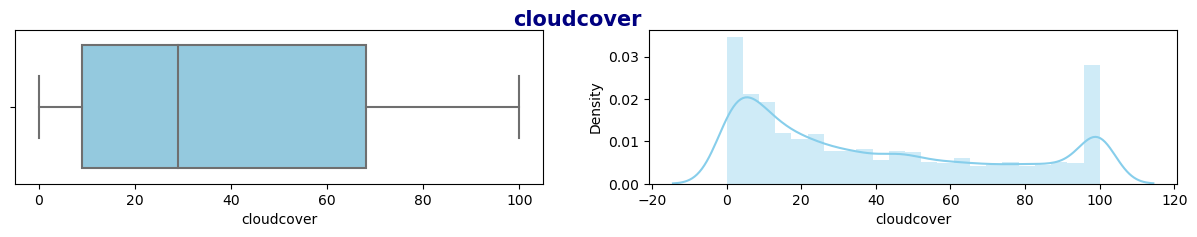

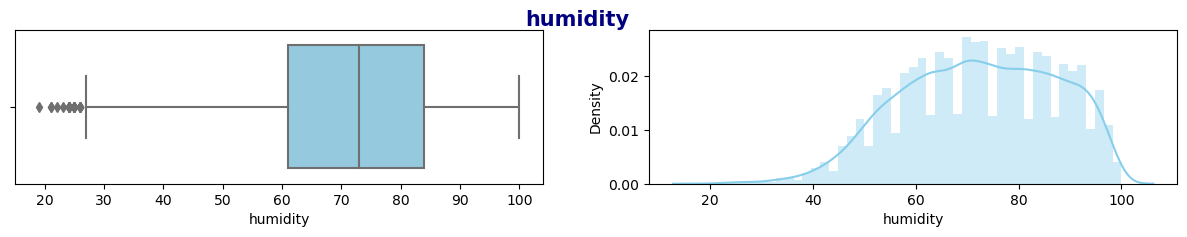

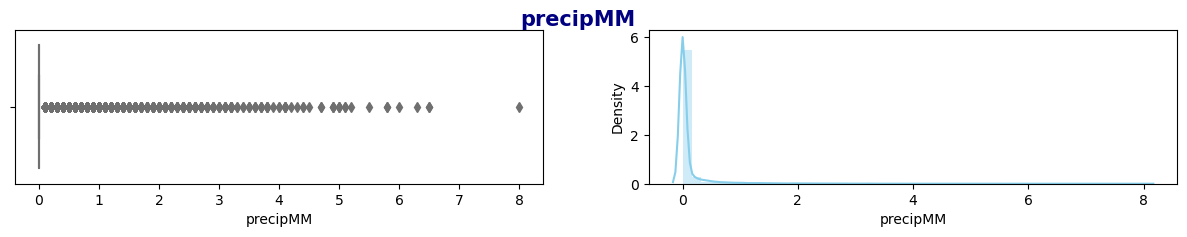

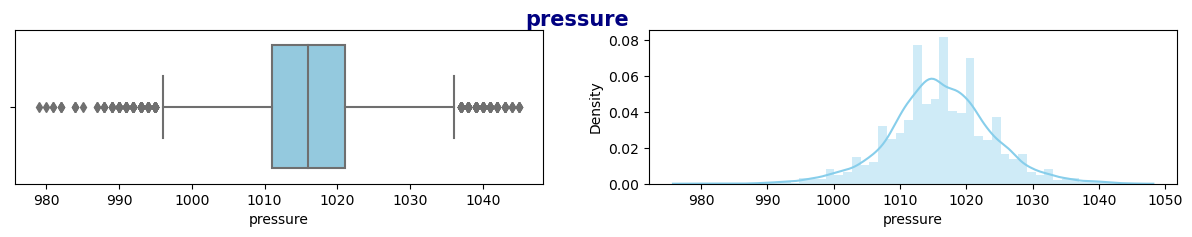

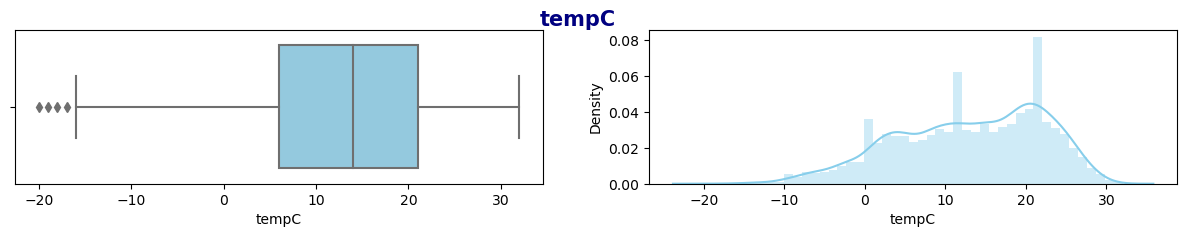

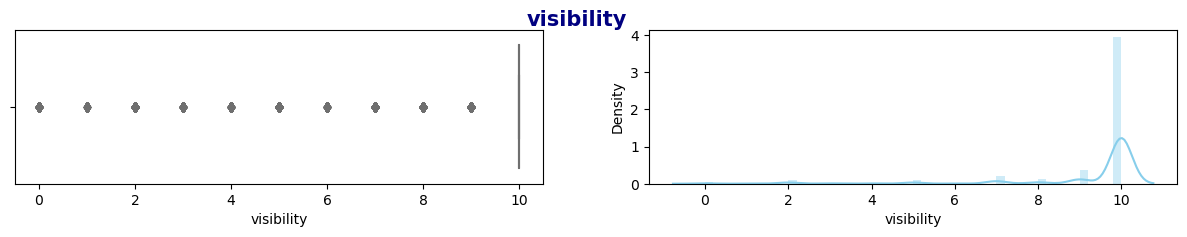

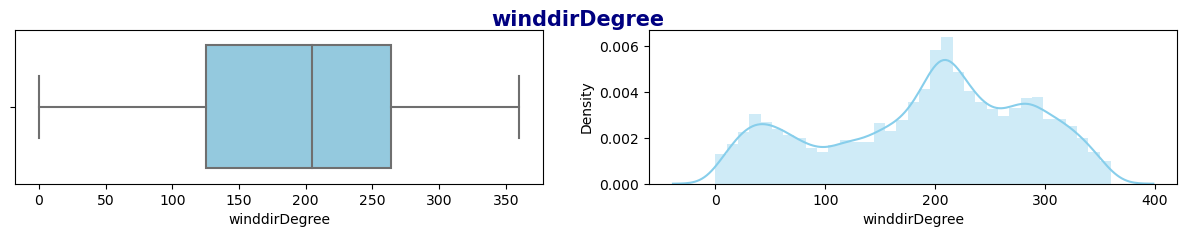

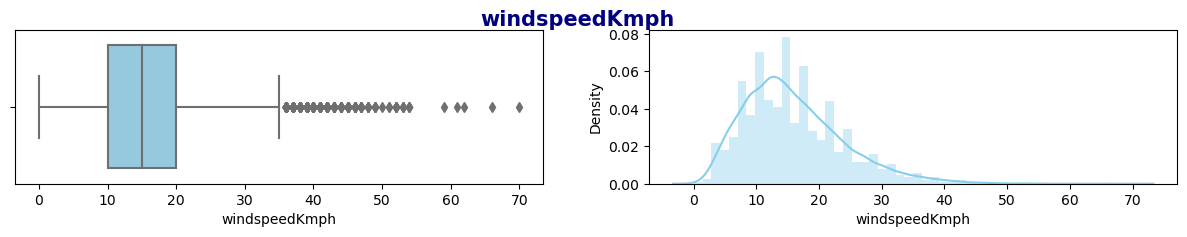

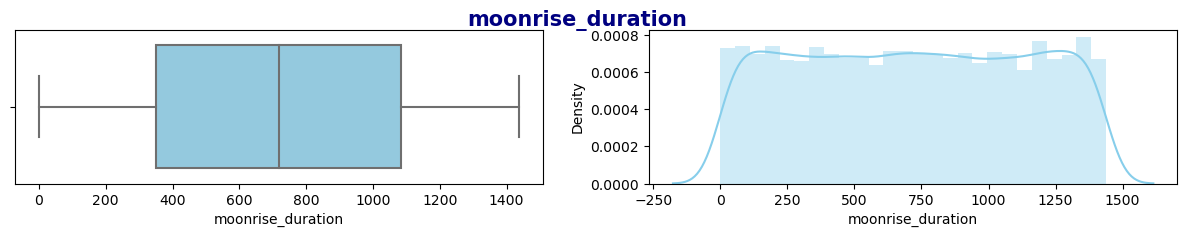

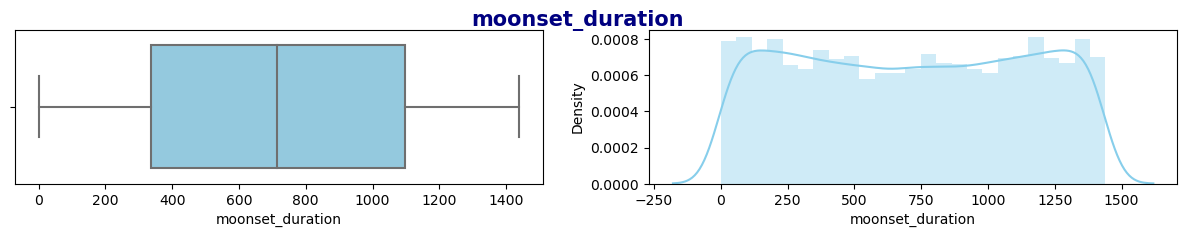

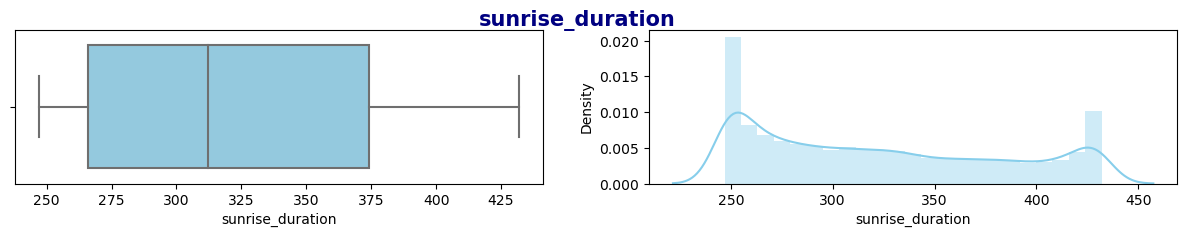

In [ ]:
for i in range(0, 40) :
    fig, ax = plt.subplots(1, 2, figsize=(15, 2))
    plt.suptitle(train_num[i], fontsize=15, fontweight='bold', color='navy')
    # Left Plot
    sns.boxplot(x=train_num[i], data=train_df, ax=ax[0], color = 'skyblue')
    # Right Plot
    sns.distplot(train_df[train_num[i]], ax=ax[1], color = 'skyblue')

## Heatmap Correlation

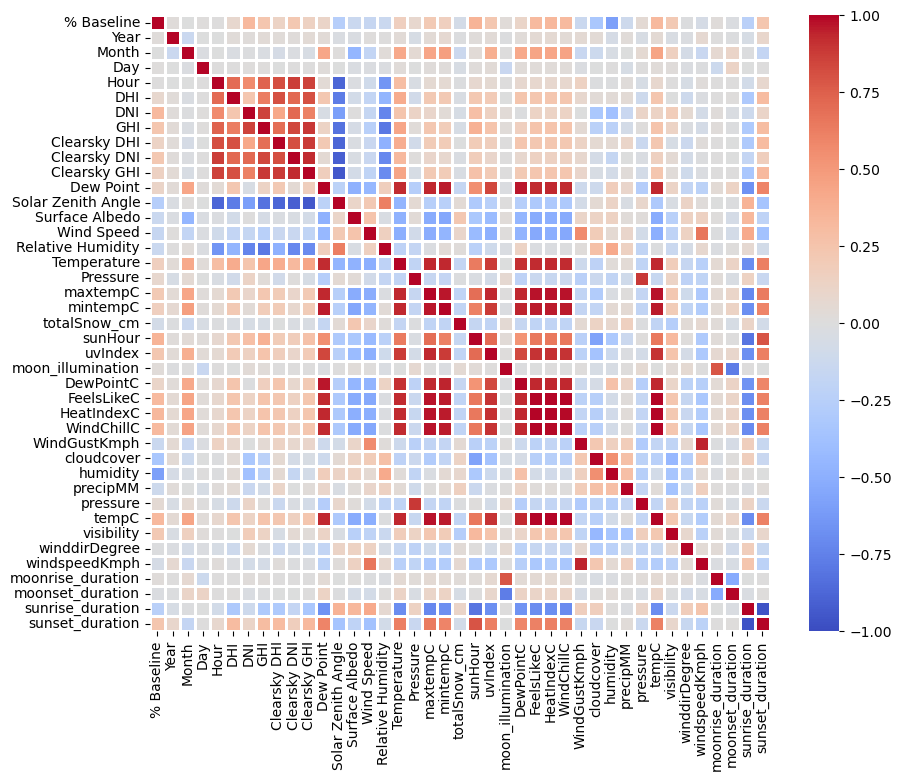

Korelasi positif tertinggi: 1.00 antara FeelsLikeC dan WindChillC
Korelasi negatif terendah: -0.97 antara sunrise_duration dan sunset_duration


In [ ]:
# Menghitung matriks korelasi
cor = train_df[train_num].corr()

# Mengatur ukuran figure untuk heatmap
plt.figure(figsize=(10, 8))

# Membuat heatmap dengan hanya warna, tanpa angka
sns.heatmap(cor, cmap='coolwarm', annot=False, linecolor='white', linewidths=1, vmin=-1, vmax=1)

# Menampilkan heatmap
plt.show()

# Mengambil matriks korelasi tanpa diagonal utama (nilai 1)
cor_without_diag = cor.where(np.triu(np.ones(cor.shape), k=1).astype(bool))

# Menemukan korelasi positif tertinggi
max_corr = cor_without_diag.max().max()
max_corr_pair = cor_without_diag.stack().idxmax()

# Menemukan korelasi negatif terendah
min_corr = cor_without_diag.min().min()
min_corr_pair = cor_without_diag.stack().idxmin()

# Menampilkan hasil
print(f"Korelasi positif tertinggi: {max_corr:.2f} antara {max_corr_pair[0]} dan {max_corr_pair[1]}")
print(f"Korelasi negatif terendah: {min_corr:.2f} antara {min_corr_pair[0]} dan {min_corr_pair[1]}")

## Time Series Plot

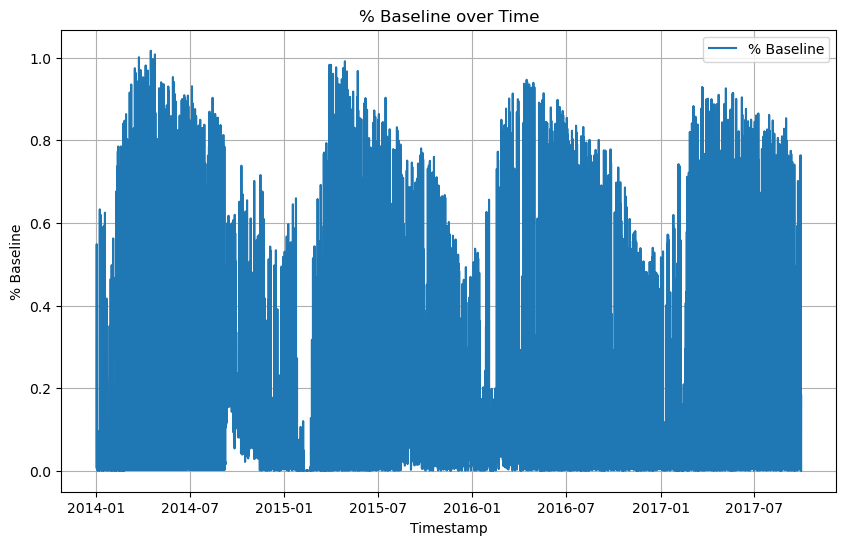

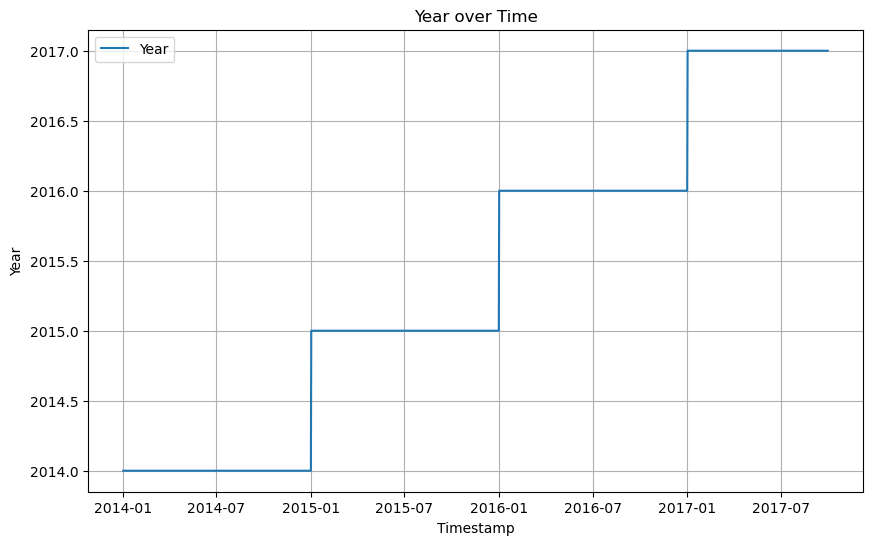

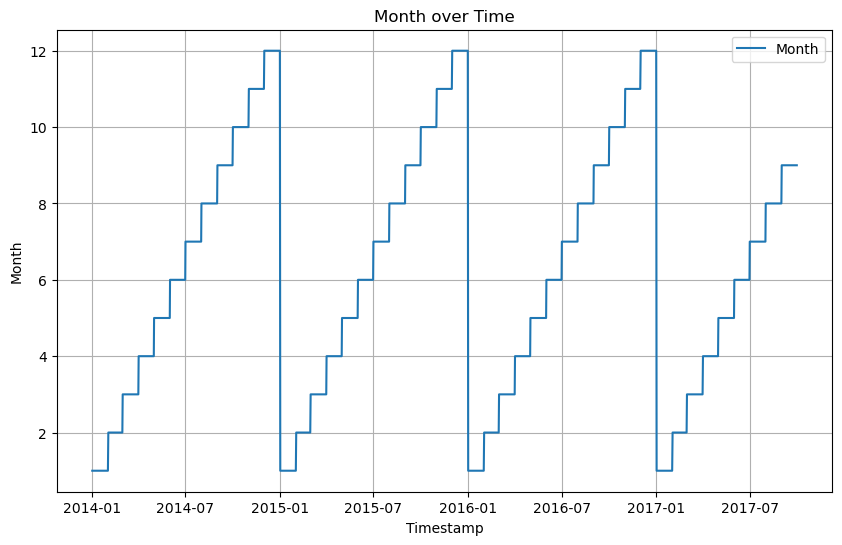

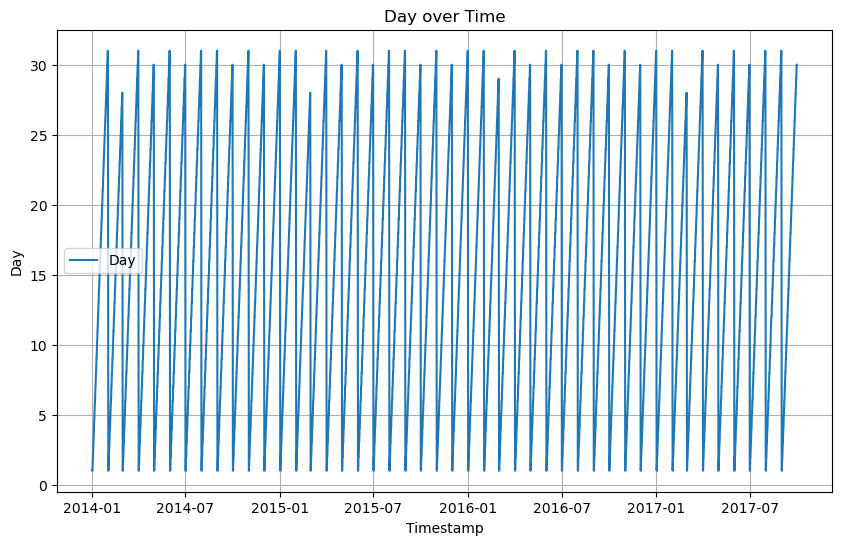

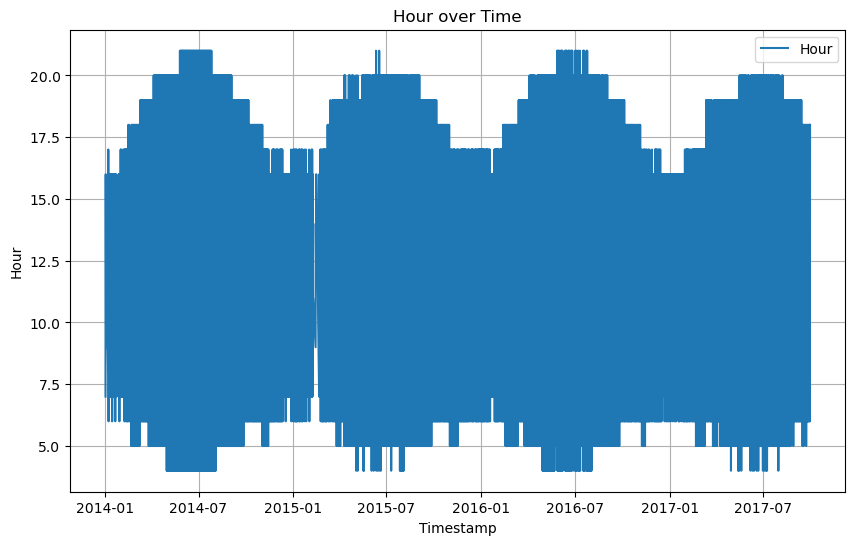

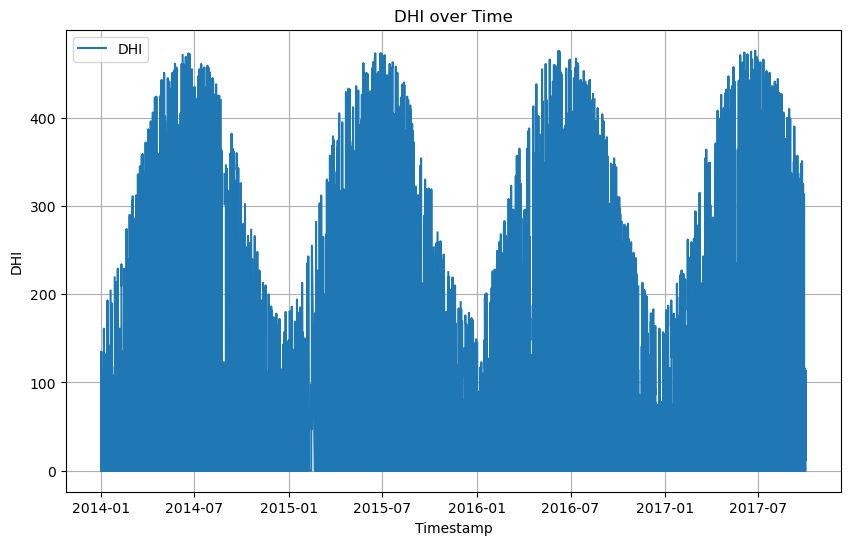

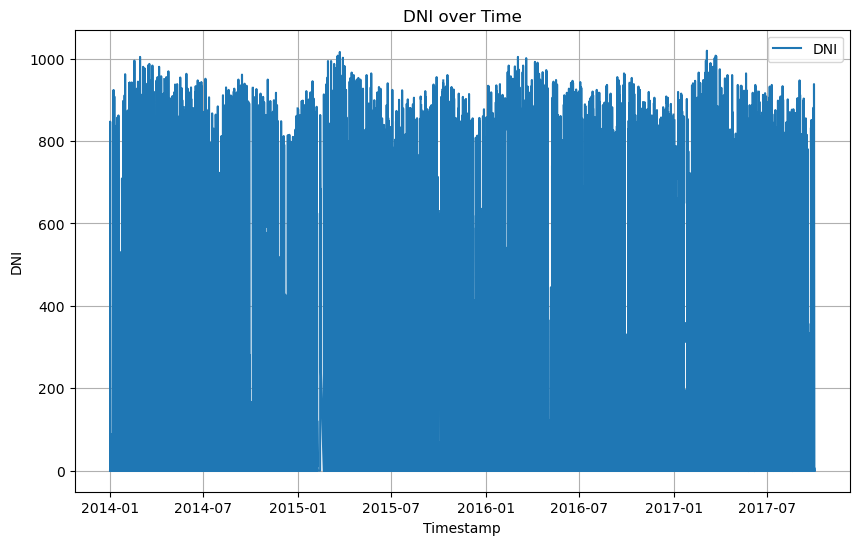

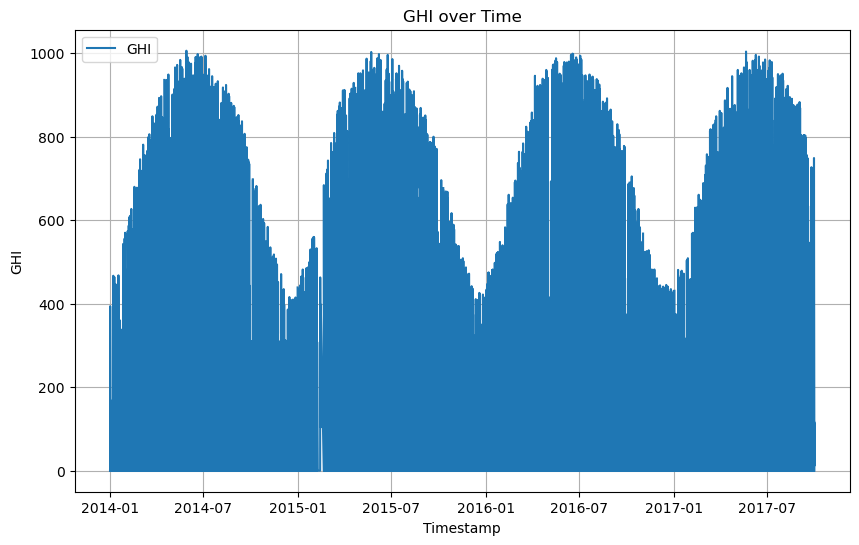

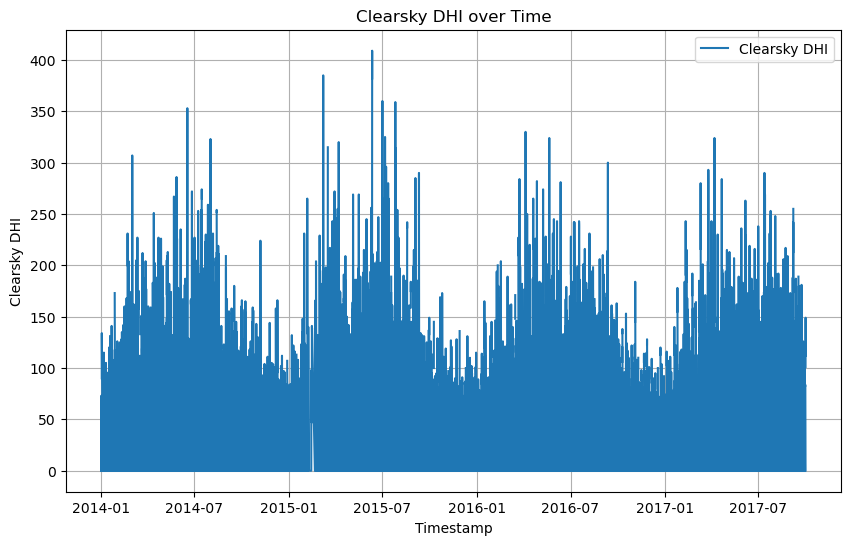

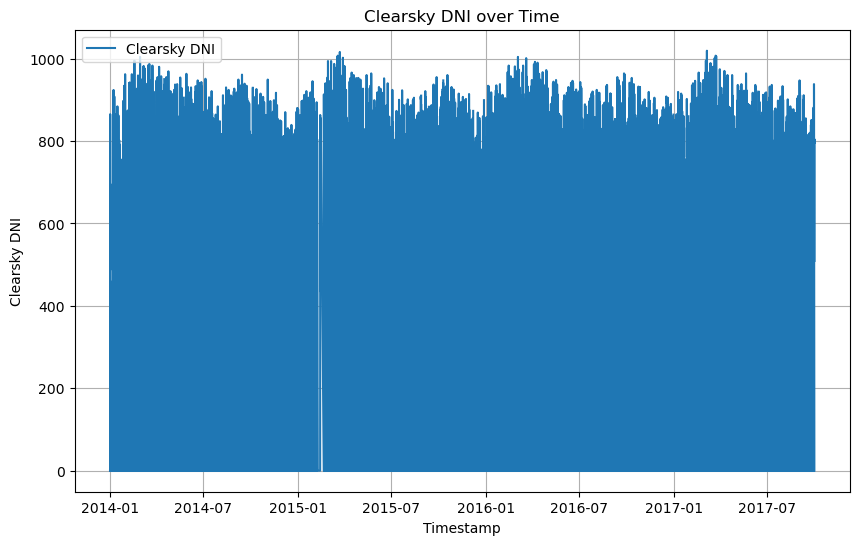

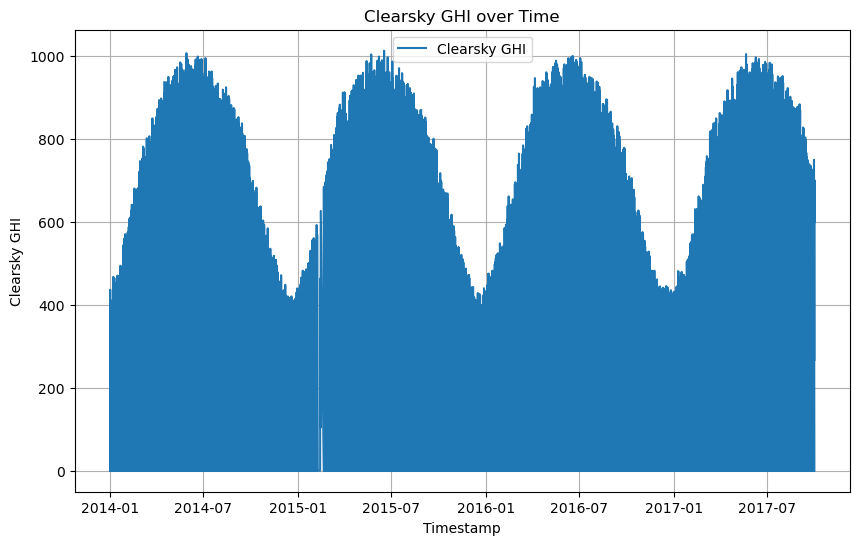

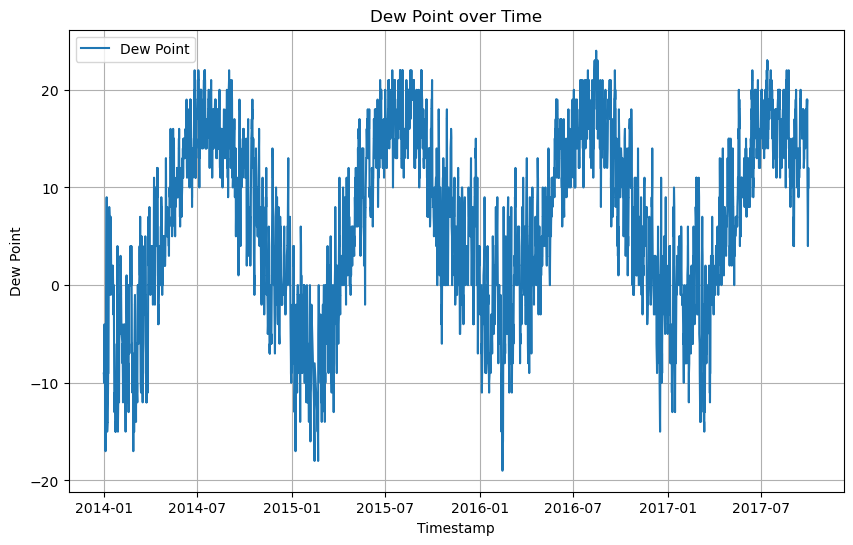

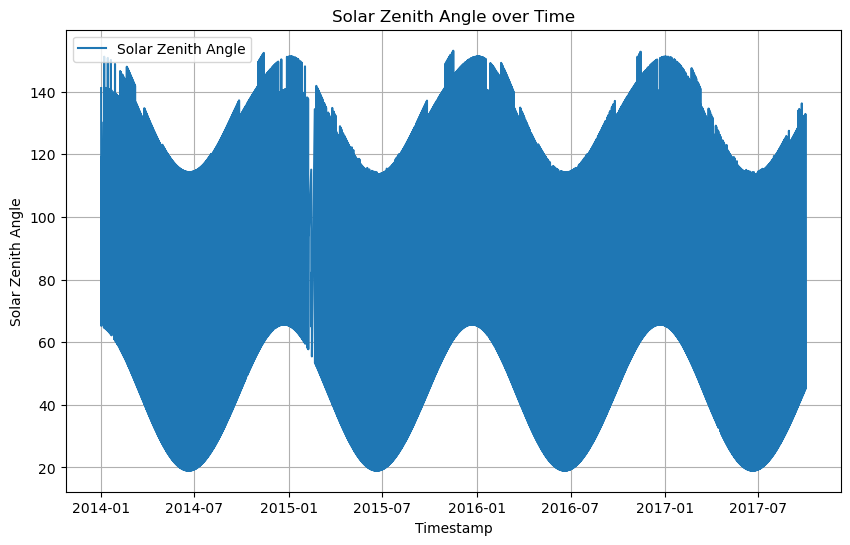

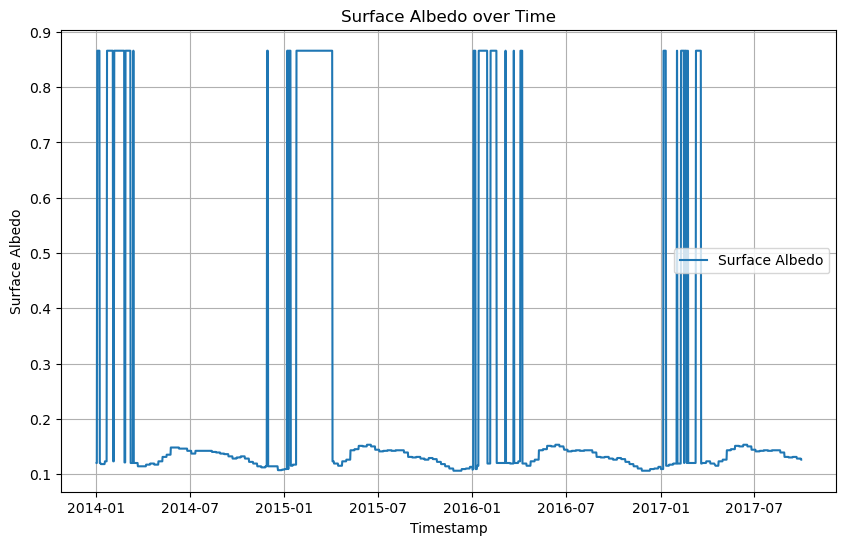

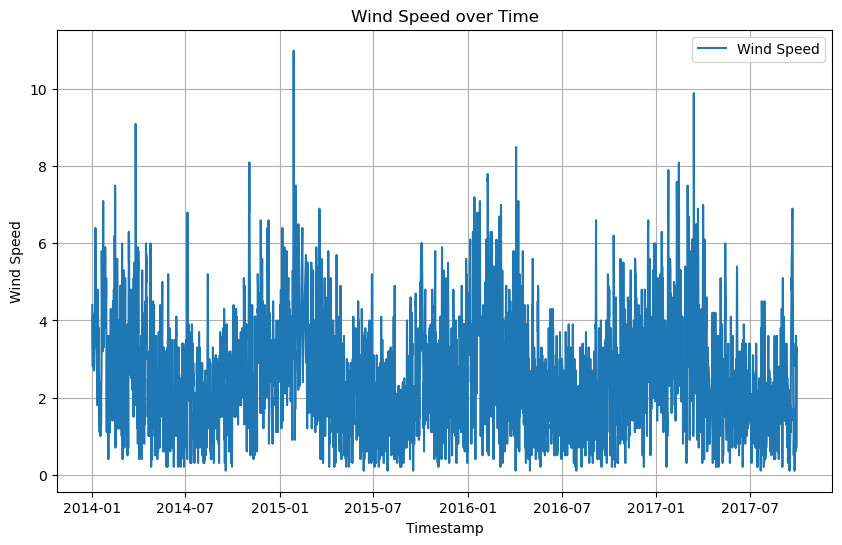

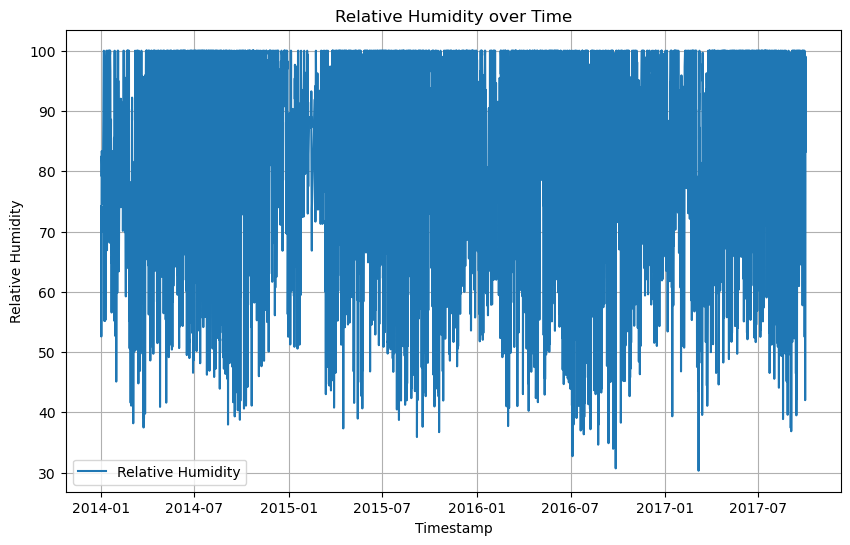

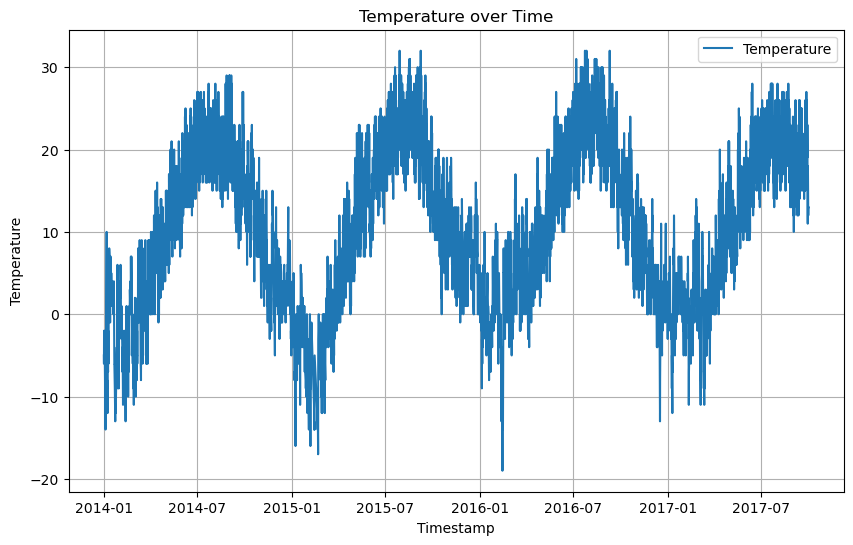

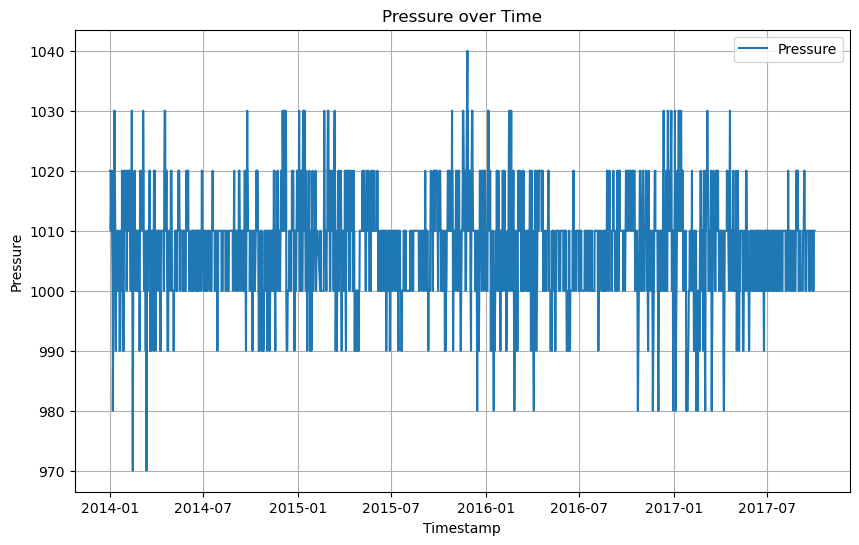

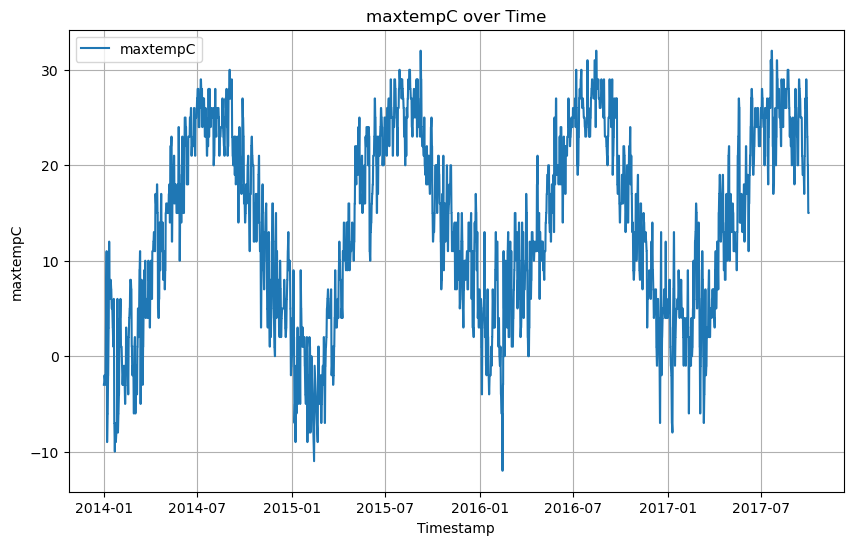

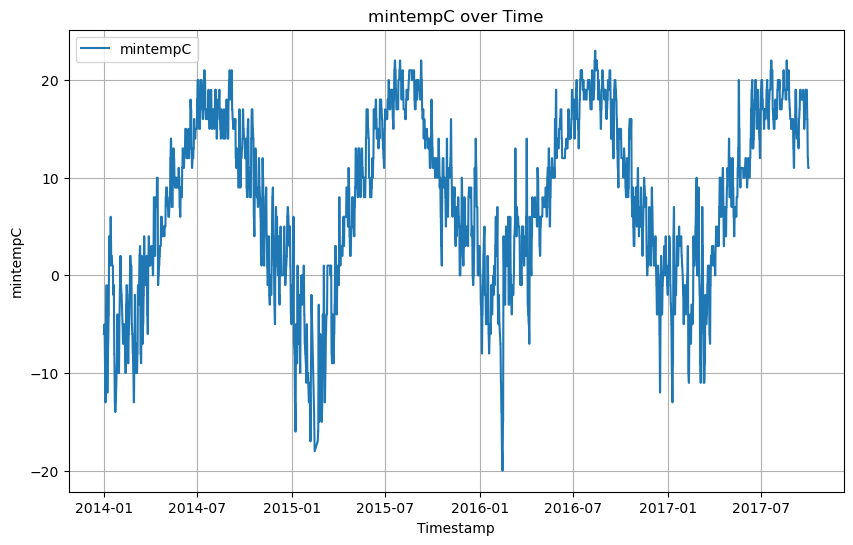

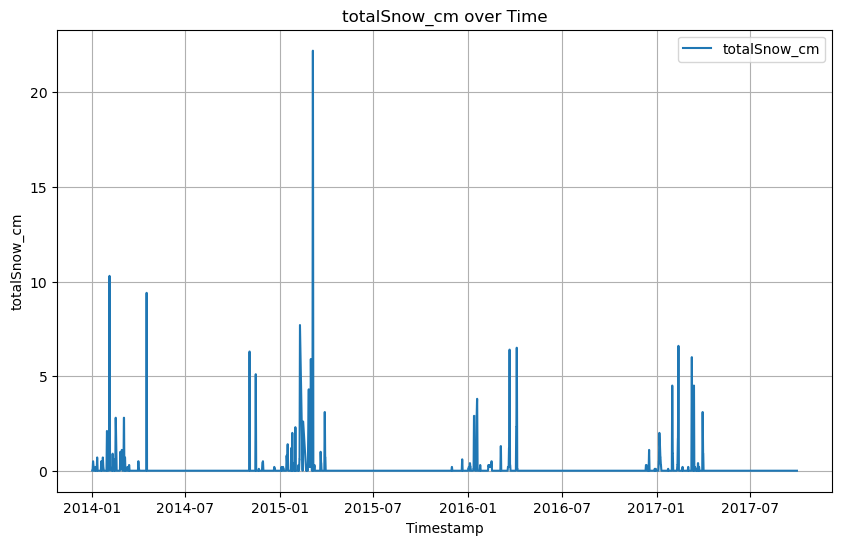

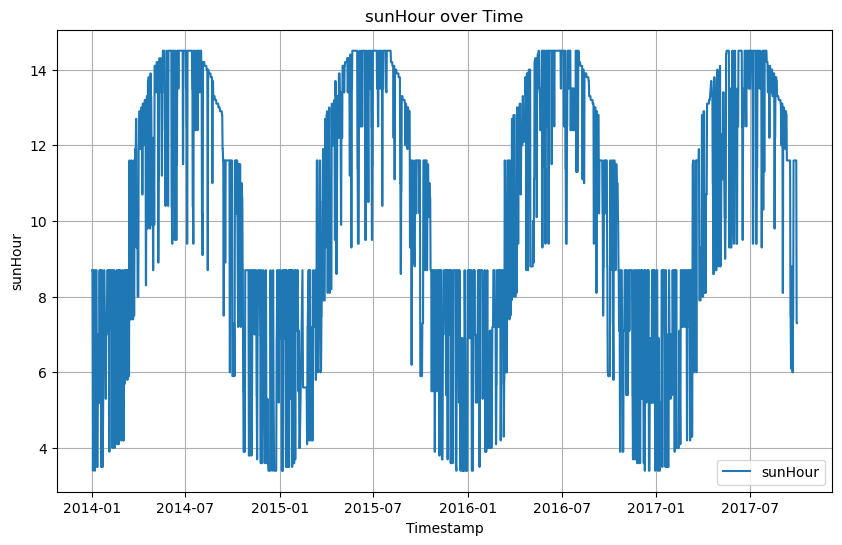

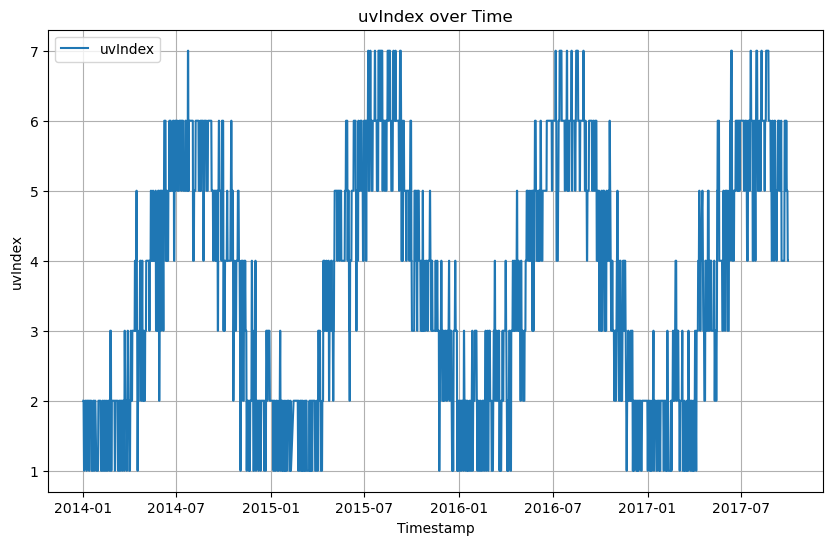

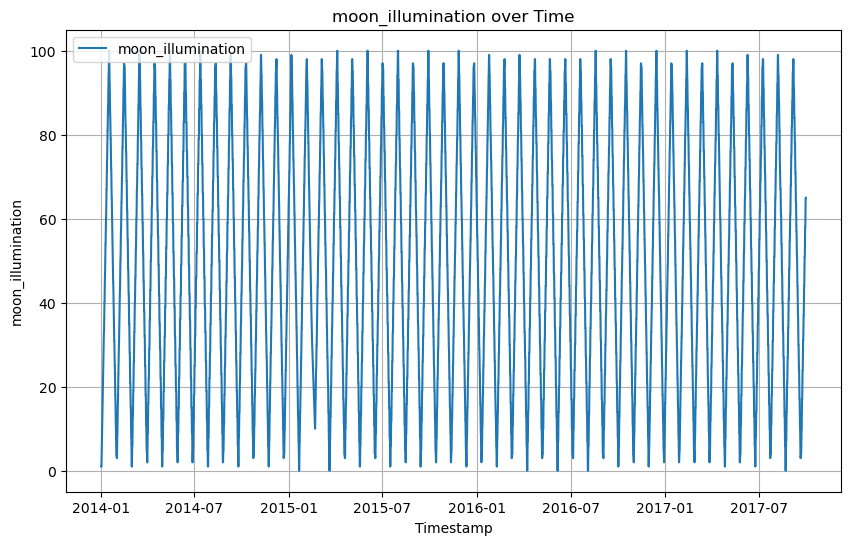

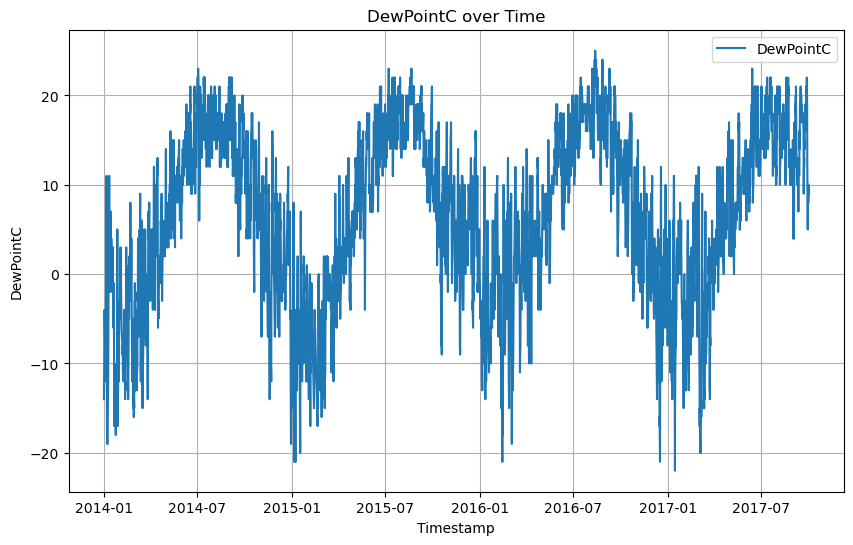

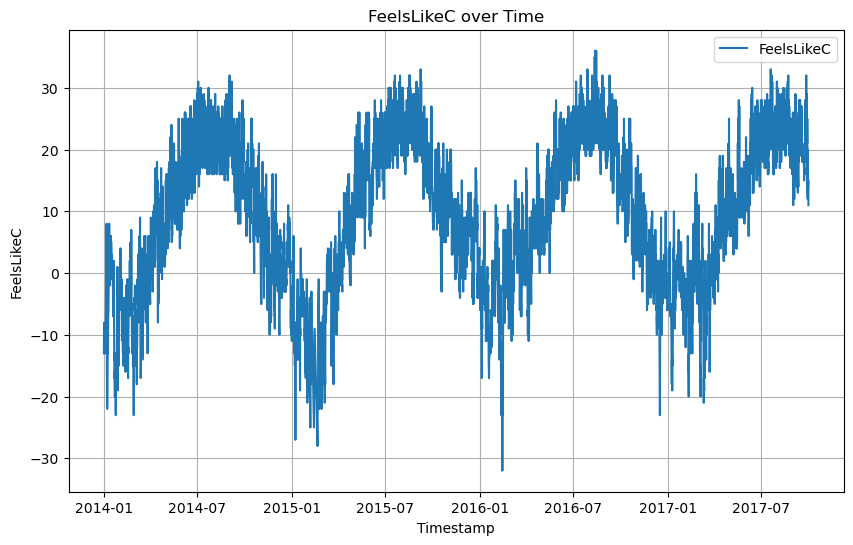

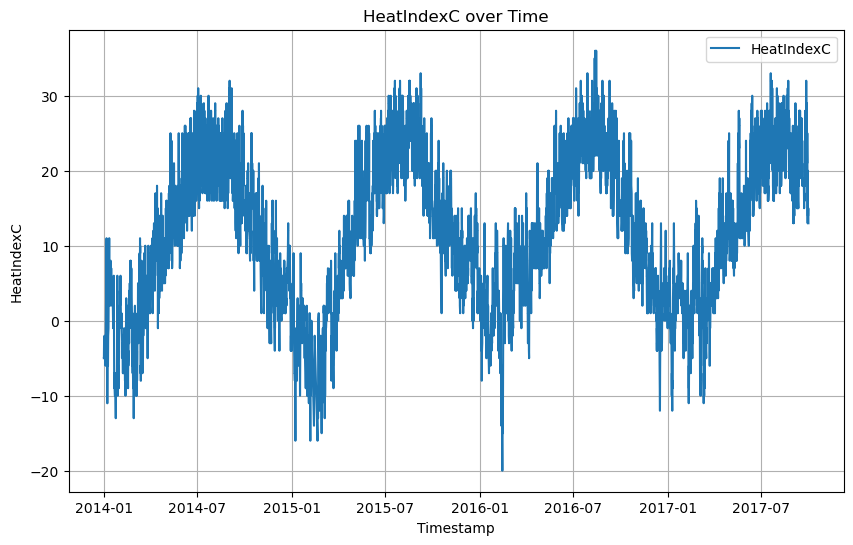

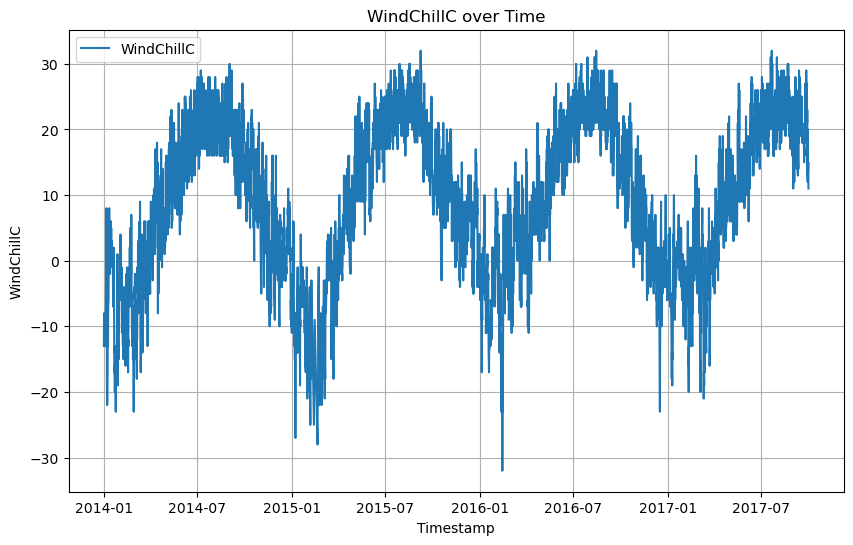

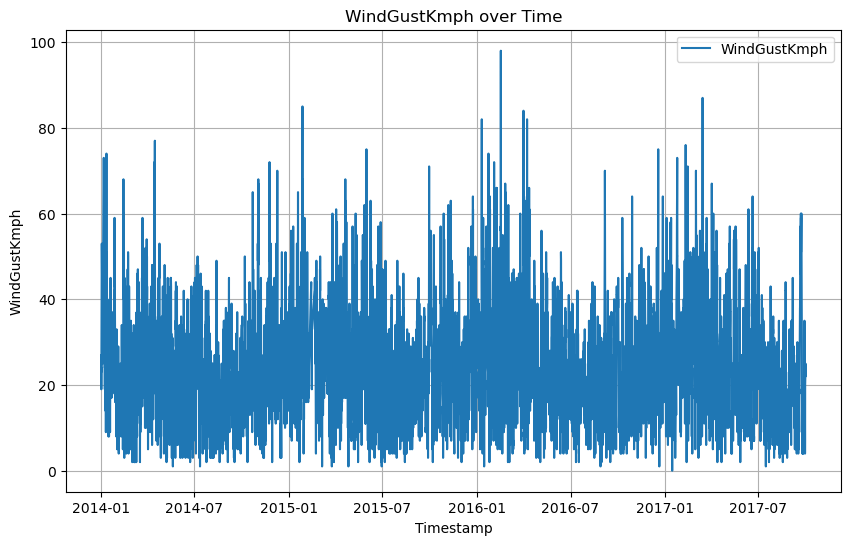

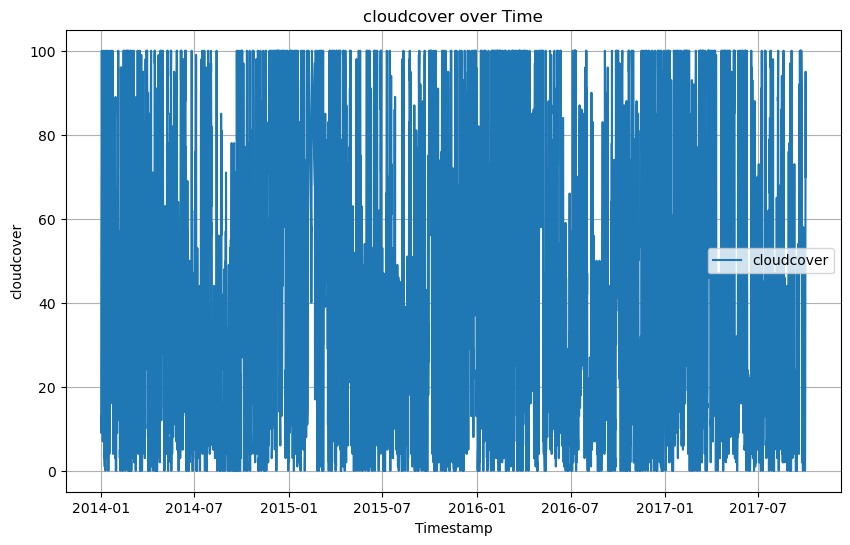

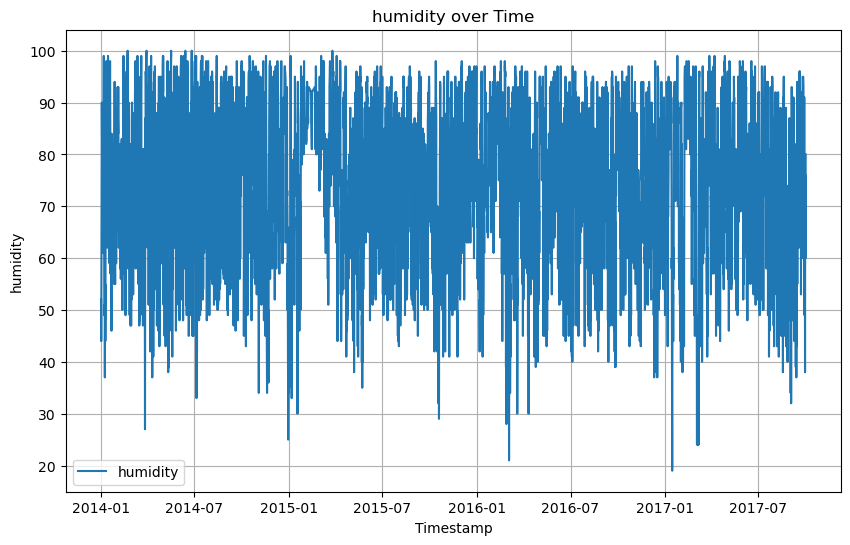

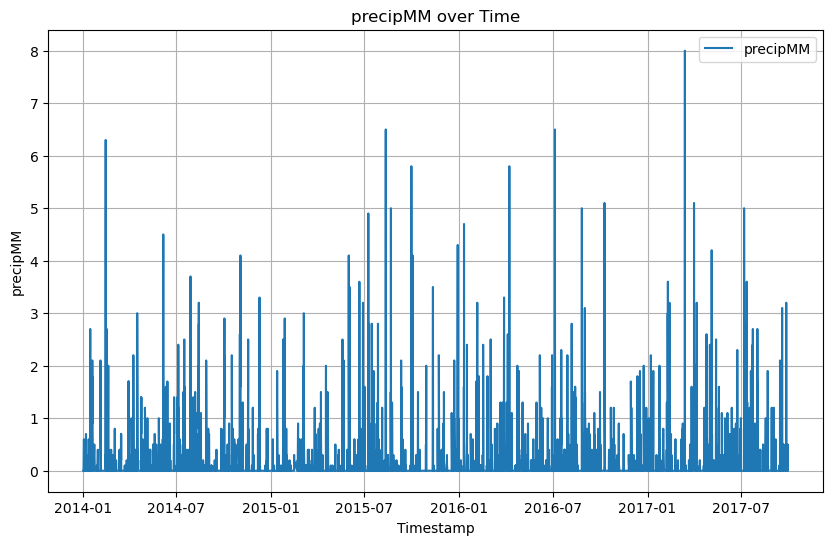

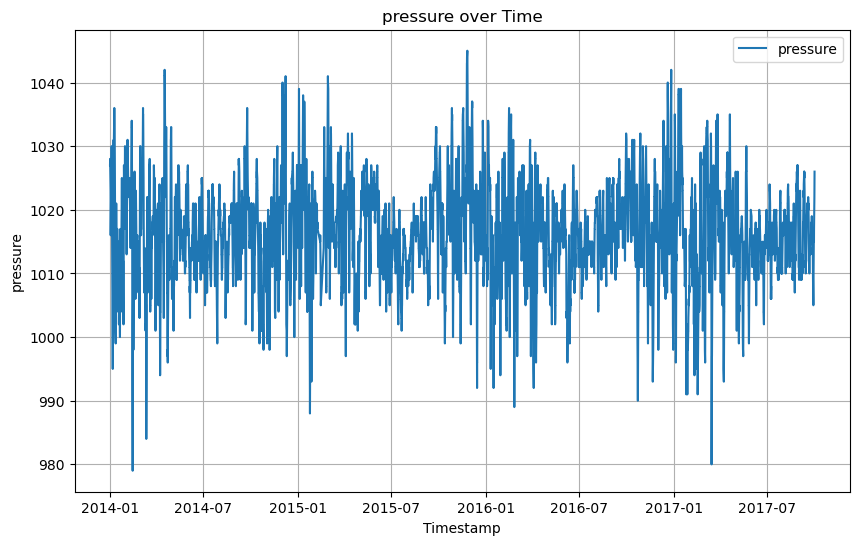

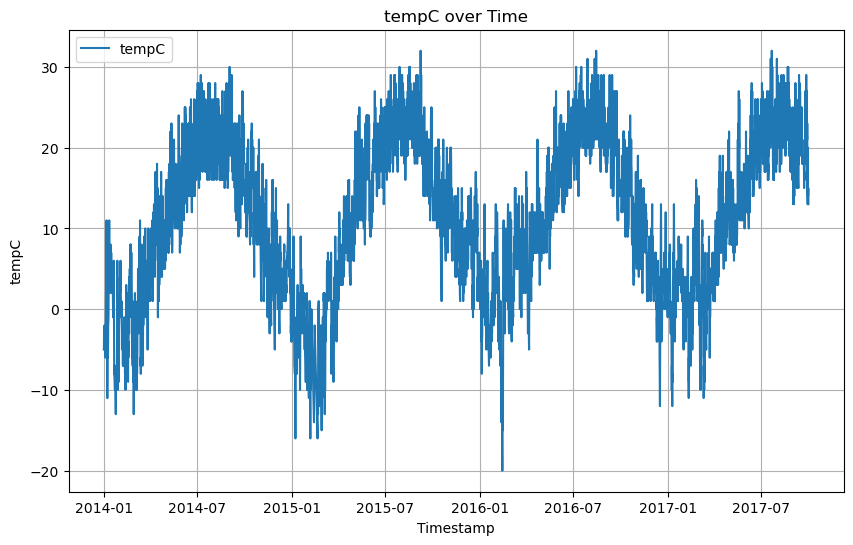

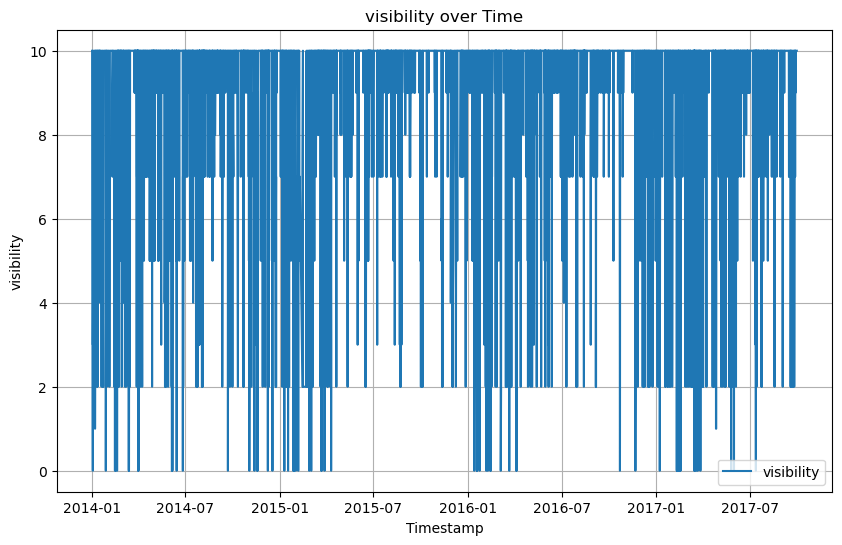

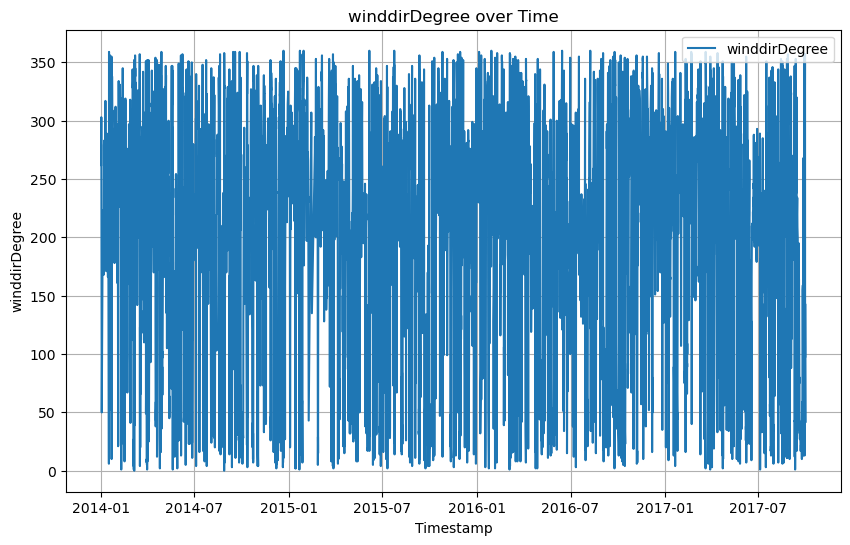

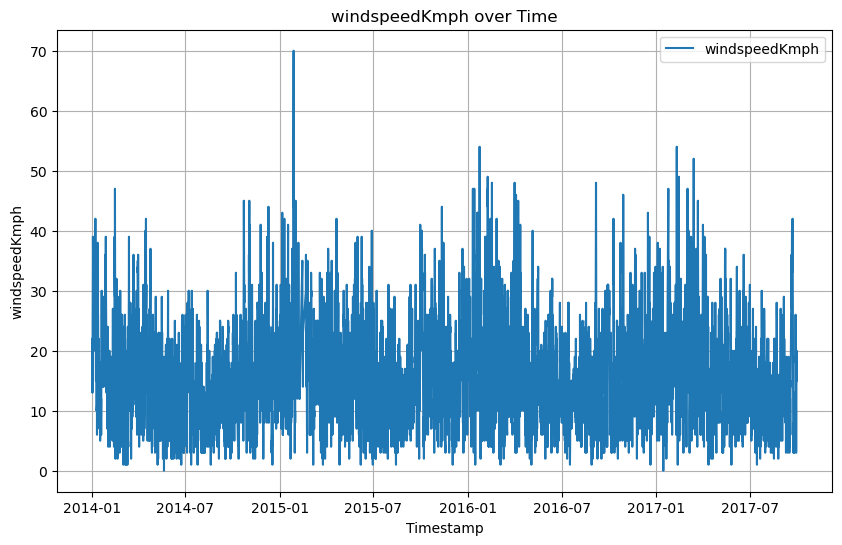

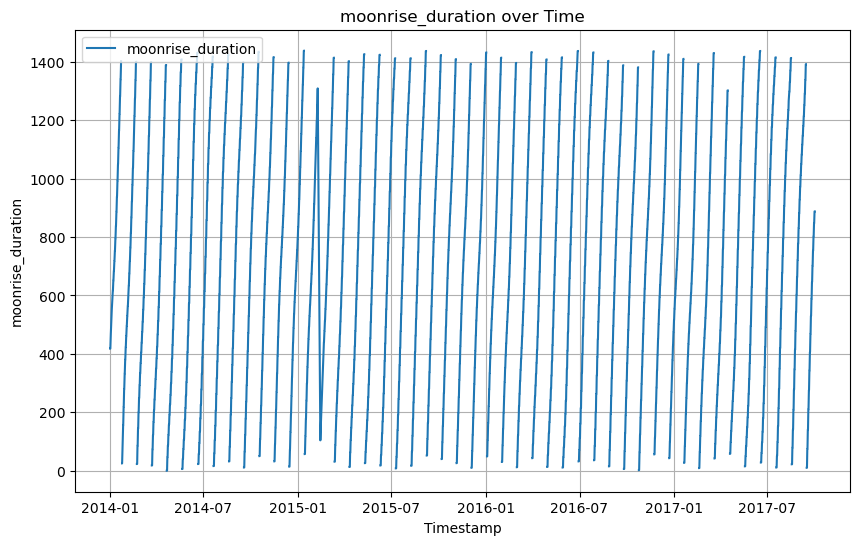

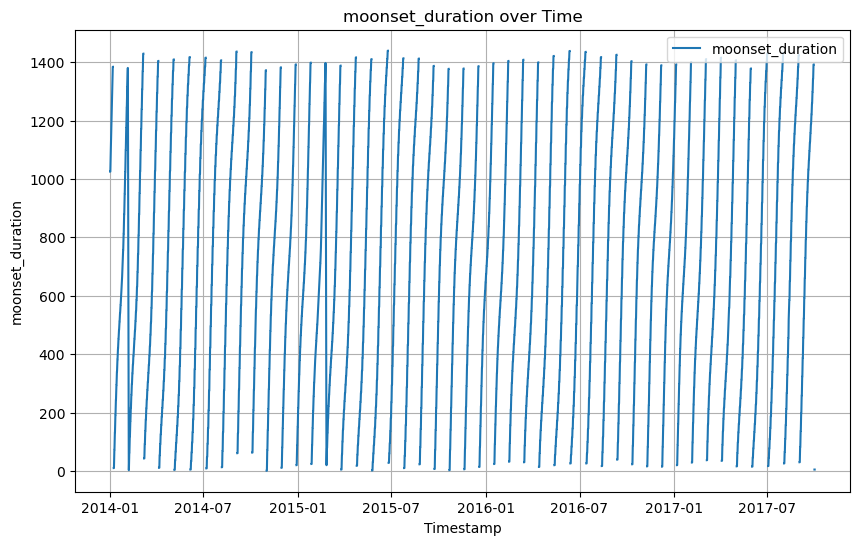

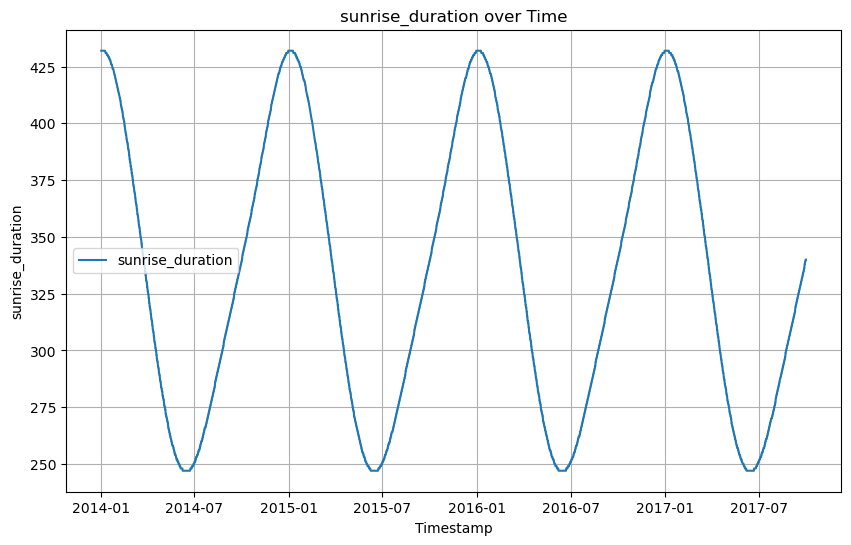

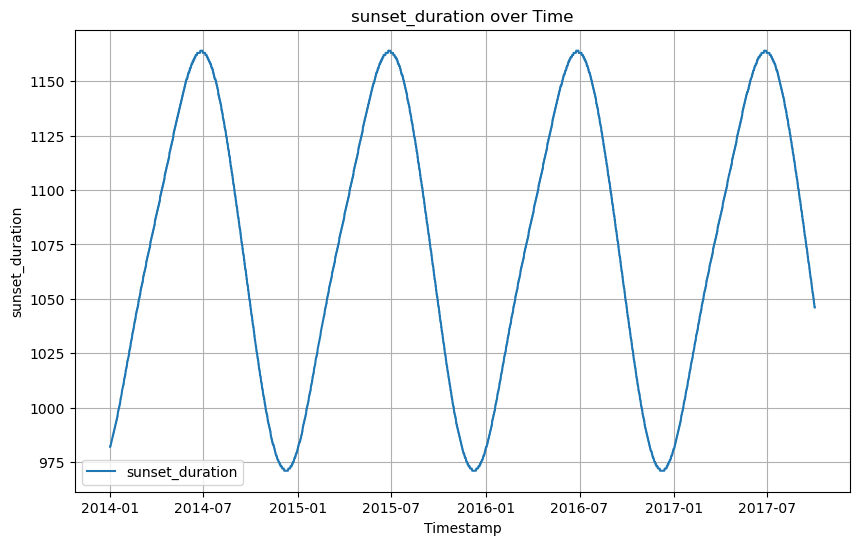

In [ ]:
def plot_time_series(data_train):

    # Cek apakah 'Timestamp' ada di data_train
    if 'Timestamp' not in data_train.columns:
        raise ValueError("'Timestamp' column is missing in data_train")

    # Plot setiap kolom dalam train_num
    for column in train_num:
        if column in data_train.columns:
            plt.figure(figsize=(10, 6))
            plt.plot(data_train['Timestamp'], data_train[column], label=column)
            plt.title(f'{column} over Time')
            plt.xlabel('Timestamp')
            plt.ylabel(column)
            plt.grid(True)
            plt.legend()
            plt.show()
        else:
            print(f"Column {column} not found in data_train")

# Contoh penggunaan:
plot_time_series(train_df)


## Scatterplot Target vs Features

In [ ]:
train_df.columns

Index(['Timestamp', '% Baseline', 'Year', 'Month', 'Day', 'Hour', 'DHI', 'DNI',
       'GHI', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type',
       'Dew Point', 'Solar Zenith Angle', 'Surface Albedo', 'Wind Speed',
       'Relative Humidity', 'Temperature', 'Pressure', 'maxtempC', 'mintempC',
       'totalSnow_cm', 'sunHour', 'uvIndex', 'moon_illumination', 'DewPointC',
       'FeelsLikeC', 'HeatIndexC', 'WindChillC', 'WindGustKmph', 'cloudcover',
       'humidity', 'precipMM', 'pressure', 'tempC', 'visibility',
       'winddirDegree', 'windspeedKmph', 'moonrise_duration',
       'moonset_duration', 'sunrise_duration', 'sunset_duration',
       'moonrise_AMPM', 'moonset_AMPM'],
      dtype='object')

In [ ]:
columns = ['Timestamp',
 'Year',
 'Month',
 'Day',
 'Hour',
 'DHI',
 'DNI',
 'GHI',
 'Clearsky DHI',
 'Clearsky DNI',
 'Clearsky GHI',
 'Cloud Type',
 'Dew Point',
 'Solar Zenith Angle',
 'Surface Albedo',
 'Wind Speed',
 'Relative Humidity',
 'Temperature',
 'Pressure']

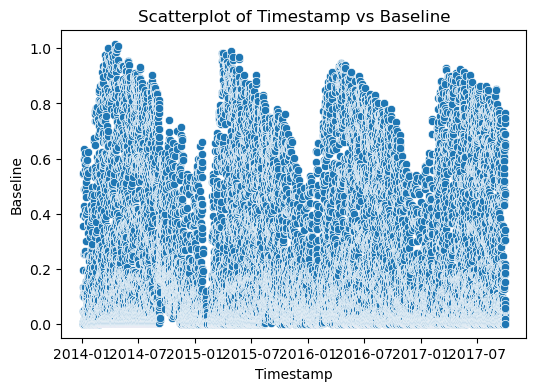

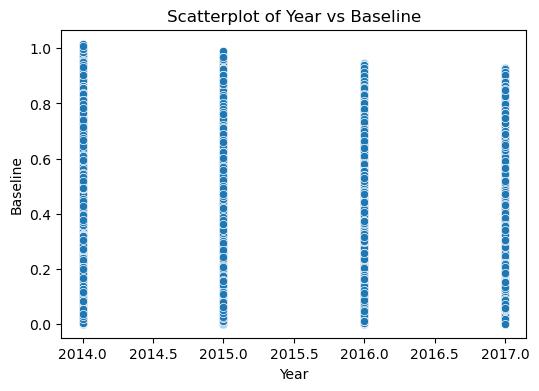

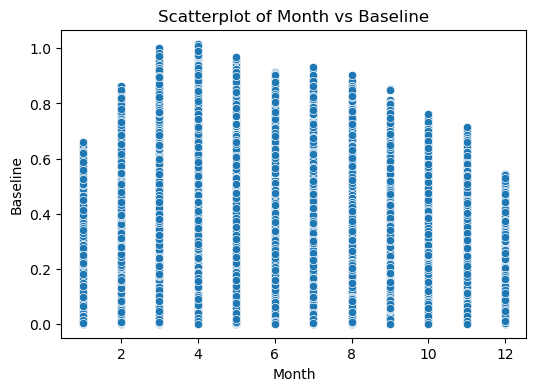

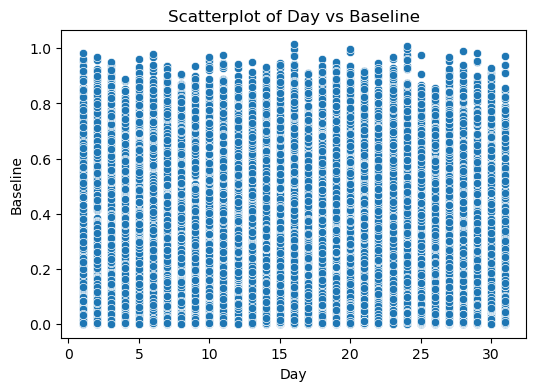

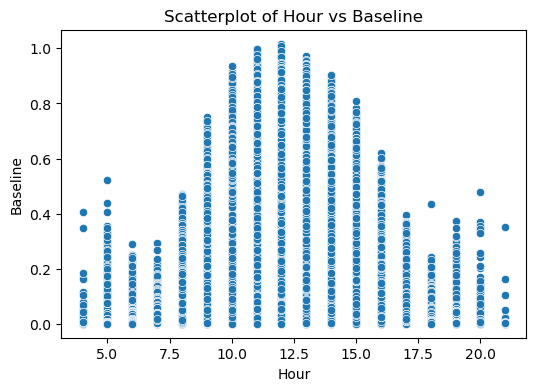

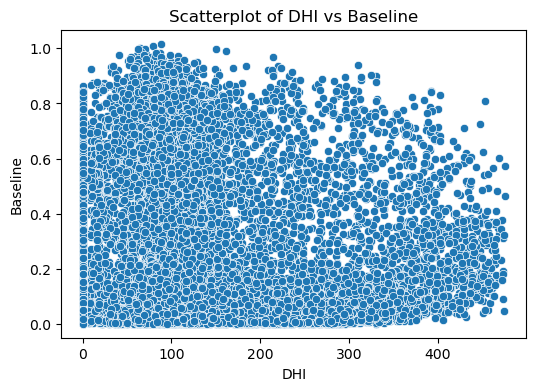

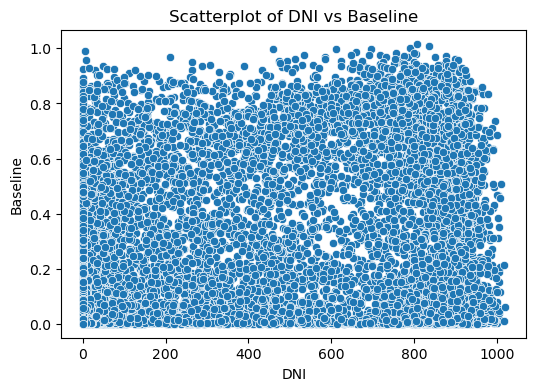

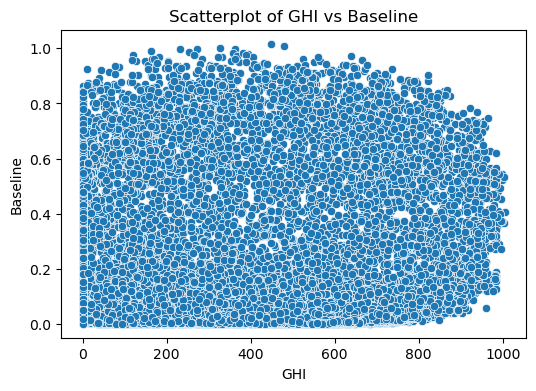

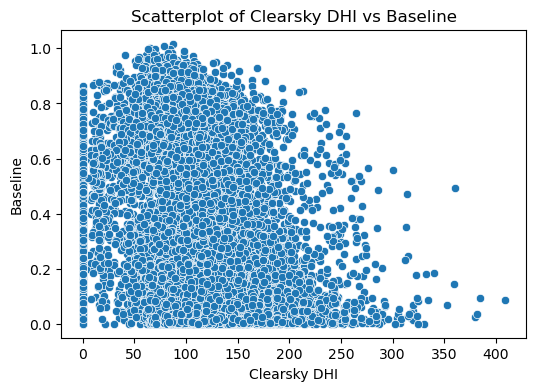

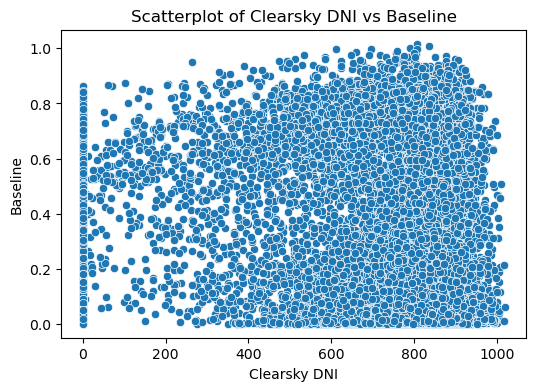

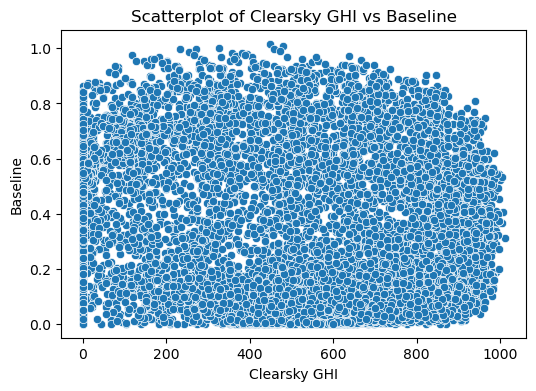

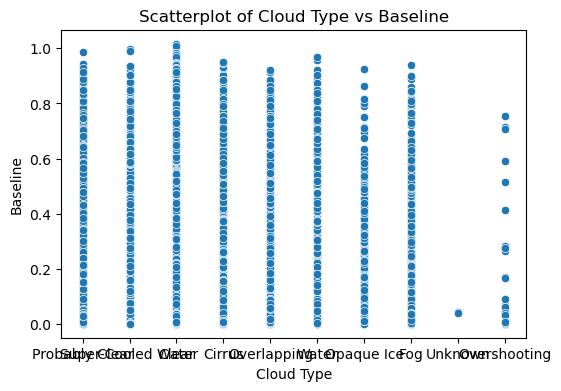

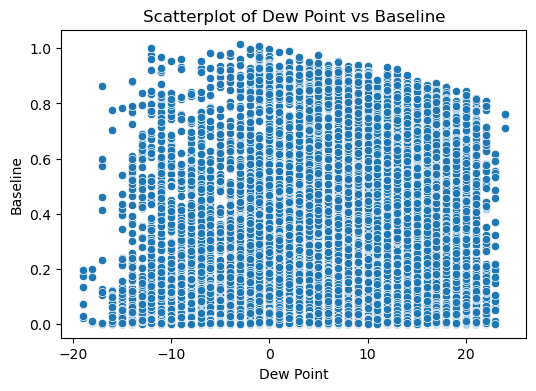

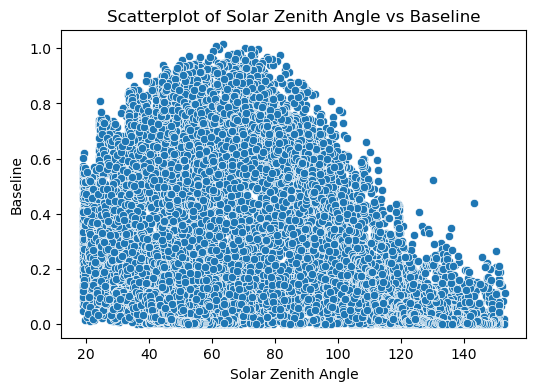

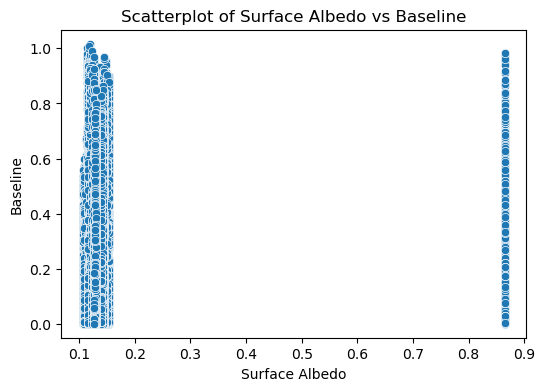

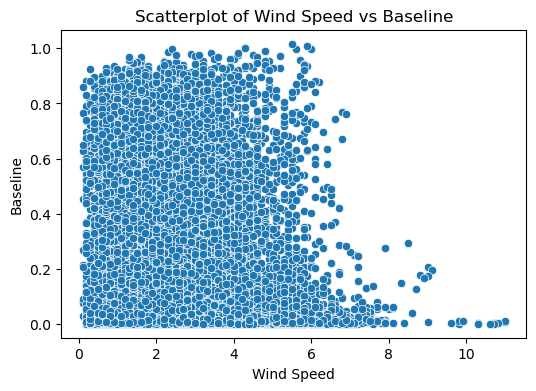

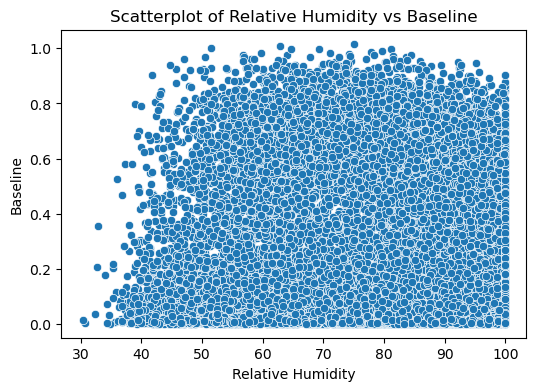

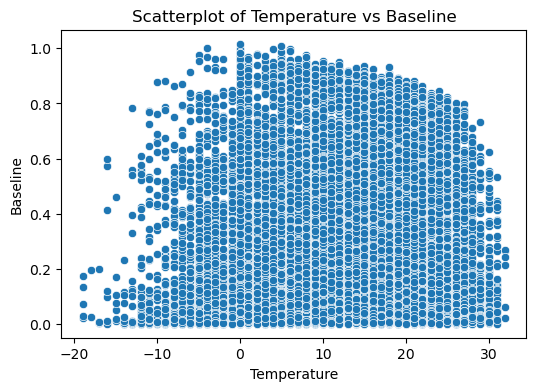

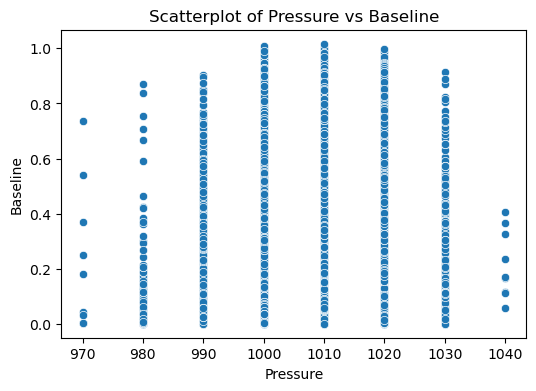

In [ ]:
for cols in columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=train_df[cols], y=train_df['% Baseline'])
    plt.title(f'Scatterplot of {cols} vs Baseline')
    plt.xlabel(cols)
    plt.ylabel('Baseline')
    plt.show()

# Modeling

## IAR

In [ ]:
import iar
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
print("iAR version:")
print(iar.__version__)

iAR version:
1.2.8


In [ ]:
train_df_iar = train_df.copy()
test_df_iar = test_df.copy()

In [ ]:
# Assuming y_valid is your DataFrame and 'Timestamp' is the column with datetime values
train_df_iar['Timestamp'] = pd.to_datetime(train_df_iar['Timestamp'])  # Ensure 'Timestamp' is in datetime format

# Calculate the number of hours since the start of the period
start_time = train_df_iar['Timestamp'].min()
train_df_iar['Hours'] = (train_df_iar['Timestamp'] - start_time).dt.total_seconds() / 3600

# Print the result to check
print(train_df_iar[['Timestamp', 'Hours']])

                Timestamp    Hours
0     2014-01-01 07:00:00      0.0
1     2014-01-01 08:00:00      1.0
2     2014-01-01 09:00:00      2.0
3     2014-01-01 10:00:00      3.0
4     2014-01-01 11:00:00      4.0
...                   ...      ...
18937 2017-09-30 14:00:00  32839.0
18938 2017-09-30 15:00:00  32840.0
18939 2017-09-30 16:00:00  32841.0
18940 2017-09-30 17:00:00  32842.0
18941 2017-09-30 18:00:00  32843.0

[18942 rows x 2 columns]


In [ ]:
# Menambahkan nilai 1 agar sesuai dengan urutan bilangan asli
train_df_iar['Hours'] = train_df_iar['Hours'] + 1

# Print the first 30 rows to check the result
print(train_df_iar['Hours'].head(30))

0       1.0
1       2.0
2       3.0
3       4.0
4       5.0
5       6.0
6       7.0
7       8.0
8       9.0
9      10.0
10     27.0
11     30.0
12     31.0
13     32.0
14     77.0
15    122.0
16    123.0
17    124.0
18    125.0
19    126.0
20    127.0
21    128.0
22    129.0
23    130.0
24    131.0
25    144.0
26    145.0
27    146.0
28    147.0
29    148.0
Name: Hours, dtype: float64


In [ ]:
# Menyesuaikan data yang bernilai 0 dengan menggantinya dengan nilai yang sangat kecil agar perhitungan tetap dapat dilakukan
train_df_iar['% Baseline'] = np.where(train_df_iar['% Baseline'] == 0, 0.0001, train_df_iar['% Baseline'])
train_df_iar.describe()

,Timestamp,% Baseline,Year,Month,Day,Hour,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,moonrise_duration,moonset_duration,sunrise_duration,sunset_duration,Hours
count,18942,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18942.000000,18313.000000,18303.000000,18942.000000,18942.000000,18942.000000
mean,2015-11-18 10:33:35.140956416,0.242342,2015.398480,6.299863,15.768345,12.053585,95.911778,273.771092,265.565203,70.321824,443.664991,349.700749,7.669412,76.417798,0.209689,2.551943,81.258677,11.410886,1007.204097,15.267976,8.814539,0.107745,10.669069,3.850966,49.917538,7.765759,11.429522,13.402597,11.127125,24.207317,39.700243,72.296378,0.104593,1016.140481,12.964154,9.290149,191.962676,15.826417,717.751270,714.891602,322.664661,1084.968799,16468.559761
min,2014-01-01 07:00:00,0.000100,2014.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.000000,18.950000,0.106000,0.100000,30.310000,-19.000000,970.000000,-12.000000,-20.000000,0.000000,3.400000,1.000000,0.000000,-22.000000,-32.000000,-20.000000,-32.000000,0.000000,0.000000,19.000000,0.000000,979.000000,-20.000000,0.000000,0.000000,0.000000,0.000000,1.000000,247.000000,971.000000,1.000000
25%,2014-11-24 08:15:00,0.031800,2014.000000,4.000000,8.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,48.160000,0.120000,1.600000,67.852500,4.000000,1000.000000,8.000000,3.000000,0.000000,8.700000,2.000000,25.000000,2.000000,3.000000,6.000000,3.000000,15.000000,9.000000,61.000000,0.000000,1011.000000,6.000000,10.000000,125.000000,10.000000,350.000000,337.000000,266.000000,1034.000000,7850.250000
50%,2015-11-15 07:30:00,0.134700,2015.000000,6.000000,16.000000,12.000000,71.000000,16.000000,140.000000,74.000000,592.000000,313.000000,9.000000,71.200000,0.132000,2.300000,85.020000,12.000000,1010.000000,16.000000,10.000000,0.000000,11.600000,4.000000,50.000000,9.000000,13.000000,14.000000,13.000000,23.000000,29.000000,73.000000,0.000000,1016.000000,14.000000,10.000000,205.000000,15.000000,718.000000,713.000000,312.000000,1096.000000,16393.500000
75%,2016-10-08 17:45:00,0.407700,2016.000000,9.000000,23.000000,16.000000,141.000000,611.000000,507.000000,119.000000,804.000000,673.000000,15.000000,106.390000,0.144000,3.300000,97.860000,19.000000,1010.000000,24.000000,16.000000,0.000000,13.700000,5.000000,75.000000,15.000000,21.000000,21.000000,21.000000,31.000000,68.000000,84.000000,0.000000,1021.000000,21.000000,10.000000,264.000000,20.000000,1085.000000,1096.000000,374.000000,1143.000000,24275.750000
max,2017-09-30 18:00:00,1.016900,2017.000000,12.000000,31.000000,21.000000,476.000000,1019.000000,1006.000000,409.000000,1019.000000,1012.000000,24.000000,153.100000,0.866000,11.000000,100.000000,32.000000,1040.000000,32.000000,23.000000,22.200000,14.500000,7.000000,100.000000,25.000000,36.000000,36.000000,32.000000,98.000000,100.000000,100.000000,8.000000,1045.000000,32.000000,10.000000,360.000000,70.000000,1438.000000,1439.000000,432.000000,1164.000000,32844.000000
std,NaN,0.256525,1.086032,3.090566,8.827215,4.259907,113.351016,351.014156,299.981246,67.811676,382.568179,343.143039,8.656976,33.997763,0.227794,1.331963,17.152132,9.383834,8.467146,9.434761,8.451514,0.829356,3.343624,1.743948,28.898236,9.079135,11.601362,9.648

In [ ]:
# Train - Validation Split
# Ambil 3799 data terakhir untuk data_validation 20%
data_val_new_iar = train_df_iar.iloc[-3789:]

# Sisanya untuk data_train 80%
data_train_new_iar = train_df_iar.iloc[:-3789]

# Display dataframes
display(data_val_new_iar.head(),data_train_new_iar.head())

,Timestamp,% Baseline,Year,Month,Day,Hour,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,moonrise_duration,moonset_duration,sunrise_duration,sunset_duration,moonrise_AMPM,moonset_AMPM,Hours
15153,2016-12-29 08:00:00,0.0386,2016,12,29,8,0.0,0.0,0.0,0.0,0.0,0.0,Overlapping,-3,130.12,0.113,2.1,78.91,0,1010,6,1,0.0,3.4,2,2,-3,-1,3,-1,20,72,64,0.0,1016,3,10,159,15,428.0,1023.0,431,980,AM,PM,26234.0
15154,2016-12-29 09:00:00,0.0556,2016,12,29,9,0.0,0.0,0.0,0.0,0.0,0.0,Overlapping,-2,119.01,0.113,2.2,81.59,0,1010,6,1,0.0,3.4,2,2,-3,0,4,0,25,82,62,0.0,1015,4,10,163,19,428.0,1023.0,431,980,AM,PM,26235.0
15155,2016-12-29 10:00:00,0.0778,2016,12,29,10,0.0,0.0,0.0,0.0,0.0,0.0,Overlapping,-2,108.09,0.113,2.5,84.49,0,1010,6,1,0.0,3.4,2,2,-2,0,4,0,28,88,67,0.0,1013,4,10,151,20,428.0,1023.0,431,980,AM,PM,26236.0
15156,2016-12-29 11:00:00,0.0710,2016,12,29,11,0.0,0.0,0.0,0.0,0.0,0.0,Overlapping,-1,97.64,0.113,2.8,88.85,0,1010,6,1,0.0,3.4,2,2,0,0,4,0,31,94,72,0.0,1011,4,10,139,21,428.0,1023.0,431,980,AM,PM,26237.0
15157,2016-12-29 12:00:00,0.0386,2016,12,29,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,87.95,0.113,3.0,85.91,1,1010,6,1,0.0,3.4,2,2,1,0,5,0,35,100,77,0.0,1009,5,10,127,23,428.0,1023.0,431,980,AM,PM,26238.0


,Timestamp,% Baseline,Year,Month,Day,Hour,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph,moonrise_duration,moonset_duration,sunrise_duration,sunset_duration,moonrise_AMPM,moonset_AMPM,Hours
0,2014-01-01 07:00:00,0.0079,2014,1,1,7,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-9,141.17,0.12,4.4,69.95,-5,1020,-3,-6,0.0,8.7,2,1,-14,-13,-5,-13,24,13,52,0.0,1027,-5,10,262,18,418.0,1025.0,432,982,AM,PM,1.0
1,2014-01-01 08:00:00,0.1019,2014,1,1,8,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-9,130.24,0.12,4.3,74.24,-6,1020,-3,-6,0.0,8.7,2,1,-14,-12,-5,-12,26,11,49,0.0,1027,-5,10,266,20,418.0,1025.0,432,982,AM,PM,2.0
2,2014-01-01 09:00:00,0.3932,2014,1,1,9,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-10,119.14,0.12,4.3,73.07,-6,1020,-3,-6,0.0,8.7,2,1,-14,-11,-4,-11,27,9,46,0.0,1028,-4,10,270,22,418.0,1025.0,432,982,AM,PM,3.0
3,2014-01-01 10:00:00,0.5447,2014,1,1,10,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-10,108.20,0.12,4.1,72.43,-6,1020,-3,-6,0.0,8.7,2,1,-14,-10,-4,-10,25,15,46,0.0,1028,-4,10,273,21,418.0,1025.0,432,982,AM,PM,4.0
4,2014-01-01 11:00:00,0.5485,2014,1,1,11,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-10,97.73,0.12,3.9,72.47,-6,1020,-3,-6,0.0,8.7,2,1,-14,-10,-3,-10,23,21,45,0.0,1027,-3,10,276,19,418.0,1025.0,432,982,AM,PM,5.0


In [ ]:
# Jika ingin memastikan array menjadi tipe numpy array (meskipun .to_numpy() sudah menghasilkan numpy array)
y_train_np = np.array(data_train_new_iar['% Baseline'])
t_train_np = np.array(data_train_new_iar['Hours'])

In [ ]:
# Jika ingin memastikan array menjadi tipe numpy array (meskipun .to_numpy() sudah menghasilkan numpy array)
y_val_np = np.array(data_val_new_iar['% Baseline'])
t_val_np = np.array(data_val_new_iar['Hours'])

### ADF test

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Contoh untuk uji Augmented Dickey-Fuller
result = adfuller(y_train_np)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -11.517436
p-value: 0.000000


In [ ]:
from iar import IARgamma
phi,mu,sigma,loglik=IARgamma(y_train_np,t_train_np)
print("Estimated parameter:",np.round(phi,4))
print("Estimated mean:",np.round(mu,4))
print("Estimated standard deviation:",np.round(sigma,4))

Estimated parameter: 0.7523
Estimated mean: 0.0832
Estimated standard deviation: 0.0445


In [ ]:
# delta t
delta_t = np.diff(t_val_np)
delta_t

array([1., 1., 1., ..., 1., 1., 1.])

In [ ]:
def forecast_IAR(phi, y_last, delta_t):
    return phi**delta_t * y_last
def multiple_forecasts(phi, y_start, delta_t_list):
    y_forecasts = [y_start]
    for delta_t in delta_t_list:
        y_next = forecast_IAR(phi, y_forecasts[-1], delta_t)
        y_forecasts.append(y_next)
    return y_forecasts[1:]  # Exclude the initial value

# Example: Forecast for the next 5 periods with varying delta_t # replace with actual time differences
forecasts = multiple_forecasts(phi, y_train_np[-1], delta_t)
print(f"Forecasts for next periods: {forecasts}")


Forecasts for next periods: [0.006921247833422929, 0.005206920823006694, 0.00391721624619998, 0.0029469591801152945, 0.002217025526147695, 0.0016678894695101156, 0.0012547691714386744, 1.7559511844268957e-05, 1.3210188403055518e-05, 9.938150854756164e-06, 7.476565768664275e-06, 5.624691807370831e-06, 4.231509346243159e-06, 3.1834048798689502e-06, 2.3949058834457557e-06, 1.801710560548996e-06, 1.3554440558320597e-06, 1.0197135037775685e-06, 1.4270091866230022e-08, 1.0735526349118554e-08, 8.076438965705605e-09, 6.075982140561134e-09, 4.571019372421213e-09, 3.4388215139026694e-09, 2.587058255720327e-09, 1.946268624711219e-09, 1.4641964676132117e-09, 1.1015289814318964e-09, 2.049028283497921e-11, 1.5415035399763356e-11, 1.15968783002989e-11, 8.724442262001428e-12, 6.563481206924003e-12, 4.93776957425379e-12, 3.714731192146272e-12, 2.794627740803365e-12, 2.1024251300281417e-12, 1.5816744974066517e-12, 1.1899088248213139e-12, 2.21342958555048e-14, 1.665184209067986e-14, 1.2527339781806383e-1

In [ ]:
forecasts = np.array(forecasts)
n=3788
residuals = np.zeros(n)
for j in range(0, n):
    residuals[j] = y_val_np[j] - forecasts[j]

# Calculate RMSE
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE of the iAR model: {rmse:.4f}")


RMSE of the iAR model: 0.3648


## Using Base Model Regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
import numpy as np
import lightgbm as lgb

# Define the preprocessing pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scaling
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# Prepare data
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

# Define and fit the LightGBM model
lgbm_model = LGBMRegressor(verbose=-1)
lgbm_model.fit(X_train_preprocessed, y_train)

# Predict on the validation set
y_pred = lgbm_model.predict(X_val_preprocessed)

# Round predictions to 4 decimal places and ensure non-negative
y_pred = np.round(y_pred, 4)
y_pred = np.maximum(y_pred, 0)

# Calculate RMSE
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f'LightGBM Model RMSE: {rmse:.5f}')

# Feature Importance
feature_importances = lgbm_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)


LightGBM Model RMSE: 0.08996
                               Feature  Importance
3                            num__Hour         367
28                     num__cloudcover         184
29                       num__humidity         180
38               num__sunrise_duration         164
11             num__Solar Zenith Angle         162
39                num__sunset_duration         117
34                  num__winddirDegree         100
1                           num__Month          99
0                            num__Year          96
12                 num__Surface Albedo          93
20                        num__sunHour          91
37               num__moonset_duration          89
36              num__moonrise_duration          83
14              num__Relative Humidity          79
31                       num__pressure          79
18                       num__mintempC          74
17                       num__maxtempC          64
13                     num__Wind Speed          61
22

/tmp/ipykernel_3016/2153369198.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')


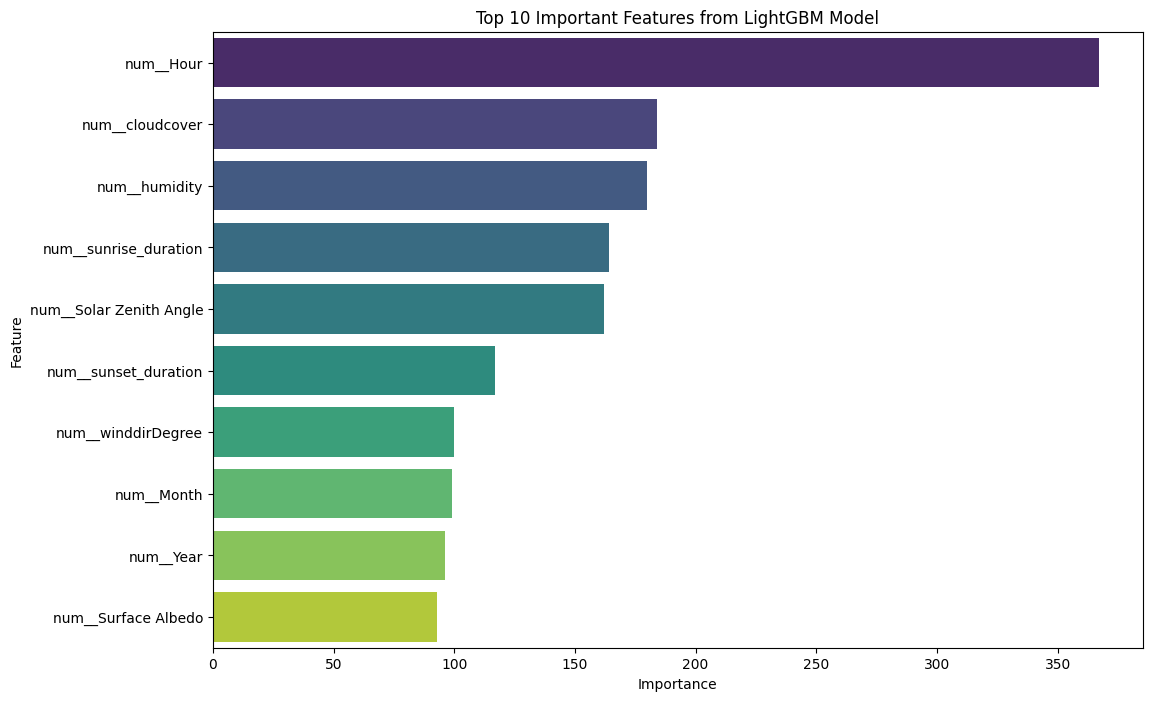

In [ ]:
feature_importances = lgbm_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Select top 10 features
# Select top 10 features
top_10_importance_df = importance_df.head(10)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Feature Importance', fontsize=16, fontweight='bold')  # Bold title
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')  # Bold y-axis label

# Make y-ticks bold
plt.yticks(fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add gridlines for the x-axis
plt.show()


## Stacking

In [ ]:
# The target column
target_column = '% Baseline'

# Step 1: Identify numerical and categorical columns
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Remove target column from numerical columns
numerical_columns = numerical_columns.drop(target_column)

# Step 2: Apply backward fill to missing values
train_df_filled = train_df.fillna(method='bfill')
train_df_filled = train_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Split the data (80-20) based on time
train_size = int(len(train_df_filled) * 0.8)
train_data = train_df_filled[:train_size]
validation_data = train_df_filled[train_size:]

# Prepare features and target
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Define the preprocessing pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scaling
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# Define base models for stacking
estimators_2 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor())
]

estimators_3 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0))
]

estimators_4 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0)),
    ('extra_trees', ExtraTreesRegressor())
]

estimators_5 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0)),
    ('extra_trees', ExtraTreesRegressor()),
    ('XGBoost', XGBRegressor())
]

# Define the final estimator
final_estimator = LinearRegression()

# Function to create, evaluate, and save a stacking model
def evaluate_and_save_stacking_model(estimators, X_train, y_train, X_val, y_val, final_estimator, model_name):
    stacking_model = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        passthrough=False  # Set to True if you want to include the original features along with predictions
    )

    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('stacking', stacking_model)
    ])

    # Fit the pipeline on the training data
    stacking_pipeline.fit(X_train, y_train)

    # Predict on the validation set
    y_pred = stacking_pipeline.predict(X_val)

    # Round predictions to 4 decimal places
    y_pred = np.round(y_pred, 4)

    # Calculate RMSE
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    print(f'{model_name} Stacking Model RMSE: {rmse:.5f}')

    # Save the model
    joblib.dump(stacking_pipeline, f'{model_name}_stacking_model.pkl')

# Evaluate and save stacking models with 2, 3, 4, and 5 estimators
evaluate_and_save_stacking_model(estimators_2, X_train, y_train, X_val, y_val, final_estimator, '2_estimators')
evaluate_and_save_stacking_model(estimators_3, X_train, y_train, X_val, y_val, final_estimator, '3_estimators')
evaluate_and_save_stacking_model(estimators_4, X_train, y_train, X_val, y_val, final_estimator, '4_estimators')
evaluate_and_save_stacking_model(estimators_5, X_train, y_train, X_val, y_val, final_estimator, '5_estimators')

## Tunning

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Suggest hyperparameters for each base model
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 100)
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 50, 100)
    catboost_depth = trial.suggest_int('catboost_depth', 3, 10)
    xgboost_max_depth = trial.suggest_int('xgboost_max_depth', 3, 10)
    extra_trees_n_estimators = trial.suggest_int('extra_trees_n_estimators', 50, 100)

    # Create the base models with the suggested hyperparameters
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=rf_n_estimators)),
        ('lightgbm', LGBMRegressor(n_estimators=lgbm_n_estimators, verbose=-1)),
        ('catboost', CatBoostRegressor(depth=catboost_depth, verbose=0)),
        ('xgboost', XGBRegressor(max_depth=xgboost_max_depth)),
        ('extra_trees', ExtraTreesRegressor(n_estimators=extra_trees_n_estimators))
    ]

    # Define the meta-model
    meta_model = LinearRegression()

    # Define the stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True
    )

    # Create a pipeline
    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Assume 'preprocessor' is already defined
        ('stacking', stacking_regressor)
    ])

    # Cross-validate the stacking model and return the negative MSE
    score = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Return the mean of the cross-validated MSE as the objective value
    return score.mean()


In [ ]:
def objective(trial):
    # Suggest hyperparameters for each base model with narrower search ranges
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 70, 90)
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 70, 90)
    catboost_depth = trial.suggest_int('catboost_depth', 4, 6)
    xgboost_max_depth = trial.suggest_int('xgboost_max_depth', 4, 6)
    extra_trees_n_estimators = trial.suggest_int('extra_trees_n_estimators', 70, 90)

    # Create the base models with the suggested hyperparameters
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=rf_n_estimators)),
        ('lightgbm', LGBMRegressor(n_estimators=lgbm_n_estimators, verbose=-1)),
        ('catboost', CatBoostRegressor(depth=catboost_depth, verbose=0)),
        ('xgboost', XGBRegressor(max_depth=xgboost_max_depth)),
        ('extra_trees', ExtraTreesRegressor(n_estimators=extra_trees_n_estimators))
    ]

    # Define the meta-model
    meta_model = LinearRegression()

    # Define the stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True
    )

    # Create a pipeline
    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Assume 'preprocessor' is already defined
        ('stacking', stacking_regressor)
    ])

    # Cross-validate the stacking model and return the negative MSE
    score = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Return the mean of the cross-validated MSE as the objective value
    return score.mean()


In [ ]:
# Create a study object
study = optuna.create_study(direction='maximize')  # We maximize the negative MSE, which means we minimize the actual MSE

# Optimize the objective function
study.optimize(objective, n_trials=5)

# Get the best trial
best_trial = study.best_trial

# Output the best hyperparameters
print("Best trial:")
print("  Value: {}".format(best_trial.value))
print("  Params: ")
for key, value in best_trial.params.items():
    print("    {}: {}".format(key, value))


[I 2024-08-28 09:12:14,172] A new study created in memory with name: no-name-9643b1d2-0b8b-49c3-9b5d-ba7a50fe5b1e
[I 2024-08-28 09:28:04,073] Trial 0 finished with value: -0.01015954889072854 and parameters: {'rf_n_estimators': 88, 'lgbm_n_estimators': 73, 'catboost_depth': 6, 'xgboost_max_depth': 5, 'extra_trees_n_estimators': 89}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 09:43:21,449] Trial 1 finished with value: -0.010224251874682514 and parameters: {'rf_n_estimators': 85, 'lgbm_n_estimators': 89, 'catboost_depth': 6, 'xgboost_max_depth': 4, 'extra_trees_n_estimators': 83}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 09:58:05,879] Trial 2 finished with value: -0.010190006255281443 and parameters: {'rf_n_estimators': 81, 'lgbm_n_estimators': 84, 'catboost_depth': 6, 'xgboost_max_depth': 5, 'extra_trees_n_estimators': 79}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 10:28:09,498] Trial 4 finished with value: -0.01019085182

Best trial:
  Value: -0.01015954889072854
  Params: 
    rf_n_estimators: 88
    lgbm_n_estimators: 73
    catboost_depth: 6
    xgboost_max_depth: 5
    extra_trees_n_estimators: 89


In [ ]:
# Extract the best hyperparameters
best_params = best_trial.params

# Create base models with the best parameters
base_models = [
    ('random_forest', RandomForestRegressor(n_estimators=best_params['rf_n_estimators'])),
    ('lightgbm', LGBMRegressor(n_estimators=best_params['lgbm_n_estimators'])),
    ('catboost', CatBoostRegressor(depth=best_params['catboost_depth'], verbose=0)),
    ('xgboost', XGBRegressor(max_depth=best_params['xgboost_max_depth'])),
    ('extra_trees', ExtraTreesRegressor(n_estimators=best_params['extra_trees_n_estimators']))
]

meta_model = LinearRegression()

# Define the stacking regressor
stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True
)

# Create the pipeline
stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_regressor)
])

# Fit the stacking model on the training data
stacking_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_pred_stack = stacking_pipeline.predict(X_val)

# Calculate MSE
mse_stack = mean_squared_error(y_val, y_pred_stack)
print(f'Stacking Regressor MSE: {mse_stack:.5f}')


Stacking Regressor MSE: 0.00776


# Predict Test Data

In [ ]:
# Assume you have decided that the model with the lowest RMSE is the best model, say it's the '4_estimators' model.
test_df_filled = test_df.fillna(method='bfill')
test_df_filled = test_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Load the best model
#best_model = joblib.load('5_estimators_SVR_final_stacking_model.pkl')
best_model = stacking_pipeline
# Predict on the test dataset
X_test = test_df_filled
y_test_pred = best_model.predict(X_test)

/tmp/ipykernel_3016/487210288.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df_filled = test_df.fillna(method='bfill')
/tmp/ipykernel_3016/487210288.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df_filled = test_df_filled.fillna(method='ffill')  # In case there are still any NaNs


In [ ]:
# If you want to create a DataFrame with the predictions
predictions_df = pd.DataFrame({
    'Timestamp': test['Timestamp'],
    '% Baseline': y_test_pred
})

# Display the first few rows of the predictions
print(predictions_df.head())

            Timestamp  % Baseline
0 2017-10-01 06:00:00    0.010254
1 2017-10-01 07:00:00    0.031158
2 2017-10-01 08:00:00    0.105851
3 2017-10-01 09:00:00    0.315648
4 2017-10-01 10:00:00    0.478708


In [ ]:
import pandas as pd

# Assuming 'check' is your DataFrame
predictions_df['% Baseline'] = predictions_df['% Baseline'].apply(lambda x: max(x, 0))

# Display the first few rows of the predictions
print(predictions_df.head())

            Timestamp  % Baseline
0 2017-10-01 06:00:00    0.010254
1 2017-10-01 07:00:00    0.031158
2 2017-10-01 08:00:00    0.105851
3 2017-10-01 09:00:00    0.315648
4 2017-10-01 10:00:00    0.478708


In [ ]:
predictions_df.describe()

,Timestamp,% Baseline
count,1077,1077.000000
mean,2017-11-14 10:16:12.701949952,0.158927
min,2017-10-01 06:00:00,0.000000
25%,2017-10-21 17:00:00,0.025422
50%,2017-11-14 12:00:00,0.092533
75%,2017-12-06 07:00:00,0.248441
max,2017-12-31 16:00:00,0.715854
std,NaN,0.168961


In [ ]:
# Save predictions_df in csv format
predictions_df.to_csv('predictions_16_tuning_rev.csv', index=False)


Feature Importances for random_forest:
Model random_forest does not support feature importances.

Feature Importances for lightgbm:
Model lightgbm does not support feature importances.

Feature Importances for catboost:


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

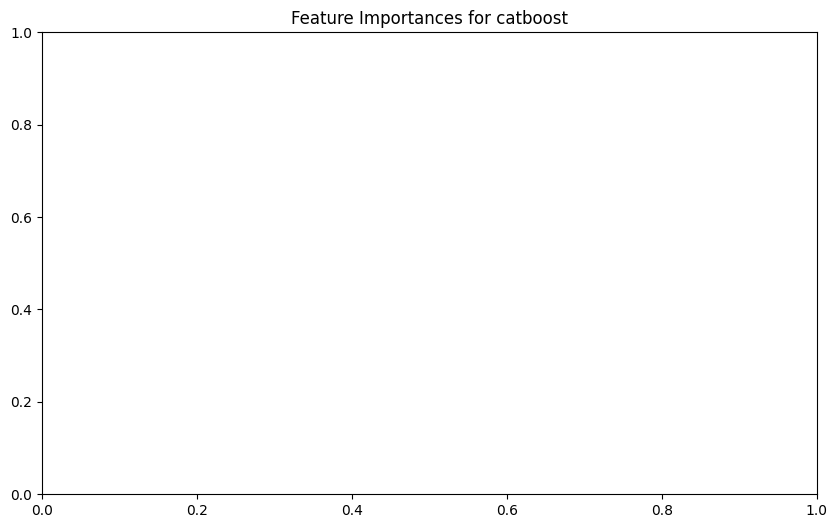

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot feature importances
def plot_feature_importances(importances, feature_names, model_name):
    indices = np.argsort(importances)
    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances for {model_name}')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.show()

# Extract feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Loop through each base model to extract and plot feature importances
for name, model in base_models:
    print(f"\nFeature Importances for {name}:")

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        plot_feature_importances(importances, feature_names, name)

    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
        plot_feature_importances(importances, feature_names, name)

    else:
        print(f"Model {name} does not support feature importances.")

# For the stacking regressor final estimator if it supports feature importances
if hasattr(stacking_regressor.final_estimator_, 'feature_importances_'):
    print("\nFeature Importances for Meta Model (Final Estimator):")
    meta_importances = stacking_regressor.final_estimator_.feature_importances_
    plot_feature_importances(meta_importances, feature_names, 'Meta Model')
else:
    print("Final estimator does not support feature importances.")


In [ ]:
def objective(trial):
    # Suggest hyperparameters for each base model with narrower search ranges
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 70, 90)
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 70, 90)
    catboost_depth = trial.suggest_int('catboost_depth', 4, 6)
    xgboost_max_depth = trial.suggest_int('xgboost_max_depth', 4, 6)
    extra_trees_n_estimators = trial.suggest_int('extra_trees_n_estimators', 70, 90)

    # Create the base models with the suggested hyperparameters
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=rf_n_estimators)),
        ('lightgbm', LGBMRegressor(n_estimators=lgbm_n_estimators, verbose=-1)),
        ('catboost', CatBoostRegressor(depth=catboost_depth, verbose=0)),
        ('xgboost', XGBRegressor(max_depth=xgboost_max_depth)),
        ('extra_trees', ExtraTreesRegressor(n_estimators=extra_trees_n_estimators))
    ]

    # Define the meta-model
    meta_model = LinearRegression()

    # Define the stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True
    )

    # Create a pipeline
    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Assume 'preprocessor' is already defined
        ('stacking', stacking_regressor)
    ])

    # Cross-validate the stacking model and return the negative MSE
    score = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Return the mean of the cross-validated MSE as the objective value
    return score.mean()


# Library

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as mno
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define regression models
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import VotingRegressor

import joblib  # Import joblib for saving/loading models

# Data

## Input Data

In [ ]:
train = pd.read_csv(r'train.csv')
test = pd.read_csv(r'test.csv')
weather = pd.read_csv(r'Weather.csv')

In [ ]:
Solar_2014 = pd.read_csv(r'Solar_Irradiance_2014.csv')
Solar_2015 = pd.read_csv(r'Solar_Irradiance_2015.csv')
Solar_2016 = pd.read_csv(r'Solar_Irradiance_2016.csv')
Solar_2017 = pd.read_csv(r'Solar_Irradiance_2017.csv')

In [ ]:
train

,Timestamp,% Baseline
0,"Jan 1, 2014 7am",0.0079
1,"Jan 1, 2014 8am",0.1019
2,"Jan 1, 2014 9am",0.3932
3,"Jan 1, 2014 10am",0.5447
4,"Jan 1, 2014 11am",0.5485
...,...,...
18937,"Sep 30, 2017 2pm",0.1846
18938,"Sep 30, 2017 3pm",0.0711
18939,"Sep 30, 2017 4pm",0.0560
18940,"Sep 30, 2017 5pm",0.0182


In [ ]:
test

,Timestamp,% Baseline
0,"Oct 1, 2017 6am",NaN
1,"Oct 1, 2017 7am",NaN
2,"Oct 1, 2017 8am",NaN
3,"Oct 1, 2017 9am",NaN
4,"Oct 1, 2017 10am",NaN
...,...,...
1072,"Dec 31, 2017 12pm",NaN
1073,"Dec 31, 2017 1pm",NaN
1074,"Dec 31, 2017 2pm",NaN
1075,"Dec 31, 2017 3pm",NaN


In [ ]:
weather

,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,moonrise,moonset,sunrise,sunset,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,1/1/2014 0:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-11,-5,-11,28,3,58,0.0,1022,-4,10,273,20
1,1/1/2014 1:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,31,4,58,0.0,1023,-5,10,274,22
2,1/1/2014 2:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,34,5,58,0.0,1024,-5,10,276,25
3,1/1/2014 3:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-13,-5,-13,36,6,58,0.0,1024,-5,10,278,27
4,1/1/2014 4:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-13,-13,-6,-13,32,9,57,0.0,1025,-6,10,271,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,12/31/2017 19:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,33,4,68,0.0,1022,-12,10,309,27
35060,12/31/2017 20:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,34,2,69,0.0,1022,-12,10,308,27
35061,12/31/2017 21:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,34,0,70,0.0,1023,-13,10,308,28
35062,12/31/2017 22:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,33,0,71,0.0,1023,-13,10,309,27


In [ ]:
Solar_2017

,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure
0,2017,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Overlapping,1,123.98,0.109,5.1,85.43,4,1010
1,2017,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,Opaque Ice,2,135.06,0.109,5.2,90.60,4,1000
2,2017,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,Opaque Ice,3,145.73,0.109,5.1,88.62,5,1000
3,2017,1,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,Opaque Ice,3,155.03,0.109,4.8,90.55,5,1000
4,2017,1,1,4,0,0.0,0.0,0.0,0.0,0.0,0.0,Opaque Ice,3,160.53,0.109,4.6,95.19,4,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2017,12,31,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,75.29,0.866,4.8,67.82,-9,1010
8756,2017,12,31,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,83.05,0.866,4.8,73.91,-10,1010
8757,2017,12,31,21,0,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-13,92.18,0.866,4.8,79.66,-11,1010
8758,2017,12,31,22,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-13,102.27,0.866,4.9,85.39,-12,1010


## Data Info

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18942 entries, 0 to 18941
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Timestamp   18942 non-null  object 
 1   % Baseline  18942 non-null  float64
dtypes: float64(1), object(1)
memory usage: 296.1+ KB


In [ ]:
train.describe()

,% Baseline
count,18942.000000
mean,0.242342
std,0.256525
min,0.000000
25%,0.031800
50%,0.134700
75%,0.407700
max,1.016900


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date_time          35064 non-null  object 
 1   maxtempC           35064 non-null  int64  
 2   mintempC           35064 non-null  int64  
 3   totalSnow_cm       35064 non-null  float64
 4   sunHour            35064 non-null  float64
 5   uvIndex            35064 non-null  int64  
 6   moon_illumination  35064 non-null  int64  
 7   moonrise           35064 non-null  object 
 8   moonset            35064 non-null  object 
 9   sunrise            35064 non-null  object 
 10  sunset             35064 non-null  object 
 11  DewPointC          35064 non-null  int64  
 12  FeelsLikeC         35064 non-null  int64  
 13  HeatIndexC         35064 non-null  int64  
 14  WindChillC         35064 non-null  int64  
 15  WindGustKmph       35064 non-null  int64  
 16  cloudcover         350

In [ ]:
Solar_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                8760 non-null   int64  
 1   Month               8760 non-null   int64  
 2   Day                 8760 non-null   int64  
 3   Hour                8760 non-null   int64  
 4   Minute              8760 non-null   int64  
 5   DHI                 7770 non-null   float64
 6   DNI                 7770 non-null   float64
 7   GHI                 7770 non-null   float64
 8   Clearsky DHI        7770 non-null   float64
 9   Clearsky DNI        7770 non-null   float64
 10  Clearsky GHI        7770 non-null   float64
 11  Cloud Type          7922 non-null   object 
 12  Dew Point           8760 non-null   int64  
 13  Solar Zenith Angle  8760 non-null   float64
 14  Surface Albedo      8760 non-null   float64
 15  Wind Speed          8760 non-null   float64
 16  Relati

# Cleaning Data

## Combine Data

### Train

In [ ]:
# Convert 'Timestamp' to datetime
train['Timestamp'] = pd.to_datetime(train['Timestamp'], format='%b %d, %Y %I%p')

# Display the DataFrame with new columns
train

,Timestamp,% Baseline
0,2014-01-01 07:00:00,0.0079
1,2014-01-01 08:00:00,0.1019
2,2014-01-01 09:00:00,0.3932
3,2014-01-01 10:00:00,0.5447
4,2014-01-01 11:00:00,0.5485
...,...,...
18937,2017-09-30 14:00:00,0.1846
18938,2017-09-30 15:00:00,0.0711
18939,2017-09-30 16:00:00,0.0560
18940,2017-09-30 17:00:00,0.0182


In [ ]:
train.describe()

,Timestamp,% Baseline
count,18942,18942.000000
mean,2015-11-18 10:33:35.140956416,0.242342
min,2014-01-01 07:00:00,0.000000
25%,2014-11-24 08:15:00,0.031800
50%,2015-11-15 07:30:00,0.134700
75%,2016-10-08 17:45:00,0.407700
max,2017-09-30 18:00:00,1.016900
std,NaN,0.256525


### Test

In [ ]:
# Convert 'Timestamp' to datetime
test['Timestamp'] = pd.to_datetime(test['Timestamp'], format='%b %d, %Y %I%p')

# Display the DataFrame with new columns
test

,Timestamp,% Baseline
0,2017-10-01 06:00:00,NaN
1,2017-10-01 07:00:00,NaN
2,2017-10-01 08:00:00,NaN
3,2017-10-01 09:00:00,NaN
4,2017-10-01 10:00:00,NaN
...,...,...
1072,2017-12-31 12:00:00,NaN
1073,2017-12-31 13:00:00,NaN
1074,2017-12-31 14:00:00,NaN
1075,2017-12-31 15:00:00,NaN


In [ ]:
test.describe()

,Timestamp,% Baseline
count,1077,0.0
mean,2017-11-14 10:16:12.701949952,NaN
min,2017-10-01 06:00:00,NaN
25%,2017-10-21 17:00:00,NaN
50%,2017-11-14 12:00:00,NaN
75%,2017-12-06 07:00:00,NaN
max,2017-12-31 16:00:00,NaN
std,NaN,NaN


### Weather

In [ ]:
# Convert the 'date_time' column to datetime objects
weather['date_time'] = pd.to_datetime(weather['date_time'], format='%m/%d/%Y %H:%M')

# Change column name from 'date_time' to 'Timestamp'
weather = weather.rename(columns={'date_time': 'Timestamp'})

In [ ]:
pd.set_option('display.max_columns', None)
weather

,Timestamp,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,moon_illumination,moonrise,moonset,sunrise,sunset,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2014-01-01 00:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-11,-5,-11,28,3,58,0.0,1022,-4,10,273,20
1,2014-01-01 01:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,31,4,58,0.0,1023,-5,10,274,22
2,2014-01-01 02:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-12,-5,-12,34,5,58,0.0,1024,-5,10,276,25
3,2014-01-01 03:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-12,-13,-5,-13,36,6,58,0.0,1024,-5,10,278,27
4,2014-01-01 04:00:00,-3,-6,0.0,8.7,2,1,6:58 AM,5:05 PM,7:12 AM,4:22 PM,-13,-13,-6,-13,32,9,57,0.0,1025,-6,10,271,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-12-31 19:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,33,4,68,0.0,1022,-12,10,309,27
35060,2017-12-31 20:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-22,-12,-22,34,2,69,0.0,1022,-12,10,308,27
35061,2017-12-31 21:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,34,0,70,0.0,1023,-13,10,308,28
35062,2017-12-31 22:00:00,-9,-13,0.2,8.7,1,88,3:18 PM,5:13 AM,7:12 AM,4:21 PM,-17,-23,-13,-23,33,0,71,0.0,1023,-13,10,309,27


### Solar

In [ ]:
# Concatenate the DataFrames into one
solar = pd.concat([Solar_2014, Solar_2015, Solar_2016, Solar_2017], ignore_index=True)

# Optionally, print the head of the new DataFrame to check the result
solar

,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure
0,2014,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,124.02,0.120,3.5,78.43,-3,1010
1,2014,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,135.09,0.120,3.8,81.74,-3,1010
2,2014,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,145.77,0.120,4.2,81.25,-3,1010
3,2014,1,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,155.07,0.120,4.5,74.14,-3,1010
4,2014,1,1,4,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-8,160.55,0.120,4.6,72.80,-4,1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017,12,31,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,75.29,0.866,4.8,67.82,-9,1010
35060,2017,12,31,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,83.05,0.866,4.8,73.91,-10,1010
35061,2017,12,31,21,0,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-13,92.18,0.866,4.8,79.66,-11,1010
35062,2017,12,31,22,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-13,102.27,0.866,4.9,85.39,-12,1010


In [ ]:
# Combine the Year, Month, Day, Hour, and Minute columns to create a datetime object
solar['Timestamp'] = pd.to_datetime(solar[['Year', 'Month', 'Day', 'Hour', 'Minute']])

# Convert the datetime object to the desired string format
solar['Timestamp'] = solar['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Move the 'Timestamp' column to the first position
columns = ['Timestamp'] + [col for col in solar.columns if col != 'Timestamp']
solar = solar[columns]
solar

,Timestamp,Year,Month,Day,Hour,Minute,DHI,DNI,GHI,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Solar Zenith Angle,Surface Albedo,Wind Speed,Relative Humidity,Temperature,Pressure
0,2014-01-01 00:00:00,2014,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,124.02,0.120,3.5,78.43,-3,1010
1,2014-01-01 01:00:00,2014,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,135.09,0.120,3.8,81.74,-3,1010
2,2014-01-01 02:00:00,2014,1,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-5,145.77,0.120,4.2,81.25,-3,1010
3,2014-01-01 03:00:00,2014,1,1,3,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-6,155.07,0.120,4.5,74.14,-3,1010
4,2014-01-01 04:00:00,2014,1,1,4,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-8,160.55,0.120,4.6,72.80,-4,1010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-12-31 19:00:00,2017,12,31,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,75.29,0.866,4.8,67.82,-9,1010
35060,2017-12-31 20:00:00,2017,12,31,20,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13,83.05,0.866,4.8,73.91,-10,1010
35061,2017-12-31 21:00:00,2017,12,31,21,0,0.0,0.0,0.0,0.0,0.0,0.0,Super-Cooled Water,-13,92.18,0.866,4.8,79.66,-11,1010
35062,2017-12-31 22:00:00,2017,12,31,22,0,0.0,0.0,0.0,0.0,0.0,0.0,Probably Clear,-13,102.27,0.866,4.9,85.39,-12,1010


### Combine

In [ ]:
# Convert the 'Timestamp' column in each DataFrame to datetime format
train['Timestamp'] = pd.to_datetime(train['Timestamp'])
test['Timestamp'] = pd.to_datetime(test['Timestamp'])
solar['Timestamp'] = pd.to_datetime(solar['Timestamp'])
weather['Timestamp'] = pd.to_datetime(weather['Timestamp'])

In [ ]:
# Merge the DataFrames on the 'Timestamp' column
train_df = pd.merge(train, solar, on='Timestamp', how='inner')
train_df = pd.merge(train_df, weather, on='Timestamp', how='inner')

test_df = pd.merge(test, solar, on='Timestamp', how='inner')
test_df = pd.merge(test_df, weather, on='Timestamp', how='inner')

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18942 entries, 0 to 18941
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           18942 non-null  datetime64[ns]
 1   % Baseline          18942 non-null  float64       
 2   Year                18942 non-null  int64         
 3   Month               18942 non-null  int64         
 4   Day                 18942 non-null  int64         
 5   Hour                18942 non-null  int64         
 6   Minute              18942 non-null  int64         
 7   DHI                 17898 non-null  float64       
 8   DNI                 17898 non-null  float64       
 9   GHI                 17898 non-null  float64       
 10  Clearsky DHI        17898 non-null  float64       
 11  Clearsky DNI        17898 non-null  float64       
 12  Clearsky GHI        17898 non-null  float64       
 13  Cloud Type          17965 non-null  object    

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           1077 non-null   datetime64[ns]
 1   % Baseline          0 non-null      float64       
 2   Year                1077 non-null   int64         
 3   Month               1077 non-null   int64         
 4   Day                 1077 non-null   int64         
 5   Hour                1077 non-null   int64         
 6   Minute              1077 non-null   int64         
 7   DHI                 910 non-null    float64       
 8   DNI                 910 non-null    float64       
 9   GHI                 910 non-null    float64       
 10  Clearsky DHI        910 non-null    float64       
 11  Clearsky DNI        910 non-null    float64       
 12  Clearsky GHI        910 non-null    float64       
 13  Cloud Type          965 non-null    object      

### Check Unique Values

In [ ]:
# Give me unique values from each column
for col in train_df.columns:
    print(col, train_df[col].unique())


Timestamp <DatetimeArray>
['2014-01-01 07:00:00', '2014-01-01 08:00:00', '2014-01-01 09:00:00',
 '2014-01-01 10:00:00', '2014-01-01 11:00:00', '2014-01-01 12:00:00',
 '2014-01-01 13:00:00', '2014-01-01 14:00:00', '2014-01-01 15:00:00',
 '2014-01-01 16:00:00',
 ...
 '2017-09-30 09:00:00', '2017-09-30 10:00:00', '2017-09-30 11:00:00',
 '2017-09-30 12:00:00', '2017-09-30 13:00:00', '2017-09-30 14:00:00',
 '2017-09-30 15:00:00', '2017-09-30 16:00:00', '2017-09-30 17:00:00',
 '2017-09-30 18:00:00']
Length: 18942, dtype: datetime64[ns]
% Baseline [0.0079 0.1019 0.3932 ... 0.7638 0.7457 0.6491]
Year [2014 2015 2016 2017]
Month [ 1  2  3  4  5  6  7  8  9 10 11 12]
Day [ 1  2  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27
 28 29 30 31  3 25  5]
Hour [ 7  8  9 10 11 12 13 14 15 16 17  6 18  5 19 20  4 21]
Minute [0]
DHI [  0.  15.  47.  62.  69. 135.  nan 114.  27. 106. 115. 144. 161.  17.
  52.  67.  70.  71.  43.  74. 123.  65.  16.  49.  63.  12.  50. 132.
  35. 111. 103. 

## Sunrise Moonrise Cleaning

In [ ]:
# Function to convert time to minutes
def convert_to_minutes(time_str):
    if time_str in ["No moonrise", "No moonset"]:
        return np.nan
    else:
        time, period = time_str.split()
        hours, minutes = map(int, time.split(":"))
        total_minutes = hours * 60 + minutes
        if period == "PM" and hours != 12:
            total_minutes += 12 * 60
        elif period == "AM" and hours == 12:
            total_minutes -= 12 * 60
        return total_minutes

# Apply conversion to moonrise, moonset, sunrise, and sunset
train_df["moonrise_duration"] = train_df["moonrise"].apply(convert_to_minutes)
train_df["moonset_duration"] = train_df["moonset"].apply(convert_to_minutes)
train_df["sunrise_duration"] = train_df["sunrise"].apply(convert_to_minutes)
train_df["sunset_duration"] = train_df["sunset"].apply(convert_to_minutes)

test_df["moonrise_duration"] = test_df["moonrise"].apply(convert_to_minutes)
test_df["moonset_duration"] = test_df["moonset"].apply(convert_to_minutes)
test_df["sunrise_duration"] = test_df["sunrise"].apply(convert_to_minutes)
test_df["sunset_duration"] = test_df["sunset"].apply(convert_to_minutes)

# Extract AM/PM for moonrise and moonset
train_df["moonrise_AMPM"] = train_df["moonrise"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)
train_df["moonset_AMPM"] = train_df["moonset"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)

test_df["moonrise_AMPM"] = test_df["moonrise"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)
test_df["moonset_AMPM"] = test_df["moonset"].apply(lambda x: x.split()[1] if x not in ["No moonrise", "No moonset"] else x)

In [ ]:
# Drop moonrise, moonset, sunrise, and sunset columns
train_df = train_df.drop(columns=["moonrise", "moonset", "sunrise", "sunset"])
test_df = test_df.drop(columns=["moonrise", "moonset", "sunrise", "sunset"])

In [ ]:
# Give me unique values from each column
for col in train_df.columns:
    print(col, train_df[col].unique())

Timestamp <DatetimeArray>
['2014-01-01 07:00:00', '2014-01-01 08:00:00', '2014-01-01 09:00:00',
 '2014-01-01 10:00:00', '2014-01-01 11:00:00', '2014-01-01 12:00:00',
 '2014-01-01 13:00:00', '2014-01-01 14:00:00', '2014-01-01 15:00:00',
 '2014-01-01 16:00:00',
 ...
 '2017-09-30 09:00:00', '2017-09-30 10:00:00', '2017-09-30 11:00:00',
 '2017-09-30 12:00:00', '2017-09-30 13:00:00', '2017-09-30 14:00:00',
 '2017-09-30 15:00:00', '2017-09-30 16:00:00', '2017-09-30 17:00:00',
 '2017-09-30 18:00:00']
Length: 18942, dtype: datetime64[ns]
% Baseline [0.0079 0.1019 0.3932 ... 0.7638 0.7457 0.6491]
Year [2014 2015 2016 2017]
Month [ 1  2  3  4  5  6  7  8  9 10 11 12]
Day [ 1  2  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27
 28 29 30 31  3 25  5]
Hour [ 7  8  9 10 11 12 13 14 15 16 17  6 18  5 19 20  4 21]
Minute [0]
DHI [  0.  15.  47.  62.  69. 135.  nan 114.  27. 106. 115. 144. 161.  17.
  52.  67.  70.  71.  43.  74. 123.  65.  16.  49.  63.  12.  50. 132.
  35. 111. 103. 

## Drop Minutes and baseline (Test)

In [ ]:
# Drop Minute column
train_df = train_df.drop(columns=["Minute"])

test_df = test_df.drop(columns=["Minute"])
test_df = test_df.drop(columns=["% Baseline"])

# EDA

## Missing Value

In [ ]:
# credit: https://www.kaggle.com/willkoehrsen/start-here-a-gentle-introduction.
# One of the best notebooks on getting started with a ML problem.

def missing_values_table(train):
        # Total missing values
        mis_val = train.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * train.isnull().sum() / len(train)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(train.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns


In [ ]:
missing_values_table(train_df)

Your selected dataframe has 45 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
DHI,1044,5.5
DNI,1044,5.5
GHI,1044,5.5
Clearsky DHI,1044,5.5
Clearsky DNI,1044,5.5
Clearsky GHI,1044,5.5
Cloud Type,977,5.2
moonset_duration,639,3.4
moonrise_duration,629,3.3


<Axes: >

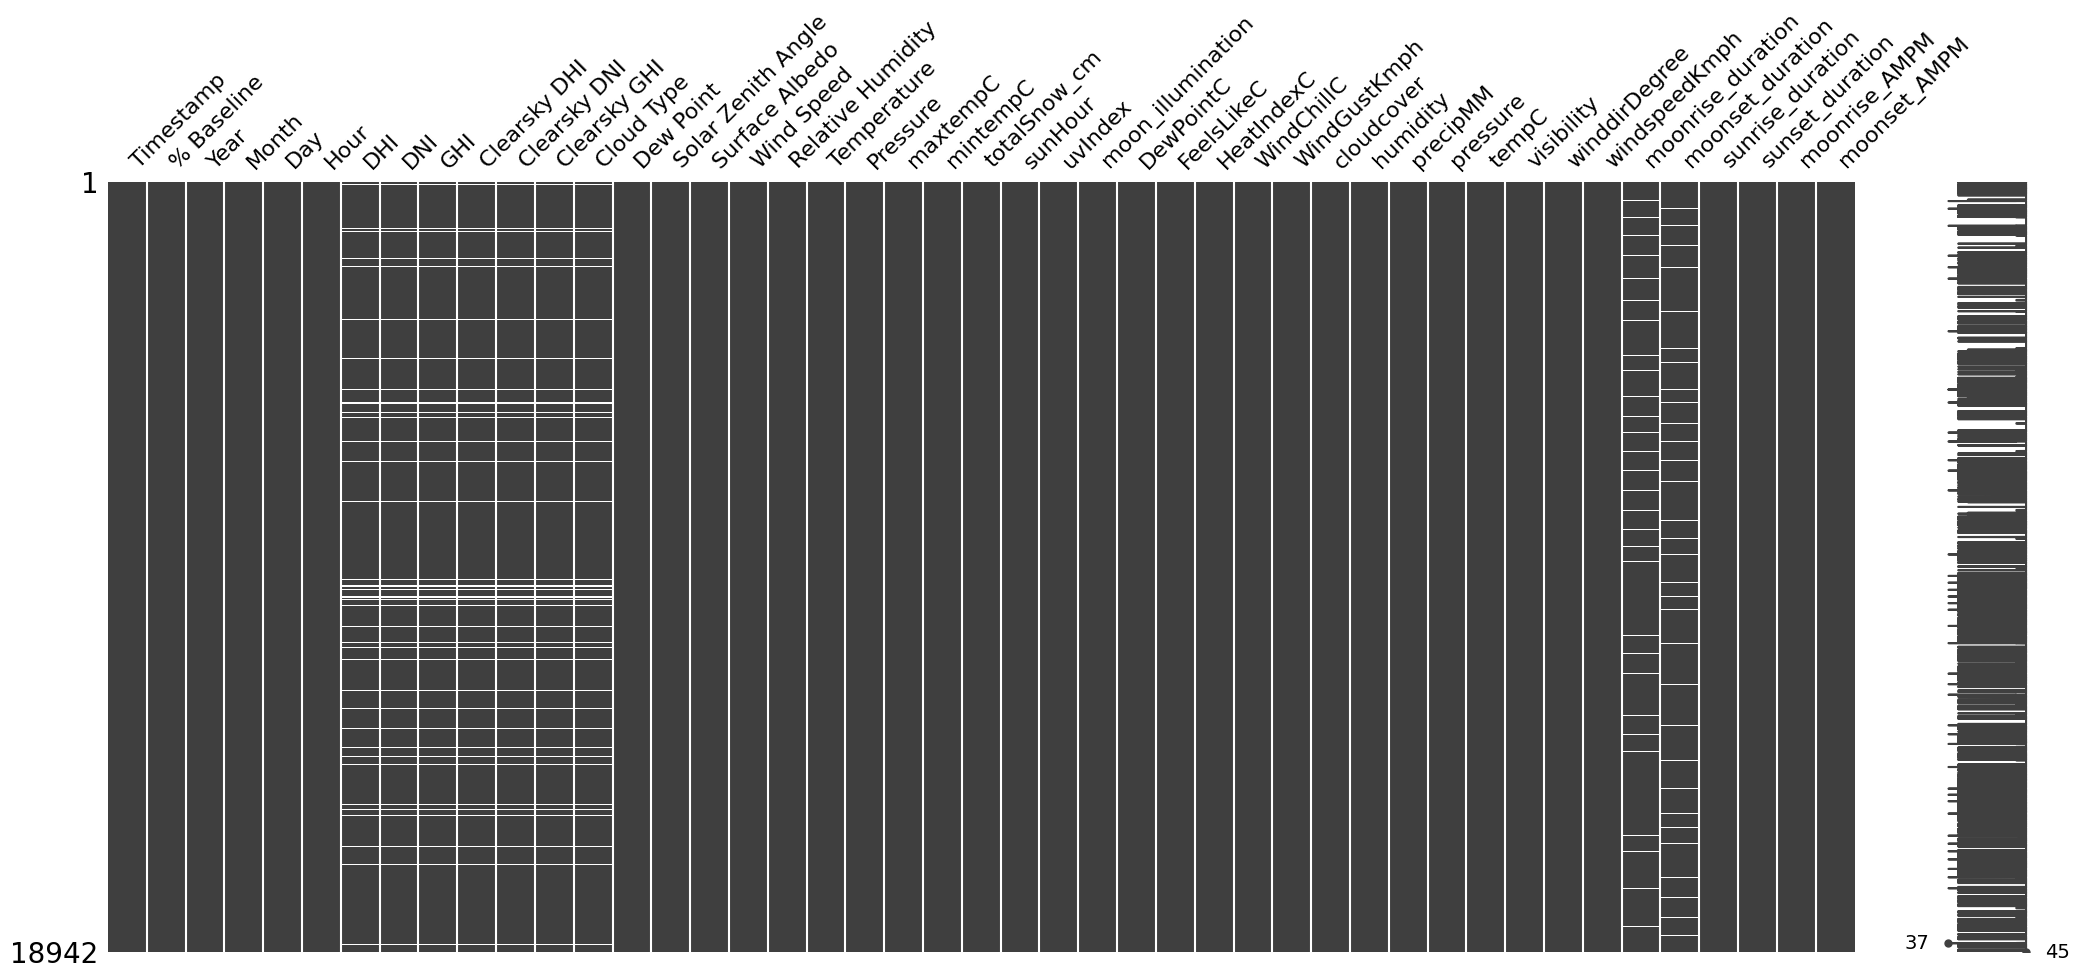

In [ ]:
mno.matrix(train_df)

In [ ]:
missing_values_table(test_df)

Your selected dataframe has 44 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
DHI,167,15.5
DNI,167,15.5
GHI,167,15.5
Clearsky DHI,167,15.5
Clearsky DNI,167,15.5
Clearsky GHI,167,15.5
Cloud Type,112,10.4
moonrise_duration,34,3.2
moonset_duration,33,3.1


<Axes: >

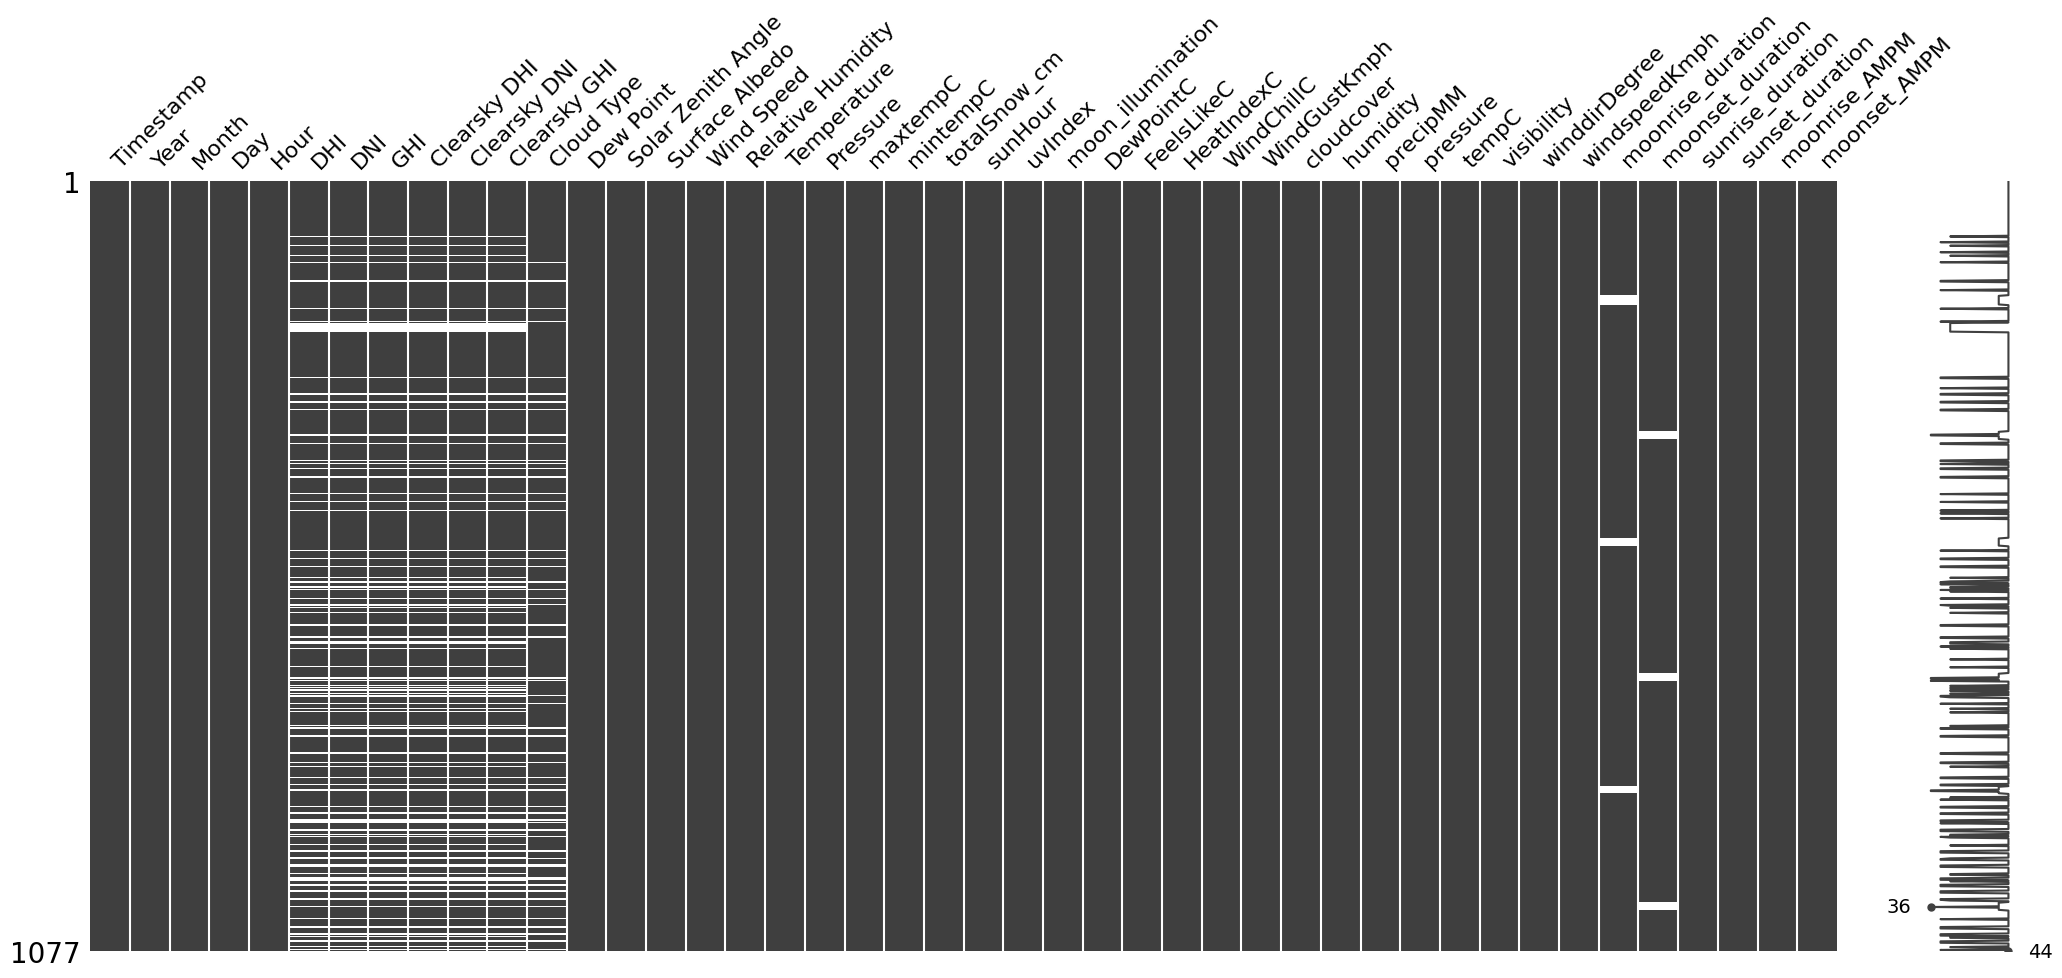

In [ ]:
mno.matrix(test_df)

# Modeling

## Using Base Model Regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
import numpy as np
import lightgbm as lgb

# Define the preprocessing pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scaling
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# Prepare data
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

# Define and fit the LightGBM model
lgbm_model = LGBMRegressor(verbose=-1)
lgbm_model.fit(X_train_preprocessed, y_train)

# Predict on the validation set
y_pred = lgbm_model.predict(X_val_preprocessed)

# Round predictions to 4 decimal places and ensure non-negative
y_pred = np.round(y_pred, 4)
y_pred = np.maximum(y_pred, 0)

# Calculate RMSE
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
print(f'LightGBM Model RMSE: {rmse:.5f}')

# Feature Importance
feature_importances = lgbm_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)


LightGBM Model RMSE: 0.08996
                               Feature  Importance
3                            num__Hour         367
28                     num__cloudcover         184
29                       num__humidity         180
38               num__sunrise_duration         164
11             num__Solar Zenith Angle         162
39                num__sunset_duration         117
34                  num__winddirDegree         100
1                           num__Month          99
0                            num__Year          96
12                 num__Surface Albedo          93
20                        num__sunHour          91
37               num__moonset_duration          89
36              num__moonrise_duration          83
14              num__Relative Humidity          79
31                       num__pressure          79
18                       num__mintempC          74
17                       num__maxtempC          64
13                     num__Wind Speed          61
22

/tmp/ipykernel_3016/2153369198.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')


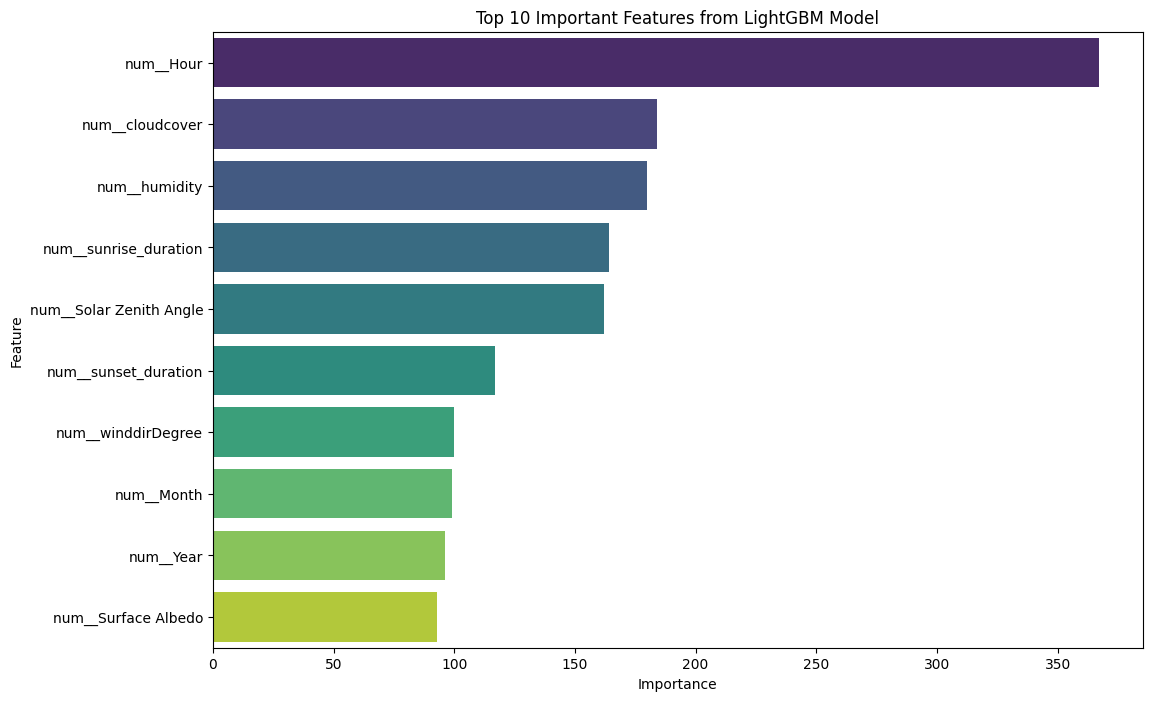

In [ ]:
feature_importances = lgbm_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10_importance_df = importance_df.head(10)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features from LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

/tmp/ipykernel_3016/3070064116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')


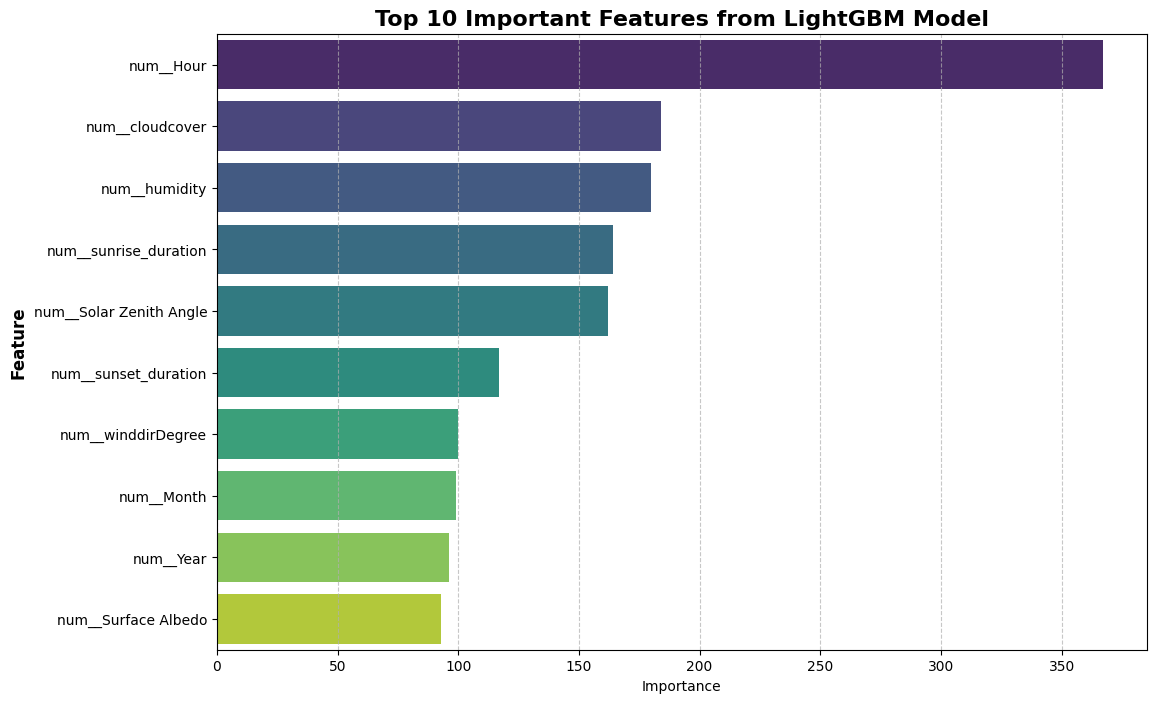

In [ ]:
# Select top 10 features
top_10_importance_df = importance_df.head(10)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features from LightGBM Model', fontsize=16, fontweight='bold')  # Bold title
plt.xlabel('Importance')
plt.ylabel('Feature', fontsize=12, fontweight='bold')  # Bold y-axis label
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add gridlines for the x-axis
plt.show()


In [ ]:
# The target column
target_column = '% Baseline'

# Step 1: Identify numerical and categorical columns
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Remove target column from numerical columns
numerical_columns = numerical_columns.drop(target_column)

# Step 2: Apply backward fill to missing values
train_df_filled = train_df.fillna(method='bfill')
train_df_filled = train_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Split the data (80-20) based on time
train_size = int(len(train_df_filled) * 0.8)
train_data = train_df_filled[:train_size]
validation_data = train_df_filled[train_size:]

# Prepare features and target
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Define the preprocessing pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scaling
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(),
    'LightGBM': LGBMRegressor(verbose=-1),
    'CatBoost': CatBoostRegressor(verbose=0),  # Suppress output
    'Extra Trees': ExtraTreesRegressor()
}

# Create a pipeline for each model and evaluate using RMSE
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor)
        ('model', model)
    ])

    # Fit the model
    pipeline.fit(X_train, y_train)

    # Predict on the validation set
    y_pred = pipeline.predict(X_val)

    # Round predictions to 4 decimal places
    y_pred = np.round(y_pred, 4)
    y_pred = y_pred.apply(lambda x: max(x, 0))

    # Calculate RMSE
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    print(f'{name} Model RMSE: {rmse:.5f}')


## Stacking

In [ ]:
# The target column
target_column = '% Baseline'

# Step 1: Identify numerical and categorical columns
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Remove target column from numerical columns
numerical_columns = numerical_columns.drop(target_column)

# Step 2: Apply backward fill to missing values
train_df_filled = train_df.fillna(method='bfill')
train_df_filled = train_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Split the data (80-20) based on time
train_size = int(len(train_df_filled) * 0.8)
train_data = train_df_filled[:train_size]
validation_data = train_df_filled[train_size:]

# Prepare features and target
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Define the preprocessing pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Scaling
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_columns),
    ('cat', categorical_pipeline, categorical_columns)
])

# Define base models for stacking
estimators_2 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor())
]

estimators_3 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0))
]

estimators_4 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0)),
    ('extra_trees', ExtraTreesRegressor())
]

estimators_5 = [
    ('lgbm', LGBMRegressor(verbose=-1)),
    ('rf', RandomForestRegressor()),
    ('catboost', CatBoostRegressor(verbose=0)),
    ('extra_trees', ExtraTreesRegressor()),
    ('XGBoost', XGBRegressor())
]

# Define the final estimator
final_estimator = LinearRegression()

# Function to create, evaluate, and save a stacking model
def evaluate_and_save_stacking_model(estimators, X_train, y_train, X_val, y_val, final_estimator, model_name):
    stacking_model = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        passthrough=False  # Set to True if you want to include the original features along with predictions
    )

    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('stacking', stacking_model)
    ])

    # Fit the pipeline on the training data
    stacking_pipeline.fit(X_train, y_train)

    # Predict on the validation set
    y_pred = stacking_pipeline.predict(X_val)

    # Round predictions to 4 decimal places
    y_pred = np.round(y_pred, 4)

    # Calculate RMSE
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    print(f'{model_name} Stacking Model RMSE: {rmse:.5f}')

    # Save the model
    joblib.dump(stacking_pipeline, f'{model_name}_stacking_model.pkl')

# Evaluate and save stacking models with 2, 3, 4, and 5 estimators
evaluate_and_save_stacking_model(estimators_2, X_train, y_train, X_val, y_val, final_estimator, '2_estimators')
evaluate_and_save_stacking_model(estimators_3, X_train, y_train, X_val, y_val, final_estimator, '3_estimators')
evaluate_and_save_stacking_model(estimators_4, X_train, y_train, X_val, y_val, final_estimator, '4_estimators')
evaluate_and_save_stacking_model(estimators_5, X_train, y_train, X_val, y_val, final_estimator, '5_estimators')

## Tunning

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Suggest hyperparameters for each base model
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 100)
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 50, 100)
    catboost_depth = trial.suggest_int('catboost_depth', 3, 10)
    xgboost_max_depth = trial.suggest_int('xgboost_max_depth', 3, 10)
    extra_trees_n_estimators = trial.suggest_int('extra_trees_n_estimators', 50, 100)

    # Create the base models with the suggested hyperparameters
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=rf_n_estimators)),
        ('lightgbm', LGBMRegressor(n_estimators=lgbm_n_estimators, verbose=-1)),
        ('catboost', CatBoostRegressor(depth=catboost_depth, verbose=0)),
        ('xgboost', XGBRegressor(max_depth=xgboost_max_depth)),
        ('extra_trees', ExtraTreesRegressor(n_estimators=extra_trees_n_estimators))
    ]

    # Define the meta-model
    meta_model = LinearRegression()

    # Define the stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True
    )

    # Create a pipeline
    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Assume 'preprocessor' is already defined
        ('stacking', stacking_regressor)
    ])

    # Cross-validate the stacking model and return the negative MSE
    score = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Return the mean of the cross-validated MSE as the objective value
    return score.mean()


In [ ]:
def objective(trial):
    # Suggest hyperparameters for each base model with narrower search ranges
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 70, 90)
    lgbm_n_estimators = trial.suggest_int('lgbm_n_estimators', 70, 90)
    catboost_depth = trial.suggest_int('catboost_depth', 4, 6)
    xgboost_max_depth = trial.suggest_int('xgboost_max_depth', 4, 6)
    extra_trees_n_estimators = trial.suggest_int('extra_trees_n_estimators', 70, 90)

    # Create the base models with the suggested hyperparameters
    base_models = [
        ('random_forest', RandomForestRegressor(n_estimators=rf_n_estimators)),
        ('lightgbm', LGBMRegressor(n_estimators=lgbm_n_estimators, verbose=-1)),
        ('catboost', CatBoostRegressor(depth=catboost_depth, verbose=0)),
        ('xgboost', XGBRegressor(max_depth=xgboost_max_depth)),
        ('extra_trees', ExtraTreesRegressor(n_estimators=extra_trees_n_estimators))
    ]

    # Define the meta-model
    meta_model = LinearRegression()

    # Define the stacking regressor
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        passthrough=True
    )

    # Create a pipeline
    stacking_pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Assume 'preprocessor' is already defined
        ('stacking', stacking_regressor)
    ])

    # Cross-validate the stacking model and return the negative MSE
    score = cross_val_score(stacking_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Return the mean of the cross-validated MSE as the objective value
    return score.mean()


In [ ]:
# Create a study object
study = optuna.create_study(direction='maximize')  # We maximize the negative MSE, which means we minimize the actual MSE

# Optimize the objective function
study.optimize(objective, n_trials=5)

# Get the best trial
best_trial = study.best_trial

# Output the best hyperparameters
print("Best trial:")
print("  Value: {}".format(best_trial.value))
print("  Params: ")
for key, value in best_trial.params.items():
    print("    {}: {}".format(key, value))


[I 2024-08-28 09:12:14,172] A new study created in memory with name: no-name-9643b1d2-0b8b-49c3-9b5d-ba7a50fe5b1e
[I 2024-08-28 09:28:04,073] Trial 0 finished with value: -0.01015954889072854 and parameters: {'rf_n_estimators': 88, 'lgbm_n_estimators': 73, 'catboost_depth': 6, 'xgboost_max_depth': 5, 'extra_trees_n_estimators': 89}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 09:43:21,449] Trial 1 finished with value: -0.010224251874682514 and parameters: {'rf_n_estimators': 85, 'lgbm_n_estimators': 89, 'catboost_depth': 6, 'xgboost_max_depth': 4, 'extra_trees_n_estimators': 83}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 09:58:05,879] Trial 2 finished with value: -0.010190006255281443 and parameters: {'rf_n_estimators': 81, 'lgbm_n_estimators': 84, 'catboost_depth': 6, 'xgboost_max_depth': 5, 'extra_trees_n_estimators': 79}. Best is trial 0 with value: -0.01015954889072854.
[I 2024-08-28 10:28:09,498] Trial 4 finished with value: -0.01019085182

Best trial:
  Value: -0.01015954889072854
  Params: 
    rf_n_estimators: 88
    lgbm_n_estimators: 73
    catboost_depth: 6
    xgboost_max_depth: 5
    extra_trees_n_estimators: 89


In [ ]:
meta_model = LinearRegression()

In [ ]:
# Extract the best hyperparameters
best_params = best_trial.params

# Create base models with the best parameters
base_models = [
    ('random_forest', RandomForestRegressor(n_estimators=best_params['rf_n_estimators'])),
    ('lightgbm', LGBMRegressor(n_estimators=best_params['lgbm_n_estimators'])),
    ('catboost', CatBoostRegressor(depth=best_params['catboost_depth'], verbose=0)),
    ('xgboost', XGBRegressor(max_depth=best_params['xgboost_max_depth'])),
    ('extra_trees', ExtraTreesRegressor(n_estimators=best_params['extra_trees_n_estimators']))
]

# Define the stacking regressor
stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True
)

# Create the pipeline
stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_regressor)
])

# Fit the stacking model on the training data
stacking_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_pred_stack = stacking_pipeline.predict(X_val)

# Calculate MSE
mse_stack = mean_squared_error(y_val, y_pred_stack)
print(f'Stacking Regressor MSE: {mse_stack:.5f}')


Stacking Regressor MSE: 0.00776


# Predict Test Data

In [ ]:
# Assume you have decided that the model with the lowest RMSE is the best model, say it's the '4_estimators' model.
test_df_filled = test_df.fillna(method='bfill')
test_df_filled = test_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Load the best model
#best_model = joblib.load('5_estimators_SVR_final_stacking_model.pkl')
best_model = stacking_pipeline
# Predict on the test dataset
X_test = test_df_filled
y_test_pred = best_model.predict(X_test)

/tmp/ipykernel_3016/487210288.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df_filled = test_df.fillna(method='bfill')
/tmp/ipykernel_3016/487210288.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df_filled = test_df_filled.fillna(method='ffill')  # In case there are still any NaNs


In [ ]:
# If you want to create a DataFrame with the predictions
predictions_df = pd.DataFrame({
    'Timestamp': test['Timestamp'],
    '% Baseline': y_test_pred
})

# Display the first few rows of the predictions
print(predictions_df.head())

            Timestamp  % Baseline
0 2017-10-01 06:00:00    0.010254
1 2017-10-01 07:00:00    0.031158
2 2017-10-01 08:00:00    0.105851
3 2017-10-01 09:00:00    0.315648
4 2017-10-01 10:00:00    0.478708


In [ ]:
import pandas as pd

# Assuming 'check' is your DataFrame
predictions_df['% Baseline'] = predictions_df['% Baseline'].apply(lambda x: max(x, 0))

# Display the first few rows of the predictions
print(predictions_df.head())

            Timestamp  % Baseline
0 2017-10-01 06:00:00    0.010254
1 2017-10-01 07:00:00    0.031158
2 2017-10-01 08:00:00    0.105851
3 2017-10-01 09:00:00    0.315648
4 2017-10-01 10:00:00    0.478708


In [ ]:
predictions_df.describe()

,Timestamp,% Baseline
count,1077,1077.000000
mean,2017-11-14 10:16:12.701949952,0.158927
min,2017-10-01 06:00:00,0.000000
25%,2017-10-21 17:00:00,0.025422
50%,2017-11-14 12:00:00,0.092533
75%,2017-12-06 07:00:00,0.248441
max,2017-12-31 16:00:00,0.715854
std,NaN,0.168961


# Diff Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# The target column
target_column = '% Baseline'

# Step 1: Identify numerical and categorical columns
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Remove target column from numerical columns
numerical_columns = numerical_columns.drop(target_column)

# Step 2: Apply backward fill to missing values
train_df_filled = train_df.fillna(method='bfill')
train_df_filled = train_df_filled.fillna(method='ffill')  # In case there are still any NaNs

# Split the data (80-20) based on time
train_size = int(len(train_df_filled) * 0.8)
train_data = train_df_filled[:train_size]
validation_data = train_df_filled[train_size:]

# Prepare features and target
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_val = validation_data.drop(columns=[target_column])
y_val = validation_data[target_column]

# Different scalers for comparison
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'RobustScaler': RobustScaler()
}

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(),
    'LightGBM': LGBMRegressor(verbose=-1),
    'CatBoost': CatBoostRegressor(verbose=0),  # Suppress output
    'Extra Trees': ExtraTreesRegressor()
}

# Iterate through different scalers and models
for scaler_name, scaler in scalers.items():
    print(f"Using {scaler_name}:\n")
    numerical_pipeline = Pipeline([
        ('scaler', scaler)  # Different types of scaling
    ])

    categorical_pipeline = Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding for categorical variables
    ])

    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_columns),
        ('cat', categorical_pipeline, categorical_columns)
    ])

    # Evaluate each model with the current scaler
    for name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # Fit the model
        pipeline.fit(X_train, y_train)

        # Predict on the validation set
        y_pred = pipeline.predict(X_val)

        # Round predictions to 4 decimal places and handle negatives
        y_pred = np.round(y_pred, 4)
        y_pred = np.maximum(y_pred, 0)

        # Calculate RMSE
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        print(f'{name} Model RMSE: {rmse:.5f}')
    print("\n" + "="*50 + "\n")


# TS Imputation

In [ ]:
# Linear interpolation
train_df_filled = train_df.interpolate(method='linear')


In [ ]:
# Filling missing values with the mean
train_df_filled = train_df.fillna(train_df.mean())

# Filling missing values with the median
train_df_filled = train_df.fillna(train_df.median())


In [ ]:
# Fill missing values using moving average (window size of 3 for example)
train_df_filled = train_df.fillna(train_df.rolling(window=3, min_periods=1).mean())


In [ ]:
# Spline interpolation
train_df_filled = train_df.interpolate(method='spline', order=2)


In [ ]:
from sklearn.impute import KNNImputer

# Create KNN imputer
imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation
train_df_filled = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
result = seasonal_decompose(train_df[target_column], model='additive', period=12)

# Fill NaNs in the trend component using forward/backward fill
trend_filled = result.trend.fillna(method='ffill').fillna(method='bfill')

# Fill NaNs in the seasonal component using forward/backward fill
seasonal_filled = result.seasonal.fillna(method='ffill').fillna(method='bfill')

# You can then combine these components back to reconstruct the time series
train_df_filled = trend_filled + seasonal_filled + result.resid.fillna(0)


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit the SimpleExpSmoothing model
model = SimpleExpSmoothing(train_df[target_column].fillna(method='ffill'))  # Filling forward for initial NaNs
model_fit = model.fit()

# Use the fitted model to fill missing values
train_df_filled = model_fit.fittedvalues


# Normal Regression Imputation

In [ ]:
# Mean Imputation
df_filled = df.fillna(df.mean())

# Median Imputation
df_filled = df.fillna(df.median())

# Mode Imputation (for categorical columns)
df_filled = df.fillna(df.mode().iloc[0])


In [ ]:
from sklearn.impute import KNNImputer

# Apply KNN imputation with 5 nearest neighbors
imputer = KNNImputer(n_neighbors=5)
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Apply Iterative Imputer
imputer = IterativeImputer(max_iter=10, random_state=0)
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


In [ ]:
# Fill numerical columns with 0
df_filled = df.fillna(0)

# Fill categorical columns with a specific value, e.g., 'Unknown'
df_filled['categorical_column'] = df['categorical_column'].fillna('Unknown')


In [ ]:
# Forward fill
df_filled = df.fillna(method='ffill')

# Backward fill
df_filled = df.fillna(method='bfill')


In [ ]:
from sklearn.linear_model import LinearRegression

# Example of manually applying regression imputation for one feature
known = df[df['missing_column'].notnull()]
unknown = df[df['missing_column'].isnull()]

# Fit a regression model to predict missing_column
model = LinearRegression()
model.fit(known.drop(columns=['missing_column']), known['missing_column'])

# Predict missing values
predicted_values = model.predict(unknown.drop(columns=['missing_column']))

# Fill missing values
df.loc[df['missing_column'].isnull(), 'missing_column'] = predicted_values


In [ ]:
import random

# Randomly pick a value from the same feature to fill the missing value
def hot_deck_impute(series):
    return series.fillna(random.choice(series.dropna()))

df_filled = df.apply(hot_deck_impute)


In [ ]:
pip install missingpy


In [ ]:
from missingpy import MissForest

# Apply MissForest imputation
imputer = MissForest()
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


In [ ]:
# Drop rows with missing values
df_dropped = df.dropna()

# Drop columns with missing values
df_dropped = df.dropna(axis=1)
